Filename : notebook_02.ipynb <br>
Description : Workshop — Analyze and Visualize Your Customer (iFood Dataset)

---

# Workshop : Analyze and Visualize Your Customer

**Dataset:** `ifood.xlsx` — ข้อมูลลูกค้าของ iFood จำนวน 2,205 ราย 27 คอลัมน์
**ที่มาโจทย์:** `chapter_03.pdf` หน้า 31–38 (Exercise 1–30)

## โครงสร้างโจทย์

| ช่วง | ประเภท | เนื้อหา |
|------|--------|---------|
| **Exercise 1–20** | Basic Skills | คำนวณสถิติพื้นฐาน, GroupBy, การสร้างกราฟ |
| **Exercise 21–30** | Insight Analysis | วิเคราะห์เชิงธุรกิจ + สรุป Insight |

## คำอธิบายคอลัมน์ (Data Dictionary)

| Field | Description |
|-------|-------------|
| `No` | Identifier — รหัสประจำตัวลูกค้า |
| `Income` | รายได้ครัวเรือนต่อปีของลูกค้า |
| `Kidhome` | จำนวนเด็กเล็กในครัวเรือน |
| `Teenhome` | จำนวนวัยรุ่นในครัวเรือน |
| `Recency` | จำนวนวันนับจากการซื้อครั้งล่าสุด |
| `MntWines` | ยอดใช้จ่ายค่าไวน์ ในรอบ 2 ปี |
| `MntFruits` | ยอดใช้จ่ายค่าผลไม้ ในรอบ 2 ปี |
| `MntMeatProducts` | ยอดใช้จ่ายค่าเนื้อสัตว์ ในรอบ 2 ปี |
| `MntFishProducts` | ยอดใช้จ่ายค่าปลา ในรอบ 2 ปี |
| `MntSweetProducts` | ยอดใช้จ่ายค่าขนมหวาน ในรอบ 2 ปี |
| `MntGoldProds` | ยอดใช้จ่ายสินค้าพรีเมียม (Gold) ในรอบ 2 ปี |
| `NumDealsPurchases` | จำนวนครั้งที่ซื้อโดยใช้ส่วนลด |
| `NumWebPurchases` | จำนวนครั้งที่ซื้อผ่านเว็บไซต์ |
| `NumCatalogPurchases` | จำนวนครั้งที่ซื้อผ่านแคตตาล็อก |
| `NumStorePurchases` | จำนวนครั้งที่ซื้อที่หน้าร้าน |
| `NumWebVisitsMonth` | จำนวนครั้งที่เข้าเว็บไซต์ในเดือนล่าสุด |
| `AcceptedCmp1`–`AcceptedCmp5` | 1 = ตอบรับข้อเสนอแคมเปญที่ 1–5, 0 = ไม่ตอบรับ |
| `Complain` | 1 = เคยร้องเรียนในรอบ 2 ปี |
| `Response` | 1 = ตอบรับแคมเปญล่าสุด, 0 = ไม่ตอบรับ |
| `Age` | อายุ (ปี) |
| `Customer_Days` | จำนวนวันที่เป็นลูกค้ากับบริษัท |
| `Marital` | สถานภาพสมรส — Categorical |
| `Education` | ระดับการศึกษา — Categorical |

---

In [34]:
# =============================================================================
# Import Required Libraries
# =============================================================================
# Import Library หลัก 4 ตัวที่ใช้ตลอดทั้ง notebook นี้:

# 1. NumPy (np) — คำนวณทางคณิตศาสตร์และจัดการ Array
import numpy as np

# 2. Pandas (pd) — จัดการและวิเคราะห์ข้อมูลในรูป DataFrame / Series
import pandas as pd

# 3. Matplotlib (plt) — สร้างกราฟพื้นฐาน (Histogram, Bar, Box, Heatmap)
import matplotlib.pyplot as plt

# 4. Seaborn (sns) — กราฟสถิติระดับสูง (Pairplot, Heatmap) สร้างบน Matplotlib
import seaborn as sns

# --- ตั้งค่ามาตรฐานของการแสดงผล ---
pd.set_option("display.max_columns", None)   # แสดงทุกคอลัมน์ ไม่ตัดด้วย "..."
pd.set_option("display.width", 200)          # ความกว้างของการพิมพ์ DataFrame
plt.rcParams["figure.figsize"] = (8, 5)      # ขนาด Figure เริ่มต้นของทุกกราฟ
plt.rcParams["axes.grid"] = True             # เปิด Gridline เป็นค่าเริ่มต้น
plt.rcParams["grid.alpha"] = 0.3             # ความเข้มของ Gridline (โปร่งแสง)

# --- ตั้งค่า Font ให้แสดงภาษาไทยในกราฟได้ ---
# Font เริ่มต้นของ Matplotlib (DejaVu Sans) ไม่มีตัวอักษรไทย จะขึ้นเป็นสี่เหลี่ยม
# จึงต้องเลือก Font ที่รองรับภาษาไทย โดยไล่หาตัวที่มีอยู่ในเครื่อง
from matplotlib import font_manager

thai_fonts = ["Sarabun", "Thonburi", "Tahoma", "Arial Unicode MS"]
available = {f.name for f in font_manager.fontManager.ttflist}
picked = next((f for f in thai_fonts if f in available), None)

if picked:
    plt.rcParams["font.family"] = picked
    print(f"ตั้งค่า Font ภาษาไทยเป็น : {picked}")
else:
    print("คำเตือน: ไม่พบ Font ภาษาไทยในเครื่อง ข้อความไทยในกราฟอาจแสดงเป็นสี่เหลี่ยม")

plt.rcParams["axes.unicode_minus"] = False   # ให้เครื่องหมายลบแสดงถูกต้องเมื่อเปลี่ยน Font

print("Libraries imported successfully")
print("pandas version     :", pd.__version__)
print("numpy version      :", np.__version__)
print("seaborn version    :", sns.__version__)

ตั้งค่า Font ภาษาไทยเป็น : Sarabun
Libraries imported successfully
pandas version     : 3.0.5
numpy version      : 2.5.3
seaborn version    : 0.13.2


---

## Exercise 1 — Load file with pandas

> **โจทย์:** Load the dataset from `ifood.xlsx` and check the number of rows and columns in the DataFrame.

**วัตถุประสงค์:** โหลดข้อมูลจากไฟล์ Excel และตรวจสอบขนาดของ DataFrame

### การอ่านไฟล์ Excel ด้วย Pandas

```python
df = pd.read_excel("ifood.xlsx")
```

| Function | ใช้กับไฟล์ | Engine ที่ต้องมี |
|----------|-----------|------------------|
| `pd.read_csv()` | `.csv` | ไม่ต้องติดตั้งเพิ่ม |
| `pd.read_excel()` | `.xlsx` | `openpyxl` |
| `pd.read_json()` | `.json` | ไม่ต้องติดตั้งเพิ่ม |

### Attribute / Method ที่ใช้ตรวจสอบข้อมูลเบื้องต้น

| คำสั่ง | ผลลัพธ์ |
|--------|---------|
| `df.shape` | tuple `(จำนวนแถว, จำนวนคอลัมน์)` |
| `df.head(n)` | แสดง n แถวแรก (ค่าเริ่มต้น 5) |
| `df.info()` | ชนิดข้อมูลแต่ละคอลัมน์ + จำนวนค่าที่ไม่ใช่ Null |
| `df.describe()` | สถิติสรุปของคอลัมน์ตัวเลข |
| `df.isna().sum()` | จำนวน Missing Value ของแต่ละคอลัมน์ |

> **หมายเหตุ:** `df.shape[0]` คือจำนวนแถว (Row) และ `df.shape[1]` คือจำนวนคอลัมน์ (Column)

In [35]:
# =============================================================================
# Exercise 1: Load file with pandas
# =============================================================================
# โหลดข้อมูลจากไฟล์ Excel แล้วตรวจสอบขนาดและโครงสร้างของ DataFrame

# --- อ่านไฟล์ Excel เข้ามาเป็น DataFrame ---
df = pd.read_excel("ifood.xlsx")   # ต้องมี openpyxl ติดตั้งไว้

# --- ตรวจสอบขนาดของข้อมูล ---
rows, cols = df.shape              # shape คืนค่าเป็น tuple (แถว, คอลัมน์)

print("=" * 60)
print("ขนาดของ DataFrame")
print("=" * 60)
print(f"จำนวนแถว (Rows)      : {rows:,} rows")
print(f"จำนวนคอลัมน์ (Columns) : {cols} columns")

# --- ตรวจสอบ Missing Value ---
missing = df.isna().sum().sum()    # sum() 2 ครั้ง = รวมทุกคอลัมน์เป็นค่าเดียว
print(f"Missing Value ทั้งหมด  : {missing} cells")

# --- แสดงรายชื่อคอลัมน์ทั้งหมด ---
print("\nรายชื่อคอลัมน์:")
for i, c in enumerate(df.columns, start=1):
    print(f"  {i:2d}. {c:<22} ({df[c].dtype})")

# --- แสดง 5 แถวแรกเพื่อดูหน้าตาข้อมูล ---
print("\n5 แถวแรกของข้อมูล:")
df.head()

ขนาดของ DataFrame
จำนวนแถว (Rows)      : 2,205 rows
จำนวนคอลัมน์ (Columns) : 27 columns
Missing Value ทั้งหมด  : 0 cells

รายชื่อคอลัมน์:
   1. No                     (int64)
   2. Income                 (int64)
   3. Kidhome                (int64)
   4. Teenhome               (int64)
   5. Recency                (int64)
   6. MntWines               (int64)
   7. MntFruits              (int64)
   8. MntMeatProducts        (int64)
   9. MntFishProducts        (int64)
  10. MntSweetProducts       (int64)
  11. MntGoldProds           (int64)
  12. NumDealsPurchases      (int64)
  13. NumWebPurchases        (int64)
  14. NumCatalogPurchases    (int64)
  15. NumStorePurchases      (int64)
  16. NumWebVisitsMonth      (int64)
  17. AcceptedCmp3           (int64)
  18. AcceptedCmp4           (int64)
  19. AcceptedCmp5           (int64)
  20. AcceptedCmp1           (int64)
  21. AcceptedCmp2           (int64)
  22. Complain               (int64)
  23. Response               (int64)
  24. Age  

,No,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Customer_Days,Marital,Education
0,1,58138,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,63,2822,Single,Graduation
1,2,46344,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,66,2272,Single,Graduation
2,3,71613,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,55,2471,Together,Graduation
3,4,26646,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,36,2298,Together,Graduation
4,5,58293,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,39,2320,Married,PhD


---

## Exercise 2 — Basic income statistics

> **โจทย์:** Calculate the mean, median, and mode of the `Income` column.

**วัตถุประสงค์:** คำนวณค่ากลาง 3 ตัวของรายได้ เพื่อดูว่าข้อมูลกระจุกตัวอยู่ที่ระดับใด

### ค่ากลาง 3 ตัว (Measures of Central Tendency)

| ค่า | Method | ความหมาย | จุดอ่อน |
|-----|--------|----------|---------|
| **Mean** | `.mean()` | ค่าเฉลี่ย = ผลรวม ÷ จำนวน | ถูก Outlier ดึงได้ง่าย |
| **Median** | `.median()` | ค่าที่อยู่ตรงกลางเมื่อเรียงข้อมูล | ทนต่อ Outlier |
| **Mode** | `.mode()` | ค่าที่ปรากฏบ่อยที่สุด | อาจมีหลายค่า / ไม่มีเลย |

### การอ่านความเบ้จากค่ากลาง

```
Mean > Median  →  เบ้ขวา (Right-skewed)  มีค่าสูงผิดปกติลากหางไปทางขวา
Mean ≈ Median  →  สมมาตร (Symmetric)
Mean < Median  →  เบ้ซ้าย (Left-skewed)   มีค่าต่ำผิดปกติลากหางไปทางซ้าย
```

> **สำคัญ:** `.mode()` คืนค่าเป็น **Series** ไม่ใช่ตัวเลขเดียว เพราะข้อมูลอาจมีฐานนิยมได้หลายค่า จึงต้องใช้ `.mode()[0]` เพื่อดึงค่าแรกออกมา

In [36]:
# =============================================================================
# Exercise 2: Basic income statistics
# =============================================================================
# คำนวณ Mean, Median, Mode ของคอลัมน์ "Income"

col = "Income"

# --- คำนวณค่ากลาง 3 ตัว ---
mean_income = df[col].mean()        # ค่าเฉลี่ย = ผลรวมทั้งหมด / จำนวนข้อมูล
median_income = df[col].median()    # ค่ากลาง = ค่าที่อยู่ตำแหน่งกึ่งกลางเมื่อเรียงข้อมูล
mode_series = df[col].mode()        # ฐานนิยม — คืนค่าเป็น Series (อาจมีหลายค่า)
mode_income = mode_series[0]        # ดึงค่าแรกออกมาใช้งาน

print("=" * 60)
print(f"สถิติค่ากลางของ {col}")
print("=" * 60)
print(f"Mean   (ค่าเฉลี่ย) : {mean_income:>12,.2f}")
print(f"Median (ค่ากลาง)  : {median_income:>12,.2f}")
print(f"Mode   (ฐานนิยม)  : {mode_income:>12,.2f}   (ปรากฏ {(df[col] == mode_income).sum()} ครั้ง)")

# --- ตรวจสอบว่าฐานนิยมมีหลายค่าหรือไม่ ---
if len(mode_series) > 1:
    print(f"  หมายเหตุ: พบฐานนิยมทั้งหมด {len(mode_series)} ค่า -> {list(mode_series)}")

# --- แปลความหมายความเบ้จากความสัมพันธ์ Mean vs Median ---
print("-" * 60)
diff = mean_income - median_income
if diff > 0:
    print(f"Mean > Median ({diff:,.2f}) -> ข้อมูลเบ้ขวา (Right-skewed)")
    print("   แปลผล: มีลูกค้ากลุ่มรายได้สูงมากบางรายดึงค่าเฉลี่ยขึ้น")
elif diff < 0:
    print(f"Mean < Median ({diff:,.2f}) -> ข้อมูลเบ้ซ้าย (Left-skewed)")
else:
    print("Mean = Median -> ข้อมูลสมมาตร (Symmetric)")

สถิติค่ากลางของ Income
Mean   (ค่าเฉลี่ย) :    51,622.09
Median (ค่ากลาง)  :    51,287.00
Mode   (ฐานนิยม)  :     7,500.00   (ปรากฏ 12 ครั้ง)
------------------------------------------------------------
Mean > Median (335.09) -> ข้อมูลเบ้ขวา (Right-skewed)
   แปลผล: มีลูกค้ากลุ่มรายได้สูงมากบางรายดึงค่าเฉลี่ยขึ้น


---

## Exercise 3 — Age distribution

> **โจทย์:** Create a histogram of the `Age` column with gridlines and clear labels.

**วัตถุประสงค์:** ดูรูปร่างการกระจายตัวของอายุลูกค้า พร้อมใส่ Gridline และ Label ให้อ่านง่าย

### Histogram คืออะไร?

กราฟแท่งที่แบ่งข้อมูล **ตัวเลขต่อเนื่อง** ออกเป็นช่วง ๆ เรียกว่า **bin** แล้วนับความถี่ในแต่ละช่วง

> **Histogram ≠ Bar Chart**
> Histogram ใช้กับข้อมูล **ต่อเนื่อง** (แท่งติดกัน) — Bar Chart ใช้กับข้อมูล **หมวดหมู่** (แท่งแยกกัน)

### Parameter สำคัญของ `plt.hist()`

| Parameter | ความหมาย |
|-----------|----------|
| `bins` | จำนวนช่วง — น้อยเกินไปเห็นรายละเอียดไม่พอ, มากเกินไปกราฟจะรบกวนสายตา |
| `color` | สีของแท่ง |
| `edgecolor` | สีขอบแท่ง — ช่วยแยกแท่งที่ติดกันให้เห็นชัด |
| `alpha` | ความโปร่งแสง 0–1 |

### องค์ประกอบที่ทำให้กราฟ "อ่านง่าย" (Clear Labels)

| คำสั่ง | หน้าที่ |
|--------|---------|
| `plt.title()` | ชื่อกราฟ — บอกว่ากราฟนี้แสดงอะไร |
| `plt.xlabel()` / `plt.ylabel()` | ชื่อแกน + **หน่วย** |
| `plt.grid()` | เส้นตาราง — ช่วยกะค่าบนแกนได้แม่นขึ้น |
| `plt.legend()` | คำอธิบายเส้น/สีที่วาดทับ |
| `plt.axvline()` | เส้นแนวตั้ง — ใช้ mark ตำแหน่ง Mean / Median

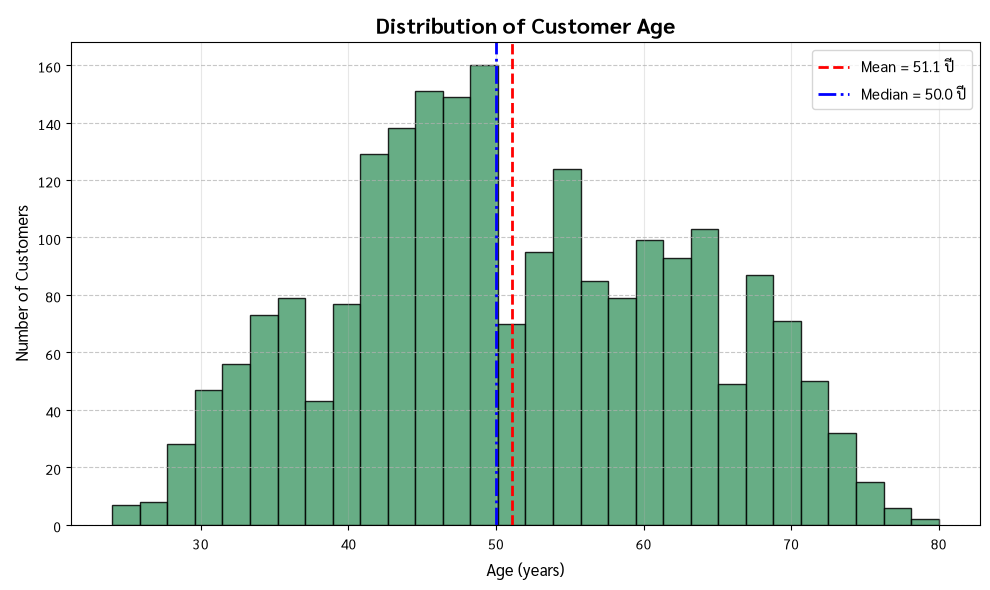

สรุปการกระจายตัวของ Age
ช่วงอายุ  : 24 - 80 ปี
Mean      : 51.10 ปี
Median    : 50.00 ปี
Std       : 11.71 ปี


In [37]:
# =============================================================================
# Exercise 3: Age distribution (Histogram)
# =============================================================================
# สร้าง Histogram ของอายุลูกค้า พร้อม Gridline และ Label ที่ชัดเจน

col = "Age"

# --- คำนวณค่ากลางเพื่อวาดเส้นอ้างอิงบนกราฟ ---
mean_age = df[col].mean()
median_age = df[col].median()

# --- สร้าง Figure ---
plt.figure(figsize=(10, 6))

# --- วาด Histogram: แบ่งอายุเป็น 30 ช่วง (bins) ---
plt.hist(df[col], bins=30, color="#4C9F70", edgecolor="black", alpha=0.85)

# --- วาดเส้นแนวตั้ง mark ตำแหน่ง Mean และ Median ---
plt.axvline(mean_age, color="red", linestyle="--", linewidth=2,
            label=f"Mean = {mean_age:.1f} ปี")
plt.axvline(median_age, color="blue", linestyle="-.", linewidth=2,
            label=f"Median = {median_age:.1f} ปี")

# --- ใส่ Label และ Title ให้ชัดเจน ---
plt.title("Distribution of Customer Age", fontsize=16, fontweight="bold")
plt.xlabel("Age (years)", fontsize=12)          # แกน X = อายุ พร้อมหน่วย
plt.ylabel("Number of Customers", fontsize=12)  # แกน Y = ความถี่
plt.grid(axis="y", linestyle="--", alpha=0.7)   # Gridline แนวนอนช่วยอ่านความถี่
plt.legend(fontsize=11)                         # แสดงคำอธิบายเส้น Mean / Median

plt.tight_layout()    # จัดระยะขอบไม่ให้ Label ถูกตัด
plt.show()

# --- สรุปตัวเลขประกอบกราฟ ---
print("=" * 60)
print(f"สรุปการกระจายตัวของ {col}")
print("=" * 60)
print(f"ช่วงอายุ  : {df[col].min()} - {df[col].max()} ปี")
print(f"Mean      : {mean_age:.2f} ปี")
print(f"Median    : {median_age:.2f} ปี")
print(f"Std       : {df[col].std():.2f} ปี")

---

## Exercise 4 — Range and IQR

> **โจทย์:** Compute the range and interquartile range (IQR) of the `MntWines` column.

**วัตถุประสงค์:** วัดการกระจายตัว (Dispersion) ของยอดใช้จ่ายค่าไวน์ด้วย Range และ IQR

### Range vs IQR

| ค่า | สูตร | ความหมาย | ความทนต่อ Outlier |
|-----|------|----------|-------------------|
| **Range** | `max − min` | ความกว้างของข้อมูลทั้งหมด | **ต่ำ** — ใช้แค่ 2 ค่าสุดขั้ว |
| **IQR** | `Q3 − Q1` | ความกว้างของข้อมูล 50% ตรงกลาง | **สูง** — ตัดหัวท้ายออก 25% |

### Quartile (ควอไทล์)

```
Q1 = Percentile ที่ 25  →  df["col"].quantile(0.25)
Q2 = Percentile ที่ 50  →  Median
Q3 = Percentile ที่ 75  →  df["col"].quantile(0.75)
```

### เกณฑ์มาตรฐานในการหา Outlier

```
ขอบล่าง (Lower Bound) = Q1 − 1.5 × IQR
ขอบบน  (Upper Bound) = Q3 + 1.5 × IQR
```

ค่าที่อยู่นอกขอบเขตนี้ถือเป็น **Outlier** — ในทางธุรกิจมักไม่ใช่ "ข้อมูลผิด" แต่เป็น **ลูกค้ากลุ่มพิเศษ** ที่ควรวิเคราะห์แยก

In [38]:
# =============================================================================
# Exercise 4: Range and IQR of MntWines
# =============================================================================
# คำนวณ Range และ IQR ของยอดใช้จ่ายค่าไวน์

col = "MntWines"

# --- Range = ค่าสูงสุด - ค่าต่ำสุด ---
max_val = df[col].max()
min_val = df[col].min()
data_range = max_val - min_val

# --- IQR = Q3 - Q1 (ความกว้างของข้อมูล 50% ตรงกลาง) ---
q1 = df[col].quantile(0.25)    # Percentile ที่ 25
q2 = df[col].quantile(0.50)    # Percentile ที่ 50 = Median
q3 = df[col].quantile(0.75)    # Percentile ที่ 75
iqr = q3 - q1

print("=" * 60)
print(f"การกระจายตัวของ {col}")
print("=" * 60)
print(f"Min            : {min_val:>10,.2f}")
print(f"Q1 (25%)       : {q1:>10,.2f}")
print(f"Q2 (50%/Median): {q2:>10,.2f}")
print(f"Q3 (75%)       : {q3:>10,.2f}")
print(f"Max            : {max_val:>10,.2f}")
print("-" * 60)
print(f"Range = Max - Min = {max_val:,.2f} - {min_val:,.2f} = {data_range:,.2f}")
print(f"IQR   = Q3  - Q1  = {q3:,.2f} - {q1:,.2f} = {iqr:,.2f}")

# --- หา Outlier ด้วยเกณฑ์ 1.5 x IQR ---
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

print("-" * 60)
print("การตรวจหา Outlier (เกณฑ์ 1.5 x IQR)")
print(f"Lower Bound = Q1 - 1.5*IQR = {lower_bound:,.2f}")
print(f"Upper Bound = Q3 + 1.5*IQR = {upper_bound:,.2f}")
print(f"จำนวน Outlier : {len(outliers)} ราย ({len(outliers)/len(df)*100:.2f}% ของลูกค้าทั้งหมด)")
print("\nแปลผล: IQR แคบกว่า Range มาก แสดงว่าลูกค้าส่วนใหญ่ใช้จ่ายค่าไวน์ไม่สูง")
print("        แต่มีลูกค้ากลุ่มเล็กที่ใช้จ่ายสูงมาก (กลุ่ม Wine Lover) ดึง Max ขึ้นไป")

การกระจายตัวของ MntWines
Min            :       0.00
Q1 (25%)       :      24.00
Q2 (50%/Median):     178.00
Q3 (75%)       :     507.00
Max            :   1,493.00
------------------------------------------------------------
Range = Max - Min = 1,493.00 - 0.00 = 1,493.00
IQR   = Q3  - Q1  = 507.00 - 24.00 = 483.00
------------------------------------------------------------
การตรวจหา Outlier (เกณฑ์ 1.5 x IQR)
Lower Bound = Q1 - 1.5*IQR = -700.50
Upper Bound = Q3 + 1.5*IQR = 1,231.50
จำนวน Outlier : 34 ราย (1.54% ของลูกค้าทั้งหมด)

แปลผล: IQR แคบกว่า Range มาก แสดงว่าลูกค้าส่วนใหญ่ใช้จ่ายค่าไวน์ไม่สูง
        แต่มีลูกค้ากลุ่มเล็กที่ใช้จ่ายสูงมาก (กลุ่ม Wine Lover) ดึง Max ขึ้นไป


---

## Exercise 5 — Income grouping

> **โจทย์:** Use `pd.cut` to divide `Income` into 4 ranges and count the number of customers in each group.

**วัตถุประสงค์:** แบ่งรายได้เป็น 4 ช่วงด้วย `pd.cut` แล้วนับจำนวนลูกค้าในแต่ละช่วง

### `pd.cut()` — Binning แบบ "ความกว้างเท่ากัน"

```python
pd.cut(df["Income"], bins=4)
```

แบ่งช่วงโดยให้ **ความกว้างของแต่ละช่วงเท่ากัน** → `(max − min) / 4`

| Parameter | ความหมาย |
|-----------|----------|
| `bins=4` | จำนวนช่วง (หรือส่งเป็น list ของขอบช่วงเองก็ได้) |
| `labels=[...]` | ชื่อที่อ่านง่ายแทนสัญลักษณ์ช่วง เช่น `Low`, `Medium` |
| `include_lowest=True` | ให้ค่าต่ำสุดรวมอยู่ในช่วงแรก |

### `pd.cut()` vs `pd.qcut()` — ต่างกันสำคัญมาก

| | `pd.cut()` | `pd.qcut()` |
|---|-----------|-------------|
| แบ่งตาม | **ความกว้างของช่วงเท่ากัน** | **จำนวนข้อมูลในแต่ละกลุ่มเท่ากัน** |
| จำนวนสมาชิกแต่ละกลุ่ม | ไม่เท่ากัน (ขึ้นกับการกระจายตัว) | เท่ากันประมาณ 25% ต่อกลุ่ม |
| ใช้เมื่อ | ต้องการช่วงที่มีความหมายทางธุรกิจ | ต้องการแบ่ง Segment ขนาดเท่ากัน |

> เปรียบเทียบผลลัพธ์ของ 2 ฟังก์ชันนี้ได้ที่ **Exercise 16**

การแบ่งกลุ่มรายได้ด้วย pd.cut() — ความกว้างช่วงเท่ากัน
Group        ช่วงรายได้                      จำนวน    สัดส่วน
----------------------------------------------------------------------
Low          (1,618 - 29,731]                  363     16.46%
Medium       (29,731 - 57,732]                 941     42.68%
High         (57,732 - 85,733]                 822     37.28%
Very High    (85,733 - 113,734]                 79      3.58%
----------------------------------------------------------------------
Total                                        2,205    100.00%


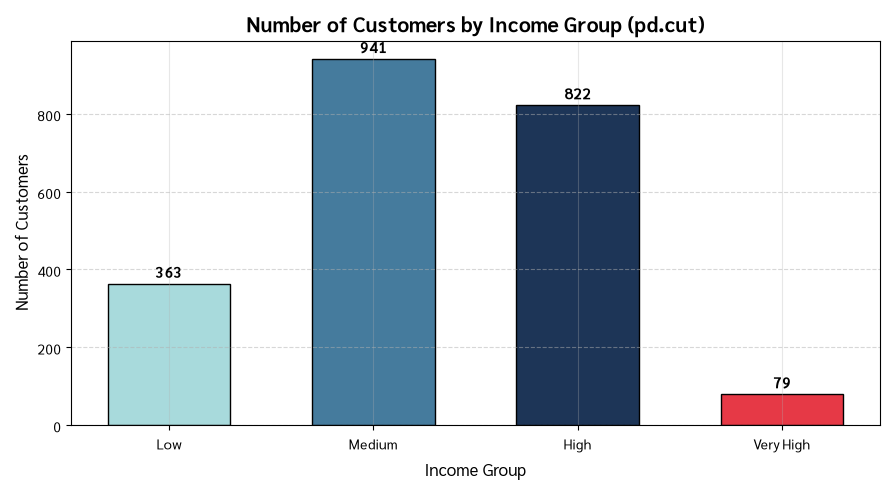


แปลผล: กลุ่ม Medium และ High มีลูกค้ามากที่สุด ส่วนกลุ่ม Very High มีน้อยมาก
        เป็นลักษณะปกติของการกระจายตัวรายได้ที่เบ้ขวา (Right-skewed)


In [39]:
# =============================================================================
# Exercise 5: Income grouping with pd.cut()
# =============================================================================
# แบ่ง Income เป็น 4 ช่วง (ความกว้างเท่ากัน) แล้วนับจำนวนลูกค้าในแต่ละช่วง

# --- แบ่งกลุ่มด้วย pd.cut (Equal-width binning) ---
labels = ["Low", "Medium", "High", "Very High"]
df["Income_Group"] = pd.cut(df["Income"], bins=4, labels=labels)

# --- นับจำนวนลูกค้าแต่ละกลุ่ม ---
# sort=False เพื่อให้เรียงตามลำดับช่วง (Low -> Very High) ไม่ใช่เรียงตามจำนวน
group_count = df["Income_Group"].value_counts(sort=False)
group_pct = df["Income_Group"].value_counts(normalize=True, sort=False) * 100

# --- ดูขอบเขตของแต่ละช่วงที่ pd.cut คำนวณให้ ---
bin_edges = pd.cut(df["Income"], bins=4).cat.categories

print("=" * 70)
print("การแบ่งกลุ่มรายได้ด้วย pd.cut() — ความกว้างช่วงเท่ากัน")
print("=" * 70)
print(f"{'Group':<12} {'ช่วงรายได้':<28} {'จำนวน':>8} {'สัดส่วน':>10}")
print("-" * 70)
for name, interval in zip(labels, bin_edges):
    rng = f"({interval.left:,.0f} - {interval.right:,.0f}]"
    print(f"{name:<12} {rng:<28} {group_count[name]:>8,} {group_pct[name]:>9.2f}%")
print("-" * 70)
print(f"{'Total':<12} {'':<28} {group_count.sum():>8,} {100.0:>9.2f}%")

# --- วาด Bar Chart เปรียบเทียบจำนวนลูกค้าแต่ละกลุ่ม ---
plt.figure(figsize=(9, 5))
bars = plt.bar(group_count.index.astype(str), group_count.values,
               color=["#A8DADC", "#457B9D", "#1D3557", "#E63946"],
               edgecolor="black", width=0.6)

# --- เขียนตัวเลขกำกับบนหัวแท่ง ---
for bar, v in zip(bars, group_count.values):
    plt.text(bar.get_x() + bar.get_width() / 2, v + 15, f"{v:,}",
             ha="center", fontsize=11, fontweight="bold")

plt.title("Number of Customers by Income Group (pd.cut)", fontsize=15, fontweight="bold")
plt.xlabel("Income Group", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("\nแปลผล: กลุ่ม Medium และ High มีลูกค้ามากที่สุด ส่วนกลุ่ม Very High มีน้อยมาก")
print("        เป็นลักษณะปกติของการกระจายตัวรายได้ที่เบ้ขวา (Right-skewed)")

---

## Exercise 6 — Meat purchase analysis

> **โจทย์:** Compute the average spending on meat products `MntMeatProducts` grouped by education level `Education`.

**วัตถุประสงค์:** เปรียบเทียบยอดใช้จ่ายค่าเนื้อสัตว์เฉลี่ย แยกตามระดับการศึกษา

### รูปแบบการใช้ GroupBy

```python
df.groupby("Education")["MntMeatProducts"].mean()
```

กระบวนการทำงาน 3 ขั้น เรียกว่า **Split → Apply → Combine**

| ขั้น | เกิดอะไรขึ้น |
|-----|-------------|
| **Split** | แยกข้อมูลเป็นกลุ่มย่อยตามค่าใน `Education` |
| **Apply** | คำนวณ `.mean()` ภายในแต่ละกลุ่ม |
| **Combine** | รวมผลลัพธ์กลับเป็น Series / DataFrame |

### การคำนวณหลายค่าพร้อมกันด้วย `.agg()`

```python
df.groupby("Education")["MntMeatProducts"].agg(["count", "mean", "median", "std"])
```

`.agg()` รับ list ของฟังก์ชัน ทำให้ได้ตารางสรุปหลายคอลัมน์ในครั้งเดียว — เห็น `count` ควบคู่กับ `mean` ช่วยเตือนว่ากลุ่มที่มีสมาชิกน้อยค่าเฉลี่ยจะไม่น่าเชื่อถือ

ค่าเฉลี่ย MntMeatProducts แยกตาม Education
  Graduation     :   179.31
  PhD            :   163.57
  Master         :   163.34
  2nCycle        :   136.38
  Basic          :    11.44

ตารางสรุปแบบละเอียด (.agg):
            count    mean  median     std   max
Education                                      
Graduation   1113  179.31    81.0  226.22  1725
PhD           476  163.57    69.5  207.59   935
Master        364  163.34    63.5  222.63   925
2nCycle       198  136.38    48.0  194.87   974
Basic          54   11.44     7.0   18.81   122


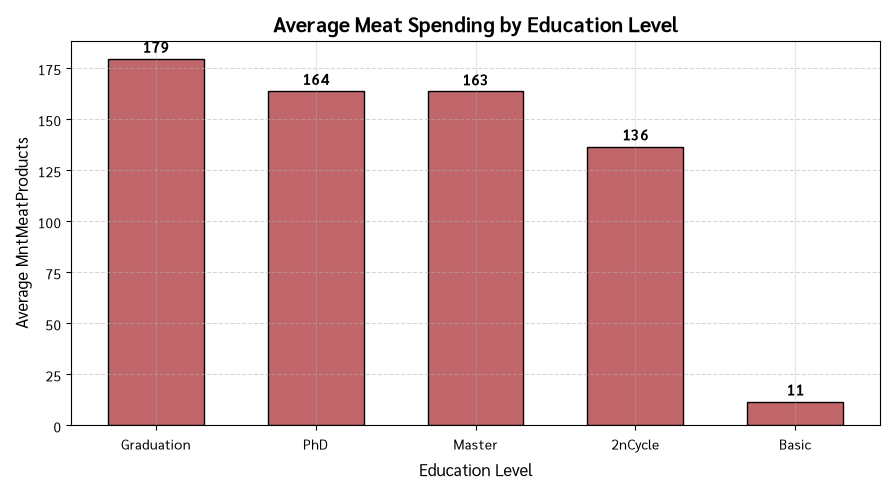


กลุ่มที่ใช้จ่ายสูงสุด : Graduation (179.31)
กลุ่มที่ใช้จ่ายต่ำสุด : Basic (11.44)
ส่วนต่าง             : 167.87 (15.67 เท่า)


In [40]:
# =============================================================================
# Exercise 6: Meat purchase analysis by Education
# =============================================================================
# คำนวณยอดใช้จ่ายค่าเนื้อสัตว์เฉลี่ย แยกตามระดับการศึกษา

target = "MntMeatProducts"
group_by = "Education"

# --- คำนวณค่าเฉลี่ยเท่านั้น (ตามที่โจทย์ถาม) ---
avg_meat = df.groupby(group_by)[target].mean().sort_values(ascending=False)

print("=" * 60)
print(f"ค่าเฉลี่ย {target} แยกตาม {group_by}")
print("=" * 60)
for edu, val in avg_meat.items():
    print(f"  {edu:<14} : {val:>8,.2f}")

# --- ขยายผล: ดูสถิติหลายตัวพร้อมกันด้วย .agg() ---
summary = (df.groupby(group_by)[target]
             .agg(["count", "mean", "median", "std", "max"])
             .sort_values("mean", ascending=False)
             .round(2))

print("\nตารางสรุปแบบละเอียด (.agg):")
print(summary.to_string())

# --- วาด Bar Chart เรียงจากมากไปน้อย ---
plt.figure(figsize=(9, 5))
bars = plt.bar(avg_meat.index, avg_meat.values,
               color="#C1666B", edgecolor="black", width=0.6)

for bar, v in zip(bars, avg_meat.values):
    plt.text(bar.get_x() + bar.get_width() / 2, v + 3, f"{v:,.0f}",
             ha="center", fontsize=11, fontweight="bold")

plt.title("Average Meat Spending by Education Level", fontsize=15, fontweight="bold")
plt.xlabel("Education Level", fontsize=12)
plt.ylabel("Average MntMeatProducts", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# --- สรุป Insight ---
print(f"\nกลุ่มที่ใช้จ่ายสูงสุด : {avg_meat.index[0]} ({avg_meat.iloc[0]:,.2f})")
print(f"กลุ่มที่ใช้จ่ายต่ำสุด : {avg_meat.index[-1]} ({avg_meat.iloc[-1]:,.2f})")
print(f"ส่วนต่าง             : {avg_meat.iloc[0] - avg_meat.iloc[-1]:,.2f} "
      f"({avg_meat.iloc[0] / avg_meat.iloc[-1]:.2f} เท่า)")

---

## Exercise 7 — Groupby usage

> **โจทย์:** Use GroupBy to calculate the average `Income` by marital status `Marital`.

**วัตถุประสงค์:** ฝึกใช้ GroupBy หาค่าเฉลี่ยรายได้ตามสถานภาพสมรส

### เปรียบเทียบ Mean กับ Median ใน GroupBy

เมื่อข้อมูลในกลุ่มมี **Outlier** ค่า `mean` จะถูกดึงไป แต่ `median` จะนิ่งกว่า
การดูทั้งสองค่าคู่กันจึงช่วยตรวจสอบว่าค่าเฉลี่ยที่ได้ "เชื่อถือได้" แค่ไหน

```
mean ≈ median  →  กลุ่มนั้นข้อมูลค่อนข้างสมมาตร ค่าเฉลี่ยใช้แทนกลุ่มได้ดี
mean >> median →  มีสมาชิกรายได้สูงผิดปกติดึงค่าเฉลี่ยขึ้น
```

### ข้อควรระวัง: กลุ่มที่มีสมาชิกน้อย (Small Sample)

กลุ่มที่มีสมาชิกไม่ถึง ~30 ราย ค่าเฉลี่ยจะผันผวนสูงและไม่ควรนำไปสรุป Insight ทางธุรกิจ
จึงควรดู `count` ประกอบเสมอ และถ้าจำเป็นอาจ **รวมกลุ่มเล็กเข้าด้วยกัน** (Grouping rare categories)

ค่าเฉลี่ย Income แยกตาม Marital
  Widow        :    56,481.55
  Divorced     :    52,465.12
  Together     :    51,553.20
  Married      :    51,350.51
  Single       :    51,009.62

ตารางสรุปแบบละเอียด:
          count      mean   median       std  pct_of_total
Marital                                                   
Widow        76  56481.55  56551.0  16837.95          3.45
Divorced    230  52465.12  52683.0  20227.71         10.43
Together    568  51553.20  51255.0  20358.59         25.76
Married     854  51350.51  51650.5  20532.40         38.73
Single      477  51009.62  48789.0  22162.84         21.63


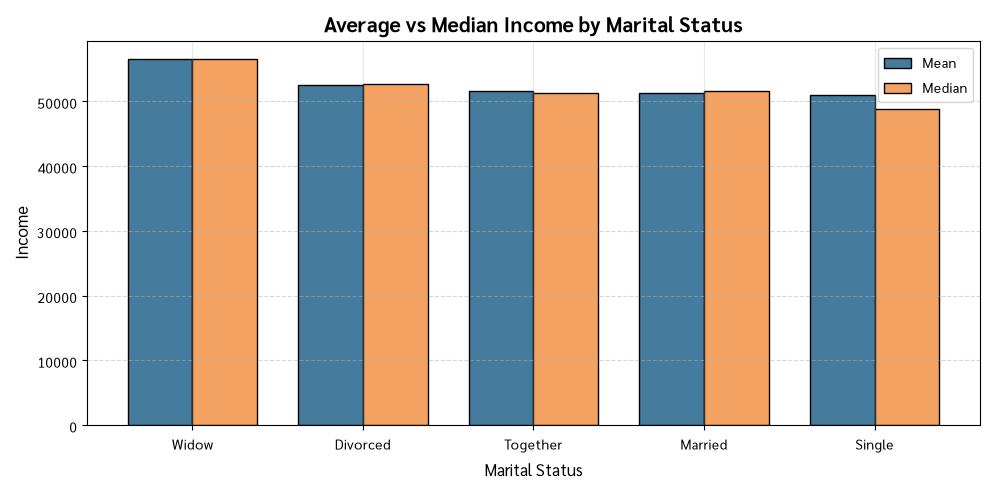


แปลผล: Mean และ Median ของแต่ละกลุ่มใกล้เคียงกัน
        แสดงว่ารายได้ภายในแต่ละกลุ่มสถานภาพสมรสค่อนข้างสมมาตร
        และรายได้ไม่ได้แตกต่างกันมากระหว่างสถานภาพสมรส


In [41]:
# =============================================================================
# Exercise 7: Average Income by Marital status (GroupBy)
# =============================================================================
# ใช้ GroupBy คำนวณรายได้เฉลี่ยตามสถานภาพสมรส

target = "Income"
group_by = "Marital"

# --- คำตอบตรงตามโจทย์: ค่าเฉลี่ย Income แยกตาม Marital ---
avg_income = df.groupby(group_by)[target].mean().sort_values(ascending=False)

print("=" * 60)
print(f"ค่าเฉลี่ย {target} แยกตาม {group_by}")
print("=" * 60)
for status, val in avg_income.items():
    print(f"  {status:<12} : {val:>12,.2f}")

# --- ขยายผล: ดู count / mean / median คู่กัน เพื่อตรวจความน่าเชื่อถือ ---
summary = (df.groupby(group_by)[target]
             .agg(["count", "mean", "median", "std"])
             .sort_values("mean", ascending=False)
             .round(2))
summary["pct_of_total"] = (summary["count"] / len(df) * 100).round(2)

print("\nตารางสรุปแบบละเอียด:")
print(summary.to_string())

# --- เตือนกลุ่มที่มีสมาชิกน้อย (Small sample) ---
small = summary[summary["count"] < 30]
if len(small) > 0:
    print(f"\nข้อควรระวัง: กลุ่ม {list(small.index)} มีสมาชิกน้อยกว่า 30 ราย")
    print("   ค่าเฉลี่ยของกลุ่มเหล่านี้ผันผวนสูง ไม่ควรนำไปสรุป Insight โดยตรง")

# --- วาดกราฟเปรียบเทียบ Mean vs Median ---
x = np.arange(len(summary))      # ตำแหน่งบนแกน X
width = 0.38                     # ความกว้างของแต่ละแท่ง

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, summary["mean"], width, label="Mean",
        color="#457B9D", edgecolor="black")
plt.bar(x + width/2, summary["median"], width, label="Median",
        color="#F4A261", edgecolor="black")

plt.xticks(x, summary.index)     # แทนตำแหน่งตัวเลขด้วยชื่อกลุ่ม
plt.title("Average vs Median Income by Marital Status", fontsize=15, fontweight="bold")
plt.xlabel("Marital Status", fontsize=12)
plt.ylabel("Income", fontsize=12)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("\nแปลผล: Mean และ Median ของแต่ละกลุ่มใกล้เคียงกัน")
print("        แสดงว่ารายได้ภายในแต่ละกลุ่มสถานภาพสมรสค่อนข้างสมมาตร")
print("        และรายได้ไม่ได้แตกต่างกันมากระหว่างสถานภาพสมรส")

---

## Exercise 8 — Response proportion

> **โจทย์:** Calculate the proportion of customers who responded to the latest campaign (`Response = 1`).

**วัตถุประสงค์:** หาสัดส่วนลูกค้าที่ตอบรับแคมเปญล่าสุด = **Response Rate** ของแคมเปญ

### เทคนิคสำคัญ: ค่าเฉลี่ยของคอลัมน์ 0/1 = สัดส่วน

เมื่อคอลัมน์มีค่าเป็น **0 หรือ 1** เท่านั้น (Binary / Dummy variable)

```
mean = (ผลรวมของทุกค่า) / (จำนวนข้อมูล)
     = (จำนวนที่เป็น 1) / (จำนวนทั้งหมด)
     = สัดส่วนของ 1
```

ดังนั้น `df["Response"].mean()` ให้ผลเท่ากับ `(df["Response"] == 1).sum() / len(df)`

### 3 วิธีคำนวณสัดส่วนที่ให้ผลเหมือนกัน

| วิธี | Code |
|------|------|
| ค่าเฉลี่ยของคอลัมน์ Binary | `df["Response"].mean()` |
| นับแล้วหาร | `(df["Response"] == 1).sum() / len(df)` |
| `value_counts` แบบ normalize | `df["Response"].value_counts(normalize=True)[1]` |

### เกณฑ์เทียบเคียงทางการตลาด

Response Rate ของ Direct Marketing ทั่วไปอยู่ราว **1–5%** ดังนั้นค่าที่ได้จะบอกได้ว่าแคมเปญนี้ทำได้ดีกว่าหรือแย่กว่ามาตรฐานอุตสาหกรรม

สัดส่วนลูกค้าที่ตอบรับแคมเปญล่าสุด (Response Rate)
ตอบรับ     (Response=1) :    333 ราย
ไม่ตอบรับ  (Response=0) :  1,872 ราย
รวมทั้งหมด              :  2,205 ราย
------------------------------------------------------------
Response Rate = 333 / 2,205 = 0.1510 = 15.10%
------------------------------------------------------------
ตรวจสอบผลลัพธ์จาก 3 วิธี:
  .mean()                      : 0.151020
  (col==1).sum() / len(df)     : 0.151020
  value_counts(normalize)[1]   : 0.151020


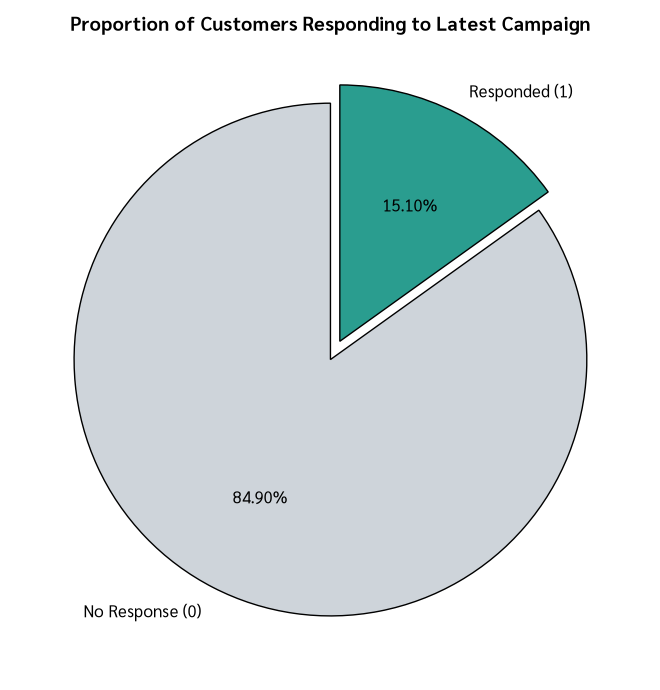


แปลผล: Response Rate = 15.10%
        เกณฑ์ทั่วไปของ Direct Marketing อยู่ราว 1-5%
        -> แคมเปญนี้ทำได้ดีกว่าค่าเฉลี่ยอุตสาหกรรม
        หมายความว่าทุก 100 ราย มีผู้ตอบรับราว 15 ราย


In [42]:
# =============================================================================
# Exercise 8: Response proportion (Campaign Response Rate)
# =============================================================================
# คำนวณสัดส่วนลูกค้าที่ตอบรับแคมเปญล่าสุด (Response = 1)

col = "Response"

# --- วิธีที่ 1: ใช้ .mean() ของคอลัมน์ 0/1 (สั้นที่สุด) ---
prop_mean = df[col].mean()

# --- วิธีที่ 2: นับจำนวนแล้วหารด้วยจำนวนทั้งหมด ---
n_responded = (df[col] == 1).sum()
n_total = len(df)
prop_count = n_responded / n_total

# --- วิธีที่ 3: ใช้ value_counts(normalize=True) ---
prop_vc = df[col].value_counts(normalize=True)

print("=" * 60)
print("สัดส่วนลูกค้าที่ตอบรับแคมเปญล่าสุด (Response Rate)")
print("=" * 60)
print(f"ตอบรับ     (Response=1) : {n_responded:>6,} ราย")
print(f"ไม่ตอบรับ  (Response=0) : {n_total - n_responded:>6,} ราย")
print(f"รวมทั้งหมด              : {n_total:>6,} ราย")
print("-" * 60)
print(f"Response Rate = {n_responded:,} / {n_total:,} = {prop_count:.4f} = {prop_count*100:.2f}%")

# --- ตรวจสอบว่าทั้ง 3 วิธีให้ผลเท่ากัน ---
print("-" * 60)
print("ตรวจสอบผลลัพธ์จาก 3 วิธี:")
print(f"  .mean()                      : {prop_mean:.6f}")
print(f"  (col==1).sum() / len(df)     : {prop_count:.6f}")
print(f"  value_counts(normalize)[1]   : {prop_vc[1]:.6f}")

# --- วาด Pie Chart แสดงสัดส่วน ---
plt.figure(figsize=(7, 7))
plt.pie([n_total - n_responded, n_responded],
        labels=["No Response (0)", "Responded (1)"],
        autopct="%1.2f%%",                  # แสดงเปอร์เซ็นต์ทศนิยม 2 ตำแหน่ง
        colors=["#CED4DA", "#2A9D8F"],
        explode=(0, 0.08),                  # ดึงชิ้นที่สนใจออกมาเล็กน้อย
        startangle=90,
        textprops={"fontsize": 12},
        wedgeprops={"edgecolor": "black"})
plt.title("Proportion of Customers Responding to Latest Campaign",
          fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# --- เทียบกับเกณฑ์มาตรฐานอุตสาหกรรม ---
print(f"\nแปลผล: Response Rate = {prop_count*100:.2f}%")
print("        เกณฑ์ทั่วไปของ Direct Marketing อยู่ราว 1-5%")
if prop_count > 0.05:
    print("        -> แคมเปญนี้ทำได้ดีกว่าค่าเฉลี่ยอุตสาหกรรม")
print(f"        หมายความว่าทุก 100 ราย มีผู้ตอบรับราว {prop_count*100:.0f} ราย")

---

## Exercise 9 — Bar chart of marital status

> **โจทย์:** Create a bar chart showing the number of customers in each marital status category `Marital` using Matplotlib.

**วัตถุประสงค์:** แสดงจำนวนลูกค้าในแต่ละสถานภาพสมรสด้วย Bar Chart

### `value_counts()` — เครื่องมือคู่กับ Bar Chart

```python
freq = df["Marital"].value_counts()
```

คืนค่าเป็น **Series** ที่ `index` = ชื่อหมวดหมู่ และ `values` = จำนวนนับ
เรียงจากมากไปน้อยโดยอัตโนมัติ ทำให้นำไปใส่ `plt.bar(freq.index, freq.values)` ได้ทันที

### Bar Chart แนวตั้ง vs แนวนอน

| รูปแบบ | Function | เหมาะเมื่อ |
|--------|----------|-----------|
| แนวตั้ง (Vertical) | `plt.bar()` | ชื่อหมวดหมู่สั้น, จำนวนหมวดน้อย |
| แนวนอน (Horizontal) | `plt.barh()` | ชื่อหมวดหมู่ยาว, จำนวนหมวดมาก |

### เทคนิคการเขียนตัวเลขกำกับบนแท่ง (Data Label)

```python
for bar, v in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, v, f"{v:,}", ha="center")
```

`bar.get_x() + bar.get_width()/2` คือตำแหน่ง **กึ่งกลาง** ของแท่งบนแกน X ทำให้ตัวเลขวางตรงกลางพอดี

จำนวนลูกค้าแยกตาม Marital
Marital Status    จำนวน    สัดส่วน
------------------------------------------------------------
Married             854     38.73%
Together            568     25.76%
Single              477     21.63%
Divorced            230     10.43%
Widow                76      3.45%
------------------------------------------------------------
Total             2,205    100.00%


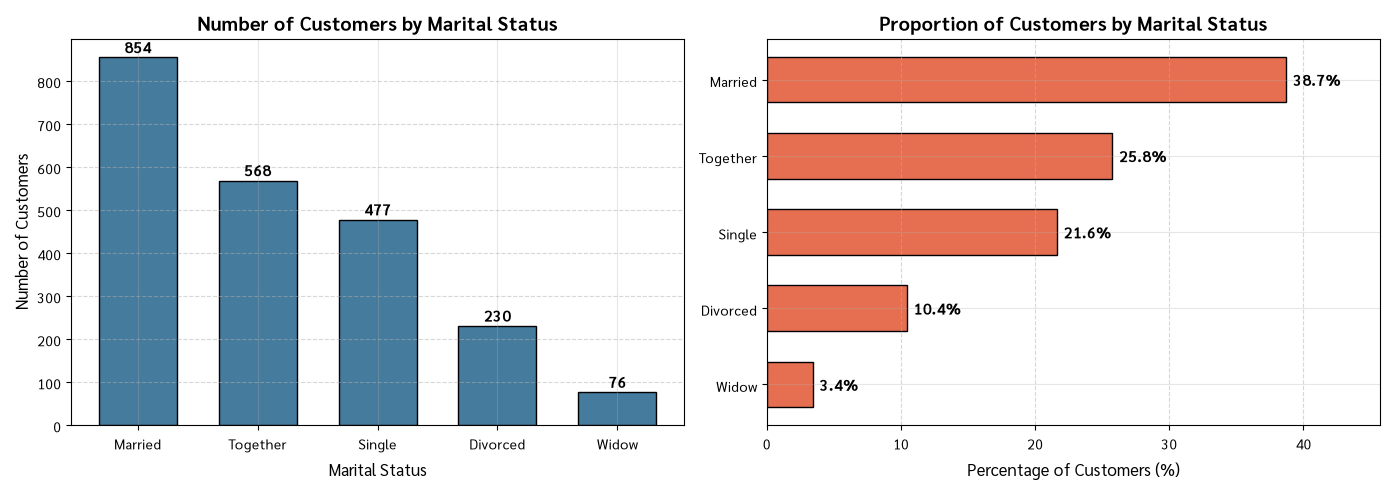


แปลผล: กลุ่มใหญ่ที่สุดคือ Married (38.7%)
        ลูกค้าที่มีคู่ (Married + Together) รวมกัน 64.5%
        แสดงว่าฐานลูกค้าหลักเป็นกลุ่มครอบครัว ไม่ใช่กลุ่มโสด


In [43]:
# =============================================================================
# Exercise 9: Bar chart of Marital status
# =============================================================================
# สร้าง Bar Chart แสดงจำนวนลูกค้าในแต่ละสถานภาพสมรส

col = "Marital"

# --- นับความถี่และสัดส่วนของแต่ละหมวดหมู่ ---
freq = df[col].value_counts()                     # จำนวนนับ เรียงมาก -> น้อย
prop = df[col].value_counts(normalize=True) * 100 # สัดส่วน (%)

print("=" * 60)
print(f"จำนวนลูกค้าแยกตาม {col}")
print("=" * 60)
print(f"{'Marital Status':<14} {'จำนวน':>8} {'สัดส่วน':>10}")
print("-" * 60)
for status in freq.index:
    print(f"{status:<14} {freq[status]:>8,} {prop[status]:>9.2f}%")
print("-" * 60)
print(f"{'Total':<14} {freq.sum():>8,} {100.0:>9.2f}%")

# --- สร้าง Figure 2 แผงเปรียบเทียบ: Frequency (แนวตั้ง) และ Proportion (แนวนอน) ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# แผงซ้าย: Bar Chart แนวตั้งแสดงจำนวน
bars = ax[0].bar(freq.index, freq.values,
                 color="#457B9D", edgecolor="black", width=0.65)
for bar, v in zip(bars, freq.values):
    # วางตัวเลขกึ่งกลางแท่ง เหนือหัวแท่งเล็กน้อย
    ax[0].text(bar.get_x() + bar.get_width()/2, v + 10, f"{v:,}",
               ha="center", fontsize=11, fontweight="bold")
ax[0].set_title("Number of Customers by Marital Status", fontsize=14, fontweight="bold")
ax[0].set_xlabel("Marital Status", fontsize=12)
ax[0].set_ylabel("Number of Customers", fontsize=12)
ax[0].grid(axis="y", linestyle="--", alpha=0.5)

# แผงขวา: Bar Chart แนวนอนแสดงสัดส่วน (เรียงน้อย -> มาก ให้แท่งยาวอยู่บน)
prop_sorted = prop.sort_values()
barsh = ax[1].barh(prop_sorted.index, prop_sorted.values,
                   color="#E76F51", edgecolor="black", height=0.6)
for bar, v in zip(barsh, prop_sorted.values):
    ax[1].text(v + 0.5, bar.get_y() + bar.get_height()/2, f"{v:.1f}%",
               va="center", fontsize=11, fontweight="bold")
ax[1].set_title("Proportion of Customers by Marital Status", fontsize=14, fontweight="bold")
ax[1].set_xlabel("Percentage of Customers (%)", fontsize=12)
ax[1].set_xlim(0, prop_sorted.max() * 1.18)   # เผื่อที่ว่างให้ Label ไม่ล้นขอบ
ax[1].grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nแปลผล: กลุ่มใหญ่ที่สุดคือ {freq.index[0]} ({prop[freq.index[0]]:.1f}%)")
couple = prop.get("Married", 0) + prop.get("Together", 0)
print(f"        ลูกค้าที่มีคู่ (Married + Together) รวมกัน {couple:.1f}%")
print("        แสดงว่าฐานลูกค้าหลักเป็นกลุ่มครอบครัว ไม่ใช่กลุ่มโสด")

---

## Exercise 10 — Correlation income vs wine

> **โจทย์:** Calculate the Pearson correlation between `Income` and `MntWines`.

**วัตถุประสงค์:** วัดความสัมพันธ์เชิงเส้นระหว่างรายได้กับยอดใช้จ่ายค่าไวน์

### Pearson Correlation Coefficient (r)

วัด **ความสัมพันธ์เชิงเส้น** ระหว่างตัวแปรตัวเลข 2 ตัว มีค่าระหว่าง **−1 ถึง +1**

| ค่า r | ความหมาย |
|-------|----------|
| `r = +1` | สัมพันธ์เชิงเส้นบวกสมบูรณ์ — ตัวหนึ่งเพิ่ม อีกตัวเพิ่มตามเป็นเส้นตรง |
| `r = 0` | ไม่มีความสัมพันธ์**เชิงเส้น** |
| `r = −1` | สัมพันธ์เชิงเส้นลบสมบูรณ์ |

### เกณฑ์การแปลความแรงของ r (ค่าสัมบูรณ์)

| \|r\| | ระดับความสัมพันธ์ |
|------|-------------------|
| 0.00 – 0.19 | อ่อนมาก (Very weak) |
| 0.20 – 0.39 | อ่อน (Weak) |
| 0.40 – 0.59 | ปานกลาง (Moderate) |
| 0.60 – 0.79 | ค่อนข้างแรง (Strong) |
| 0.80 – 1.00 | แรงมาก (Very strong) |

### 3 วิธีคำนวณใน Python

```python
df["Income"].corr(df["MntWines"])                    # Pandas — ง่ายสุด
np.corrcoef(df["Income"], df["MntWines"])[0, 1]      # NumPy — คืน matrix
scipy.stats.pearsonr(df["Income"], df["MntWines"])   # SciPy — ได้ p-value ด้วย
```

> **คำเตือนสำคัญ: Correlation ≠ Causation**
> ค่า r สูงบอกแค่ว่าสองตัวแปร "เปลี่ยนไปด้วยกัน" ไม่ได้พิสูจน์ว่าตัวหนึ่ง **ทำให้เกิด** อีกตัว
> และ r วัดได้เฉพาะความสัมพันธ์ **เชิงเส้น** — ถ้าความสัมพันธ์เป็นรูปโค้ง r อาจใกล้ 0 แม้จะสัมพันธ์กันจริง

Pearson Correlation : Income vs MntWines
pandas  .corr()     : r = 0.7305
numpy   .corrcoef() : r = 0.7305
scipy   .pearsonr() : r = 0.7305  (p-value = 0.000e+00)
------------------------------------------------------------
ทิศทาง      : บวก (Positive)
ความแรง     : ค่อนข้างแรง (Strong)
R-squared   : 0.5336 -> Income อธิบายความผันแปรของ MntWines ได้ 53.4%
นัยสำคัญ    : p-value = 0.000e+00 < 0.05 -> มีนัยสำคัญทางสถิติ


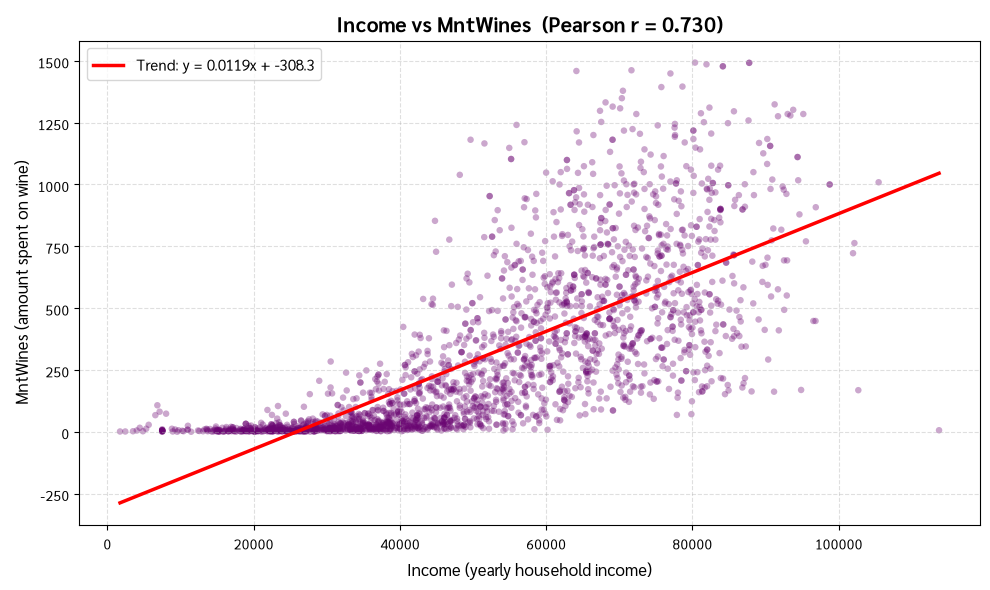


แปลผล: r = 0.730 แสดงความสัมพันธ์บวก (Positive)ระดับค่อนข้างแรง (Strong)
        ทุก ๆ รายได้ที่เพิ่มขึ้น 1,000 หน่วย ยอดใช้จ่ายไวน์เพิ่มราว 11.9 หน่วย
        ข้อควรระวัง: Correlation ไม่ได้พิสูจน์ความเป็นเหตุเป็นผล (Causation)


In [44]:
# =============================================================================
# Exercise 10: Pearson correlation between Income and MntWines
# =============================================================================
# คำนวณสหสัมพันธ์เพียร์สันระหว่างรายได้กับยอดใช้จ่ายค่าไวน์

from scipy import stats    # ใช้หา p-value เพื่อทดสอบนัยสำคัญทางสถิติ

x_col, y_col = "Income", "MntWines"

# --- วิธีที่ 1: Pandas .corr() (ค่าเริ่มต้นคือ method="pearson") ---
r_pandas = df[x_col].corr(df[y_col])

# --- วิธีที่ 2: NumPy corrcoef() — คืนค่าเป็น Correlation Matrix 2x2 ---
r_numpy = np.corrcoef(df[x_col], df[y_col])[0, 1]

# --- วิธีที่ 3: SciPy pearsonr() — ได้ทั้ง r และ p-value ---
r_scipy, p_value = stats.pearsonr(df[x_col], df[y_col])

print("=" * 60)
print(f"Pearson Correlation : {x_col} vs {y_col}")
print("=" * 60)
print(f"pandas  .corr()     : r = {r_pandas:.4f}")
print(f"numpy   .corrcoef() : r = {r_numpy:.4f}")
print(f"scipy   .pearsonr() : r = {r_scipy:.4f}  (p-value = {p_value:.3e})")

# --- แปลความแรงของความสัมพันธ์ตามเกณฑ์ ---
abs_r = abs(r_pandas)
if abs_r < 0.2:
    strength = "อ่อนมาก (Very weak)"
elif abs_r < 0.4:
    strength = "อ่อน (Weak)"
elif abs_r < 0.6:
    strength = "ปานกลาง (Moderate)"
elif abs_r < 0.8:
    strength = "ค่อนข้างแรง (Strong)"
else:
    strength = "แรงมาก (Very strong)"

direction = "บวก (Positive)" if r_pandas > 0 else "ลบ (Negative)"
print("-" * 60)
print(f"ทิศทาง      : {direction}")
print(f"ความแรง     : {strength}")
print(f"R-squared   : {r_pandas**2:.4f} -> Income อธิบายความผันแปรของ {y_col} "
      f"ได้ {r_pandas**2*100:.1f}%")
print(f"นัยสำคัญ    : p-value = {p_value:.3e} "
      f"{'< 0.05 -> มีนัยสำคัญทางสถิติ' if p_value < 0.05 else '>= 0.05 -> ไม่มีนัยสำคัญ'}")

# --- วาด Scatter Plot พร้อมเส้นแนวโน้ม (Trend Line) ---
plt.figure(figsize=(10, 6))
plt.scatter(df[x_col], df[y_col], alpha=0.35, s=22,
            color="#6A0572", edgecolors="none")

# คำนวณเส้นถดถอยเชิงเส้นด้วย np.polyfit (degree=1 คือเส้นตรง)
slope, intercept = np.polyfit(df[x_col], df[y_col], 1)
x_line = np.linspace(df[x_col].min(), df[x_col].max(), 100)
plt.plot(x_line, slope * x_line + intercept, color="red", linewidth=2.5,
         label=f"Trend: y = {slope:.4f}x + {intercept:.1f}")

plt.title(f"{x_col} vs {y_col}  (Pearson r = {r_pandas:.3f})",
          fontsize=15, fontweight="bold")
plt.xlabel("Income (yearly household income)", fontsize=12)
plt.ylabel("MntWines (amount spent on wine)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\nแปลผล: r = {r_pandas:.3f} แสดงความสัมพันธ์{direction}ระดับ{strength}")
print(f"        ทุก ๆ รายได้ที่เพิ่มขึ้น 1,000 หน่วย ยอดใช้จ่ายไวน์เพิ่มราว {slope*1000:.1f} หน่วย")
print("        ข้อควรระวัง: Correlation ไม่ได้พิสูจน์ความเป็นเหตุเป็นผล (Causation)")

---

## Exercise 11 — Boxplot income by education

> **โจทย์:** Create a boxplot of `Income` grouped by education level `Education`.

**วัตถุประสงค์:** เปรียบเทียบการกระจายตัวของรายได้ระหว่างระดับการศึกษาด้วย Box Plot

### Five-Number Summary ที่ Box Plot แสดง

| ส่วนประกอบ | ค่า | ความหมาย |
|------------|-----|----------|
| ขอบล่างของกล่อง | **Q1** | เปอร์เซ็นไทล์ที่ 25 |
| เส้นกลางกล่อง | **Median (Q2)** | เปอร์เซ็นไทล์ที่ 50 |
| ขอบบนของกล่อง | **Q3** | เปอร์เซ็นไทล์ที่ 75 |
| หนวดล่าง / บน | **Whisker** | ขอบเขตข้อมูลปกติ (1.5 × IQR) |
| จุดนอกหนวด | **Outlier (Flier)** | ค่าผิดปกติ |

### ทำไม Box Plot เหมาะกับการเปรียบเทียบหลายกลุ่ม

Bar Chart แสดงได้แค่ **ค่าเดียว** (ค่าเฉลี่ย) ต่อกลุ่ม แต่ Box Plot แสดง **การกระจายตัวทั้งหมด** พร้อมกัน ทำให้เห็นว่า

- กลุ่มไหน**เกาะกลุ่ม**กันแน่น (กล่องเตี้ย) กลุ่มไหน**กระจาย**กว้าง (กล่องสูง)
- กลุ่มไหนมี **Outlier** มาก
- ค่ากลางของกลุ่มต่างกันจริงหรือแค่เพราะ Outlier ดึง

### การเตรียมข้อมูลสำหรับ `plt.boxplot()`

```python
data = [df[df["Education"] == lvl]["Income"] for lvl in levels]
plt.boxplot(data, labels=levels)
```

ต้องส่งเป็น **list ของ Series/array** โดยแต่ละสมาชิกคือข้อมูลของ 1 กลุ่ม

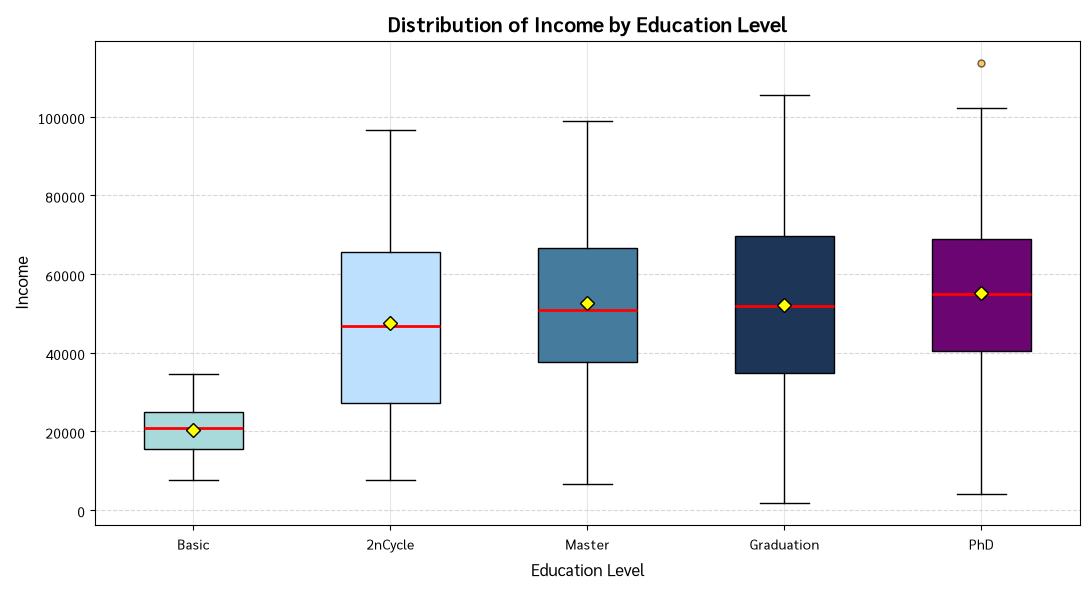

Five-Number Summary ของ Income แยกตาม Education
            count   min        Q1   median        Q3     max      mean       IQR
Education                                                                       
Basic          54  7500  15405.25  20744.0  24882.00   34445  20306.26   9476.75
2nCycle       198  7500  27113.50  46805.0  65439.75   96547  47625.33  38326.25
Master        364  6560  37697.25  50920.5  66658.50   98777  52629.58  28961.25
Graduation   1113  1730  34824.00  51948.0  69755.00  105471  51984.01  34931.00
PhD           476  4023  40334.00  55005.0  68869.50  113734  55220.58  28535.50

จำนวน Outlier แต่ละกลุ่ม (เกณฑ์ 1.5 x IQR):
  Basic          :   0 ราย จาก   54 ราย ( 0.00%)
  2nCycle        :   0 ราย จาก  198 ราย ( 0.00%)
  Master         :   0 ราย จาก  364 ราย ( 0.00%)
  Graduation     :   0 ราย จาก 1113 ราย ( 0.00%)
  PhD            :   1 ราย จาก  476 ราย ( 0.21%)

แปลผล: กลุ่ม PhD มี Median รายได้สูงสุด, กลุ่ม Basic ต่ำสุด
        กล่องที่สูงแสดงว่ารายได้ภา

In [45]:
# =============================================================================
# Exercise 11: Boxplot of Income grouped by Education
# =============================================================================
# เปรียบเทียบการกระจายตัวของรายได้ในแต่ละระดับการศึกษา

target, group_by = "Income", "Education"

# --- เรียงระดับการศึกษาตามค่า Median เพื่อให้กราฟอ่านแนวโน้มได้ง่าย ---
order = df.groupby(group_by)[target].median().sort_values().index.tolist()

# --- เตรียมข้อมูล: list ของ Series โดยแต่ละตัวคือ Income ของ 1 กลุ่ม ---
data = [df.loc[df[group_by] == lvl, target] for lvl in order]

# --- วาด Box Plot ---
plt.figure(figsize=(11, 6))
bp = plt.boxplot(data, tick_labels=order, patch_artist=True, showmeans=True,
                 boxprops=dict(color="black"),
                 medianprops=dict(color="red", linewidth=2),
                 whiskerprops=dict(color="black"),
                 capprops=dict(color="black"),
                 meanprops=dict(marker="D", markerfacecolor="yellow",
                                markeredgecolor="black", markersize=7),
                 flierprops=dict(marker="o", markerfacecolor="orange",
                                 markersize=5, alpha=0.6))

# --- ไล่สีแต่ละกล่องให้แยกกลุ่มได้ชัด ---
colors = ["#A8DADC", "#BDE0FE", "#457B9D", "#1D3557", "#6A0572"]
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)

plt.title("Distribution of Income by Education Level", fontsize=15, fontweight="bold")
plt.xlabel("Education Level", fontsize=12)
plt.ylabel("Income", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# --- ตารางสรุป Five-Number Summary ของแต่ละกลุ่ม ---
summary = df.groupby(group_by)[target].agg(
    count="count",
    min="min",
    Q1=lambda s: s.quantile(0.25),
    median="median",
    Q3=lambda s: s.quantile(0.75),
    max="max",
    mean="mean",
).round(2)
summary["IQR"] = (summary["Q3"] - summary["Q1"]).round(2)
summary = summary.loc[order]       # เรียงให้ตรงกับลำดับในกราฟ

print("=" * 95)
print(f"Five-Number Summary ของ {target} แยกตาม {group_by}")
print("=" * 95)
print(summary.to_string())

# --- นับ Outlier ของแต่ละกลุ่มด้วยเกณฑ์ 1.5 x IQR ---
print("\nจำนวน Outlier แต่ละกลุ่ม (เกณฑ์ 1.5 x IQR):")
for lvl in order:
    s = df.loc[df[group_by] == lvl, target]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    n_out = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()
    print(f"  {lvl:<14} : {n_out:>3} ราย จาก {len(s):>4} ราย ({n_out/len(s)*100:>5.2f}%)")

print(f"\nแปลผล: กลุ่ม {order[-1]} มี Median รายได้สูงสุด, กลุ่ม {order[0]} ต่ำสุด")
print("        กล่องที่สูงแสดงว่ารายได้ภายในกลุ่มนั้นกระจายตัวกว้าง")

---

## Exercise 12 — Skewness and kurtosis

> **โจทย์:** Calculate the skewness and kurtosis of the `MntGoldProds` column.

**วัตถุประสงค์:** วัด **รูปร่าง** ของการกระจายตัว (Shape) ของยอดใช้จ่ายสินค้าพรีเมียม

### Skewness (ความเบ้) — วัดความไม่สมมาตร

| ค่า Skewness | รูปร่าง | ลักษณะ |
|--------------|---------|--------|
| `> 0` | **เบ้ขวา** (Right / Positive skew) | หางยาวไปทางขวา, Mean > Median |
| `≈ 0` | **สมมาตร** (Symmetric) | Mean ≈ Median |
| `< 0` | **เบ้ซ้าย** (Left / Negative skew) | หางยาวไปทางซ้าย, Mean < Median |

**เกณฑ์ความรุนแรง:** `|skew| < 0.5` สมมาตรพอใช้ · `0.5–1.0` เบ้ปานกลาง · `> 1.0` เบ้มาก

### Kurtosis (ความโด่ง) — วัดความหนาของหาง

Pandas ใช้ **Excess Kurtosis** คือหักค่าของการแจกแจงปกติ (3) ออกแล้ว ดังนั้นเกณฑ์เทียบคือ **0**

| ค่า Kurtosis | ชื่อเรียก | ลักษณะ |
|--------------|----------|--------|
| `> 0` | **Leptokurtic** | ยอดแหลม หางหนา → **Outlier มาก** |
| `≈ 0` | **Mesokurtic** | ใกล้เคียงการแจกแจงปกติ |
| `< 0` | **Platykurtic** | ยอดแบน หางบาง → Outlier น้อย |

### ทำไมต้องสนใจ?

ข้อมูลที่เบ้มากและหางหนาจะทำให้ **ค่าเฉลี่ยใช้แทนกลุ่มไม่ได้** และละเมิดข้อสมมติของโมเดลสถิติหลายตัว
แนวทางแก้ทั่วไปคือ **Log Transformation** — `np.log1p(x)` ใช้ `log(1+x)` จึงรองรับค่า 0 ได้

Shape Statistics ของ MntGoldProds
Mean     :      44.06
Median   :      25.00
Std      :      51.74
Skewness :     1.8345
Kurtosis :     3.1438   (Excess kurtosis: เทียบกับ 0)
-----------------------------------------------------------------
Skewness = 1.8345 -> เบ้ขวามาก (Highly right-skewed)
Kurtosis = 3.1438 -> Leptokurtic — ยอดแหลม หางหนา มี Outlier มากกว่าการแจกแจงปกติ


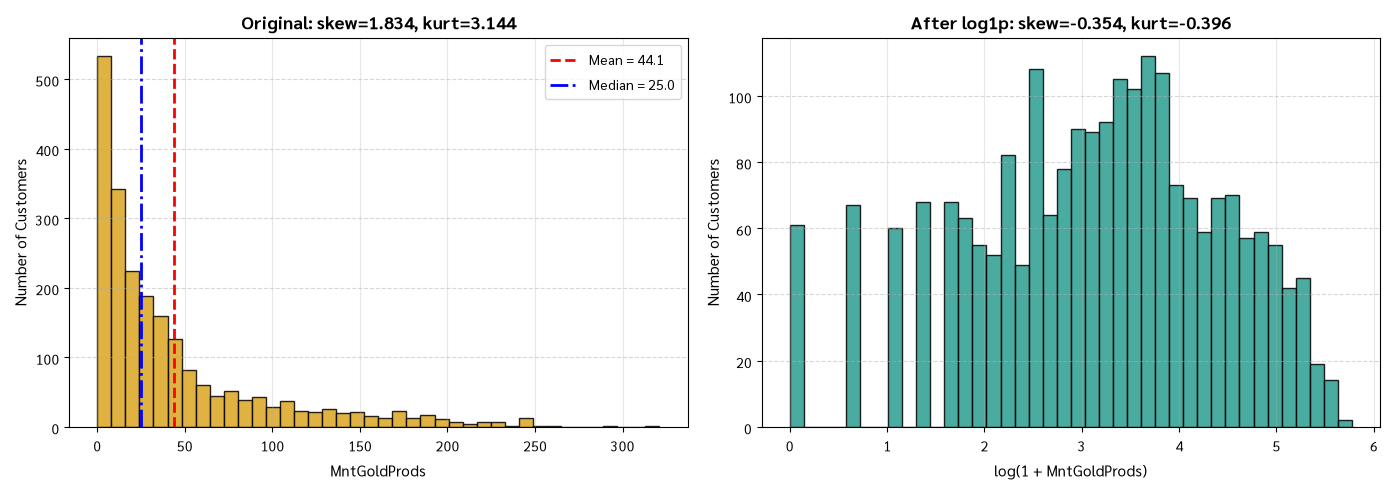


หลังทำ Log Transformation: Skewness ลดจาก 1.834 เหลือ -0.354
แปลผล: ลูกค้าส่วนใหญ่ใช้จ่ายสินค้าพรีเมียมน้อย แต่มีกลุ่มเล็กที่ใช้จ่ายสูงมาก
        ดังนั้นควรใช้ Median แทน Mean ในการรายงานค่ากลางของคอลัมน์นี้


In [46]:
# =============================================================================
# Exercise 12: Skewness and Kurtosis of MntGoldProds
# =============================================================================
# วัดรูปร่างการกระจายตัว (ความเบ้และความโด่ง) ของยอดใช้จ่ายสินค้าพรีเมียม

col = "MntGoldProds"

# --- คำนวณ Skewness และ Kurtosis ---
skewness = df[col].skew()       # ความเบ้ (Fisher-Pearson standardized)
kurtosis = df[col].kurt()       # ความโด่ง แบบ Excess (หัก 3 ออกแล้ว)

print("=" * 65)
print(f"Shape Statistics ของ {col}")
print("=" * 65)
print(f"Mean     : {df[col].mean():>10,.2f}")
print(f"Median   : {df[col].median():>10,.2f}")
print(f"Std      : {df[col].std():>10,.2f}")
print(f"Skewness : {skewness:>10.4f}")
print(f"Kurtosis : {kurtosis:>10.4f}   (Excess kurtosis: เทียบกับ 0)")

# --- แปลความหมาย Skewness ---
print("-" * 65)
if skewness > 1:
    skew_txt = "เบ้ขวามาก (Highly right-skewed)"
elif skewness > 0.5:
    skew_txt = "เบ้ขวาปานกลาง (Moderately right-skewed)"
elif skewness > -0.5:
    skew_txt = "ค่อนข้างสมมาตร (Approximately symmetric)"
elif skewness > -1:
    skew_txt = "เบ้ซ้ายปานกลาง (Moderately left-skewed)"
else:
    skew_txt = "เบ้ซ้ายมาก (Highly left-skewed)"
print(f"Skewness = {skewness:.4f} -> {skew_txt}")

# --- แปลความหมาย Kurtosis ---
if kurtosis > 0:
    kurt_txt = "Leptokurtic — ยอดแหลม หางหนา มี Outlier มากกว่าการแจกแจงปกติ"
elif kurtosis < 0:
    kurt_txt = "Platykurtic — ยอดแบน หางบาง มี Outlier น้อยกว่าการแจกแจงปกติ"
else:
    kurt_txt = "Mesokurtic — ใกล้เคียงการแจกแจงปกติ"
print(f"Kurtosis = {kurtosis:.4f} -> {kurt_txt}")

# --- เปรียบเทียบก่อน/หลังทำ Log Transformation ---
log_col = np.log1p(df[col])      # log(1+x) รองรับค่า 0 ได้

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# แผงซ้าย: ข้อมูลดิบ
ax[0].hist(df[col], bins=40, color="#DAA520", edgecolor="black", alpha=0.85)
ax[0].axvline(df[col].mean(), color="red", linestyle="--", linewidth=2,
              label=f"Mean = {df[col].mean():.1f}")
ax[0].axvline(df[col].median(), color="blue", linestyle="-.", linewidth=2,
              label=f"Median = {df[col].median():.1f}")
ax[0].set_title(f"Original: skew={skewness:.3f}, kurt={kurtosis:.3f}",
                fontsize=13, fontweight="bold")
ax[0].set_xlabel(col, fontsize=11)
ax[0].set_ylabel("Number of Customers", fontsize=11)
ax[0].legend()
ax[0].grid(axis="y", linestyle="--", alpha=0.5)

# แผงขวา: หลัง Log Transform — ดูว่าความเบ้ลดลงหรือไม่
ax[1].hist(log_col, bins=40, color="#2A9D8F", edgecolor="black", alpha=0.85)
ax[1].set_title(f"After log1p: skew={log_col.skew():.3f}, kurt={log_col.kurt():.3f}",
                fontsize=13, fontweight="bold")
ax[1].set_xlabel(f"log(1 + {col})", fontsize=11)
ax[1].set_ylabel("Number of Customers", fontsize=11)
ax[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nหลังทำ Log Transformation: Skewness ลดจาก {skewness:.3f} เหลือ {log_col.skew():.3f}")
print("แปลผล: ลูกค้าส่วนใหญ่ใช้จ่ายสินค้าพรีเมียมน้อย แต่มีกลุ่มเล็กที่ใช้จ่ายสูงมาก")
print("        ดังนั้นควรใช้ Median แทน Mean ในการรายงานค่ากลางของคอลัมน์นี้")

---

## Exercise 13 — Pairplot of purchases

> **โจทย์:** Create a pairplot of `MntWines`, `MntMeatProducts`, and `MntSweetProducts` to explore relationships.

**วัตถุประสงค์:** ดูความสัมพันธ์ของตัวแปรทั้ง 3 ตัวแบบ **ทุกคู่พร้อมกัน** ในภาพเดียว

### Pairplot คืออะไร?

ตารางกราฟขนาด **n × n** (n = จำนวนตัวแปร) โดย

| ตำแหน่ง | กราฟที่แสดง | บอกอะไร |
|---------|-------------|---------|
| **แนวทแยง** (Diagonal) | Histogram / KDE | การกระจายตัวของตัวแปรนั้นเอง |
| **นอกแนวทแยง** (Off-diagonal) | Scatter Plot | ความสัมพันธ์ระหว่างตัวแปร 2 ตัว |

ตัวแปร 3 ตัว → ตาราง 3 × 3 = 9 แผง (3 Histogram + 6 Scatter ซึ่งสมมาตรกัน 3 คู่)

### Parameter สำคัญของ `sns.pairplot()`

| Parameter | ความหมาย |
|-----------|----------|
| `vars=[...]` | เลือกคอลัมน์ที่ต้องการเท่านั้น |
| `diag_kind` | ชนิดกราฟแนวทแยง — `"hist"` หรือ `"kde"` |
| `kind` | ชนิดกราฟนอกแนวทแยง — `"scatter"` หรือ `"reg"` (เพิ่มเส้นถดถอย) |
| `hue` | ไล่สีตามคอลัมน์หมวดหมู่ — ช่วยเห็นความต่างระหว่างกลุ่ม |
| `corner=True` | แสดงเฉพาะครึ่งล่าง ลดความซ้ำซ้อน |

> **ข้อควรระวัง:** Pairplot ใช้เวลาวาดนานเมื่อข้อมูลมีหลายพันแถวและตัวแปรหลายตัว (n² แผง) — ควรเลือกตัวแปรเฉพาะที่สนใจ

Correlation Matrix ของ 3 หมวดสินค้า
                  MntWines  MntMeatProducts  MntSweetProducts
MntWines            1.0000           0.5931            0.3886
MntMeatProducts     0.5931           1.0000            0.5565
MntSweetProducts    0.3886           0.5565            1.0000

ความสัมพันธ์รายคู่ (เรียงจากแรงไปอ่อน):
  MntWines           vs MntMeatProducts    : r = 0.5931
  MntMeatProducts    vs MntSweetProducts   : r = 0.5565
  MntWines           vs MntSweetProducts   : r = 0.3886


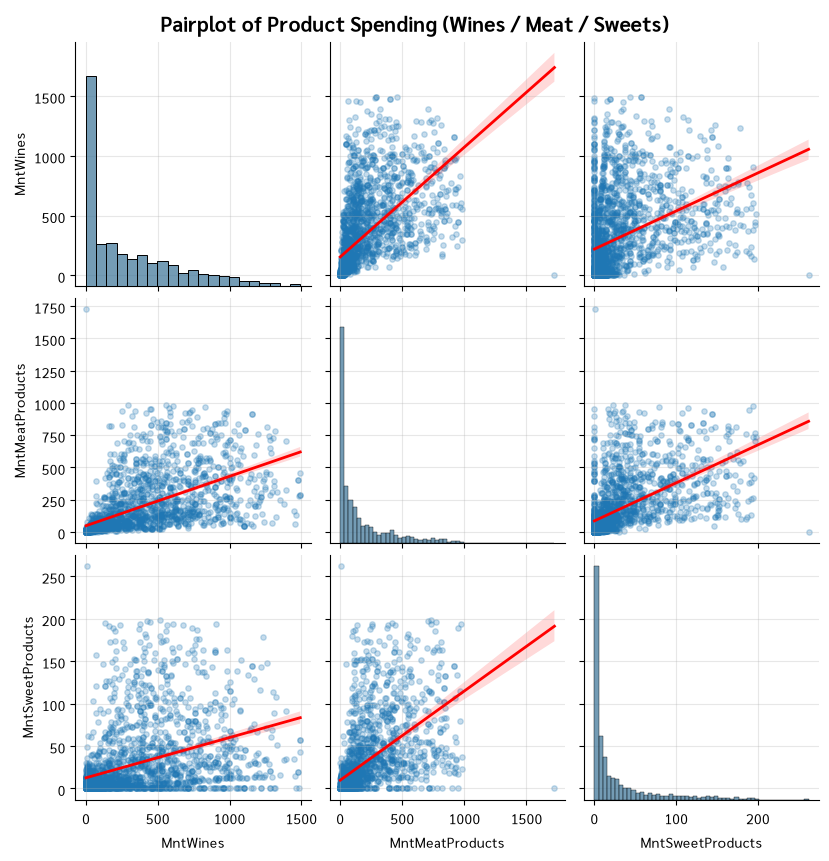

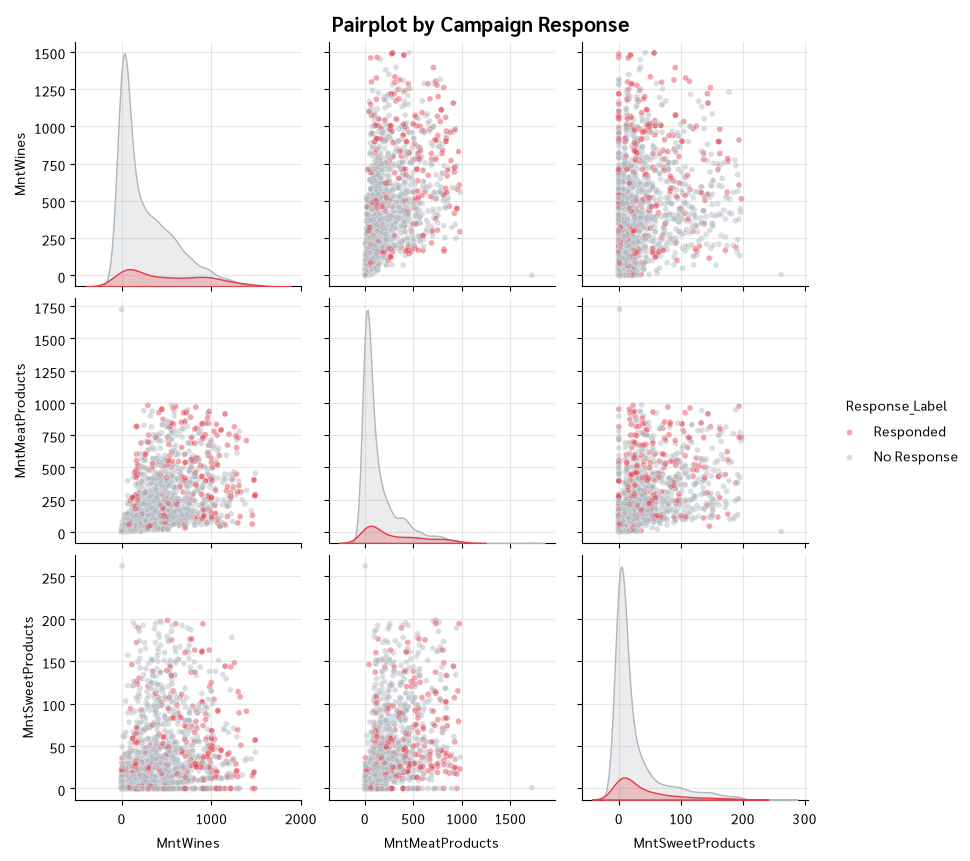


แปลผล: คู่ที่สัมพันธ์กันแรงที่สุดคือ MntWines กับ MntMeatProducts (r = 0.593)
        แนวทแยงแสดงว่าทุกหมวดสินค้าเบ้ขวา — ลูกค้าส่วนใหญ่ใช้จ่ายน้อย
        กราฟไล่สีตาม Response ชี้ว่าผู้ตอบรับแคมเปญกระจุกตัวในโซนใช้จ่ายสูง


In [47]:
# =============================================================================
# Exercise 13: Pairplot of product spending
# =============================================================================
# สำรวจความสัมพันธ์ระหว่างยอดใช้จ่าย 3 หมวดสินค้าแบบทุกคู่พร้อมกัน

cols = ["MntWines", "MntMeatProducts", "MntSweetProducts"]

# --- ดูค่า Correlation ของทุกคู่ก่อนวาดกราฟ เพื่อใช้อ่านกราฟประกอบ ---
corr = df[cols].corr()
print("=" * 60)
print("Correlation Matrix ของ 3 หมวดสินค้า")
print("=" * 60)
print(corr.round(4).to_string())

print("\nความสัมพันธ์รายคู่ (เรียงจากแรงไปอ่อน):")
pairs = []
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        pairs.append((cols[i], cols[j], corr.iloc[i, j]))
for a, b, r in sorted(pairs, key=lambda t: abs(t[2]), reverse=True):
    print(f"  {a:<18} vs {b:<18} : r = {r:.4f}")

# --- วาด Pairplot: kind="reg" เพิ่มเส้นถดถอยในแต่ละ Scatter ---
g = sns.pairplot(df[cols],
                 diag_kind="hist",                         # แนวทแยงเป็น Histogram
                 kind="reg",                               # นอกแนวทแยงมีเส้นแนวโน้ม
                 plot_kws={"scatter_kws": {"alpha": 0.25, "s": 15},
                           "line_kws": {"color": "red", "linewidth": 2}},
                 diag_kws={"color": "#457B9D", "edgecolor": "black"},
                 height=2.8)

g.figure.suptitle("Pairplot of Product Spending (Wines / Meat / Sweets)",
                  y=1.02, fontsize=15, fontweight="bold")
plt.show()

# --- เวอร์ชันที่ 2: ไล่สีตาม Response เพื่อดูว่าผู้ตอบรับแคมเปญใช้จ่ายต่างกันไหม ---
df["Response_Label"] = df["Response"].map({0: "No Response", 1: "Responded"})
g2 = sns.pairplot(df[cols + ["Response_Label"]],
                  hue="Response_Label",                    # ไล่สีตามการตอบรับแคมเปญ
                  diag_kind="kde",                         # แนวทแยงเป็นเส้นความหนาแน่น
                  palette={"No Response": "#ADB5BD", "Responded": "#E63946"},
                  plot_kws={"alpha": 0.45, "s": 18},
                  height=2.8)

g2.figure.suptitle("Pairplot by Campaign Response", y=1.02, fontsize=15, fontweight="bold")
plt.show()

strongest = max(pairs, key=lambda t: abs(t[2]))
print(f"\nแปลผล: คู่ที่สัมพันธ์กันแรงที่สุดคือ {strongest[0]} กับ {strongest[1]} (r = {strongest[2]:.3f})")
print("        แนวทแยงแสดงว่าทุกหมวดสินค้าเบ้ขวา — ลูกค้าส่วนใหญ่ใช้จ่ายน้อย")
print("        กราฟไล่สีตาม Response ชี้ว่าผู้ตอบรับแคมเปญกระจุกตัวในโซนใช้จ่ายสูง")

---

## Exercise 14 — Customers with children

> **โจทย์:** Filter customers with children (`Kidhome` + `Teenhome` > 0) and compute their average `Income`.

**วัตถุประสงค์:** กรองลูกค้าที่มีบุตร แล้วหารายได้เฉลี่ยของกลุ่มนี้

### Boolean Indexing — หัวใจของการกรองข้อมูลใน Pandas

```python
mask = (df["Kidhome"] + df["Teenhome"]) > 0   # สร้าง Series ของ True/False
df[mask]                                       # เลือกเฉพาะแถวที่เป็น True
```

### การรวมเงื่อนไขหลายข้อ

| ตัวดำเนินการ | ความหมาย | ตัวอย่าง |
|--------------|----------|----------|
| `&` | AND | `df[(df["Age"] > 40) & (df["Income"] > 50000)]` |
| `\|` | OR | `df[(df["Kidhome"] > 0) \| (df["Teenhome"] > 0)]` |
| `~` | NOT | `df[~mask]` |

> **สำคัญ:** ต้องใช้ `&` `\|` `~` ไม่ใช่ `and` `or` `not` และต้อง **ครอบวงเล็บทุกเงื่อนไข** เพราะ `&` มีลำดับความสำคัญสูงกว่าตัวเปรียบเทียบ

### การเปรียบเทียบ 2 กลุ่มอย่างถูกวิธี

การดูแค่ค่าเฉลี่ยของกลุ่มเดียวไม่บอกอะไร — ต้องมี **กลุ่มเปรียบเทียบ (Control group)**
ที่นี่จึงเทียบ **มีบุตร vs ไม่มีบุตร** และคำนวณส่วนต่างเป็น % เพื่อตอบว่าต่างกันมากพอจะมีนัยทางธุรกิจหรือไม่

ลูกค้าที่มีบุตร (Kidhome + Teenhome > 0)
จำนวนลูกค้าที่มีบุตร : 1,577 ราย (71.52% ของทั้งหมด)
รายได้เฉลี่ย         : 46,257.09
-----------------------------------------------------------------
เปรียบเทียบ 2 กลุ่ม:
  มีบุตร     : n = 1,577  Mean =   46,257.09  Median =   45,889.00
  ไม่มีบุตร  : n =   628  Mean =   65,094.42  Median =   72,082.50
  ส่วนต่าง   :  -18,837.33 (-28.94%)

รายได้เฉลี่ยแยกตามจำนวนบุตร:
                count      mean   median
Total_Children                          
0                 628  65094.42  72082.5
1                1112  46957.96  47068.0
2                 415  44328.49  44051.0
3                  50  46677.00  44277.0


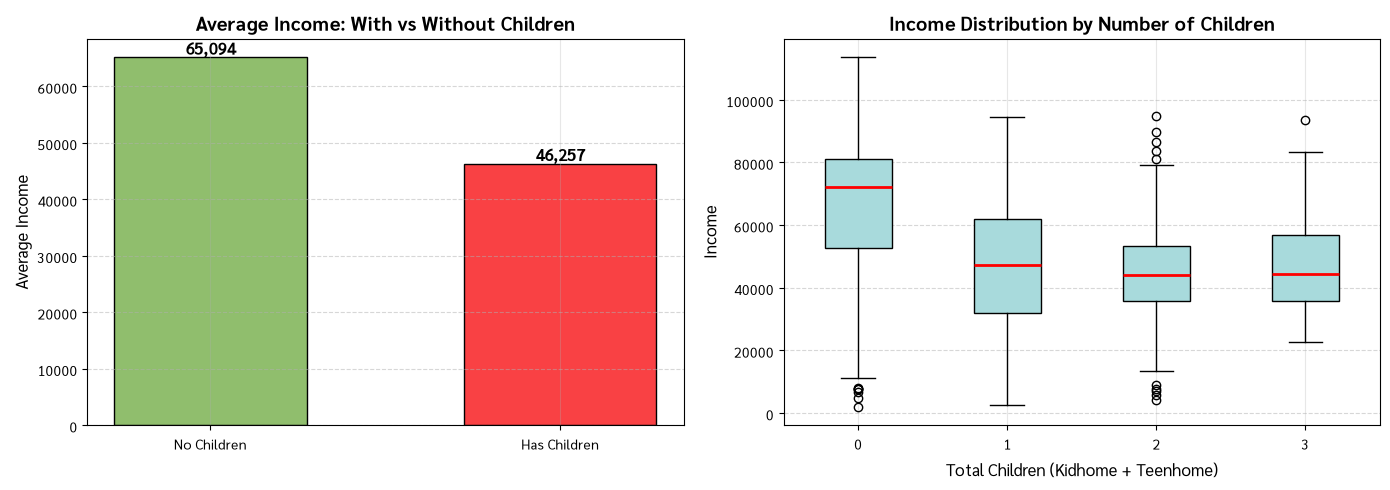


แปลผล: ลูกค้าที่มีบุตรมีรายได้เฉลี่ยต่ำกว่ากลุ่มไม่มีบุตร 18,837 (28.9%)
        และรายได้มีแนวโน้มลดลงเมื่อจำนวนบุตรเพิ่มขึ้น
        เชิงธุรกิจ: กลุ่มมีบุตรควรเน้นโปรโมชันคุ้มค่า/ส่วนลด มากกว่าสินค้าพรีเมียม


In [48]:
# =============================================================================
# Exercise 14: Customers with children — average Income
# =============================================================================
# กรองลูกค้าที่มีบุตร (Kidhome + Teenhome > 0) แล้วหารายได้เฉลี่ย

# --- สร้างคอลัมน์จำนวนบุตรรวม และคอลัมน์ระบุว่ามีบุตรหรือไม่ ---
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]
df["Has_Children"] = df["Total_Children"] > 0     # Boolean: True = มีบุตร

# --- กรองด้วย Boolean Indexing ---
with_children = df[df["Total_Children"] > 0]      # กลุ่มที่มีบุตร
without_children = df[df["Total_Children"] == 0]  # กลุ่มเปรียบเทียบ (ไม่มีบุตร)

# --- คำตอบตรงตามโจทย์ ---
avg_income_with = with_children["Income"].mean()

print("=" * 65)
print("ลูกค้าที่มีบุตร (Kidhome + Teenhome > 0)")
print("=" * 65)
print(f"จำนวนลูกค้าที่มีบุตร : {len(with_children):,} ราย "
      f"({len(with_children)/len(df)*100:.2f}% ของทั้งหมด)")
print(f"รายได้เฉลี่ย         : {avg_income_with:,.2f}")

# --- เปรียบเทียบกับกลุ่มที่ไม่มีบุตร ---
avg_income_without = without_children["Income"].mean()
diff = avg_income_with - avg_income_without

print("-" * 65)
print("เปรียบเทียบ 2 กลุ่ม:")
print(f"  มีบุตร     : n = {len(with_children):>5,}  Mean = {avg_income_with:>11,.2f}  "
      f"Median = {with_children['Income'].median():>11,.2f}")
print(f"  ไม่มีบุตร  : n = {len(without_children):>5,}  Mean = {avg_income_without:>11,.2f}  "
      f"Median = {without_children['Income'].median():>11,.2f}")
print(f"  ส่วนต่าง   : {diff:>+11,.2f} ({diff/avg_income_without*100:+.2f}%)")

# --- แยกละเอียดตามจำนวนบุตร 0, 1, 2, 3 คน ---
by_n_children = df.groupby("Total_Children")["Income"].agg(
    ["count", "mean", "median"]).round(2)
print("\nรายได้เฉลี่ยแยกตามจำนวนบุตร:")
print(by_n_children.to_string())

# --- วาดกราฟเปรียบเทียบ 2 แผง ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# แผงซ้าย: Bar Chart เทียบ 2 กลุ่ม
groups = ["No Children", "Has Children"]
means = [avg_income_without, avg_income_with]
bars = ax[0].bar(groups, means, color=["#90BE6D", "#F94144"],
                 edgecolor="black", width=0.55)
for bar, v in zip(bars, means):
    ax[0].text(bar.get_x() + bar.get_width()/2, v + 500, f"{v:,.0f}",
               ha="center", fontsize=12, fontweight="bold")
ax[0].set_title("Average Income: With vs Without Children", fontsize=14, fontweight="bold")
ax[0].set_ylabel("Average Income", fontsize=12)
ax[0].grid(axis="y", linestyle="--", alpha=0.5)

# แผงขวา: Box Plot แยกตามจำนวนบุตร — เห็นการกระจายตัวด้วย
n_levels = sorted(df["Total_Children"].unique())
ax[1].boxplot([df.loc[df["Total_Children"] == n, "Income"] for n in n_levels],
              tick_labels=[str(n) for n in n_levels], patch_artist=True,
              boxprops=dict(facecolor="#A8DADC", color="black"),
              medianprops=dict(color="red", linewidth=2))
ax[1].set_title("Income Distribution by Number of Children", fontsize=14, fontweight="bold")
ax[1].set_xlabel("Total Children (Kidhome + Teenhome)", fontsize=12)
ax[1].set_ylabel("Income", fontsize=12)
ax[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nแปลผล: ลูกค้าที่มีบุตรมีรายได้เฉลี่ยต่ำกว่ากลุ่มไม่มีบุตร {abs(diff):,.0f} "
      f"({abs(diff)/avg_income_without*100:.1f}%)")
print("        และรายได้มีแนวโน้มลดลงเมื่อจำนวนบุตรเพิ่มขึ้น")
print("        เชิงธุรกิจ: กลุ่มมีบุตรควรเน้นโปรโมชันคุ้มค่า/ส่วนลด มากกว่าสินค้าพรีเมียม")

---

## Exercise 15 — Top wine buyers

> **โจทย์:** Find the top 10 customers with the highest spending on wine `MntWines`.

**วัตถุประสงค์:** หาลูกค้า 10 อันดับแรกที่ใช้จ่ายค่าไวน์สูงสุด

### 2 วิธีหา Top-N ใน Pandas

| วิธี | Code | ข้อดี |
|------|------|-------|
| `nlargest()` | `df.nlargest(10, "MntWines")` | สั้น, เร็วกว่าเมื่อ N น้อย |
| `sort_values()` | `df.sort_values("MntWines", ascending=False).head(10)` | ยืดหยุ่น เรียงหลายคอลัมน์ได้ |

ฟังก์ชันคู่กันคือ `nsmallest()` สำหรับหาค่าน้อยสุด

### ทำไมต้องดู Top-N?

ในธุรกิจมักเป็นไปตาม **หลัก Pareto (80/20)** — ลูกค้ากลุ่มเล็กสร้างรายได้สัดส่วนใหญ่
การระบุตัวลูกค้ากลุ่มนี้ได้ นำไปใช้ทำ **VIP Program**, **Loyalty Program** หรือ **Personalized Offer** ได้ทันที

### การเลือกแสดงเฉพาะคอลัมน์ที่เกี่ยวข้อง

```python
df.nlargest(10, "MntWines")[["No", "Age", "Income", "MntWines"]]
```

เลือกคอลัมน์ด้วย list ซ้อนใน `[]` เพื่อให้ตารางผลลัพธ์อ่านง่าย ไม่แสดงทั้ง 27 คอลัมน์

Top 10 ลูกค้าที่ใช้จ่ายค่าไวน์สูงสุด
  No  Age  Income  Education  Marital  MntWines  MntMeatProducts  MntGoldProds  Response
1724   71   80360        PhD  Married      1493              454            43         0
 543   61   87771 Graduation Together      1492              287            33         1
 805   61   87771 Graduation Together      1492              287            33         1
2067   44   81929     Master  Married      1486              278           185         1
 527   38   84169        PhD  Married      1478              403             0         1
 898   38   84169        PhD  Married      1478              403             0         1
1936   58   71670        PhD    Widow      1462              128           160         1
1617   56   64140        PhD Divorced      1459               61           215         1
1464   65   76998 Graduation  Married      1449              161           107         0
 481   49   78642        PhD Together      1396              322         

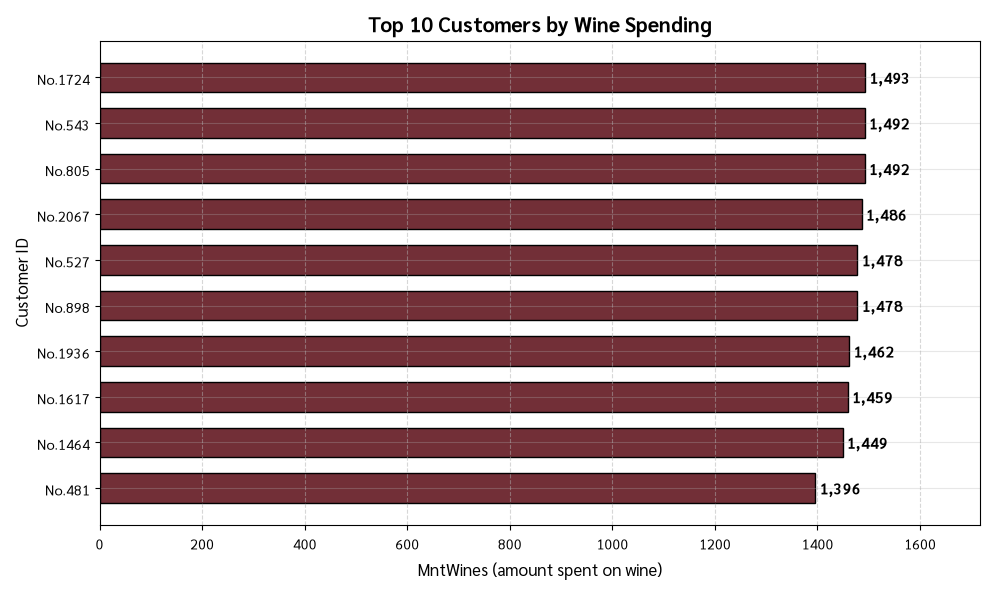


แปลผล: ลูกค้า Top 10 ใช้จ่ายไวน์เฉลี่ยสูงกว่าค่าเฉลี่ยทั้งระบบ 4.8 เท่า
        และมีรายได้เฉลี่ยสูงกว่า 1.6 เท่า
        เชิงธุรกิจ: กลุ่มนี้เหมาะกับ VIP Wine Club และข้อเสนอไวน์รุ่นพิเศษ


In [49]:
# =============================================================================
# Exercise 15: Top 10 wine buyers
# =============================================================================
# หาลูกค้า 10 อันดับแรกที่ใช้จ่ายค่าไวน์สูงสุด

col = "MntWines"
N = 10

# --- วิธีที่ 1: nlargest() — กระชับที่สุด ---
top10 = df.nlargest(N, col)

# --- วิธีที่ 2: sort_values() + head() — ได้ผลเหมือนกัน ---
top10_alt = df.sort_values(col, ascending=False).head(N)

# --- เลือกแสดงเฉพาะคอลัมน์ที่เกี่ยวข้องเพื่อให้ตารางอ่านง่าย ---
show_cols = ["No", "Age", "Income", "Education", "Marital", col,
             "MntMeatProducts", "MntGoldProds", "Response"]

print("=" * 100)
print(f"Top {N} ลูกค้าที่ใช้จ่ายค่าไวน์สูงสุด")
print("=" * 100)
print(top10[show_cols].to_string(index=False))

# --- ยืนยันว่า 2 วิธีให้ผลเหมือนกัน ---
print(f"\nตรวจสอบ: nlargest และ sort_values ให้ผลตรงกัน = "
      f"{list(top10['No']) == list(top10_alt['No'])}")

# --- เปรียบเทียบโปรไฟล์กลุ่ม Top 10 กับลูกค้าทั้งหมด ---
print("\n" + "=" * 65)
print(f"เปรียบเทียบโปรไฟล์ Top {N} กับลูกค้าทั้งหมด")
print("=" * 65)
compare_cols = ["Age", "Income", "MntWines", "MntMeatProducts",
                "NumStorePurchases", "NumWebPurchases", "Recency"]
cmp_table = pd.DataFrame({
    f"Top{N}_Mean": top10[compare_cols].mean(),
    "All_Mean": df[compare_cols].mean(),
}).round(2)
cmp_table["Ratio"] = (cmp_table[f"Top{N}_Mean"] / cmp_table["All_Mean"]).round(2)
print(cmp_table.to_string())

# --- ตรวจสอบหลัก Pareto: Top 10% สร้างยอดขายไวน์กี่ % ---
total_wine = df[col].sum()
top10_wine = top10[col].sum()
n_top10pct = int(len(df) * 0.10)
top10pct_wine = df.nlargest(n_top10pct, col)[col].sum()

print("\n" + "=" * 65)
print("การกระจุกตัวของยอดขายไวน์ (Pareto Analysis)")
print("=" * 65)
print(f"ยอดขายไวน์รวมทั้งหมด       : {total_wine:,.0f}")
print(f"Top {N} ราย สร้างยอดขาย      : {top10_wine:,.0f} ({top10_wine/total_wine*100:.2f}%)")
print(f"Top 10% ({n_top10pct:,} ราย) สร้างยอดขาย : {top10pct_wine:,.0f} "
      f"({top10pct_wine/total_wine*100:.2f}%)")

# --- วาด Bar Chart แนวนอนแสดง Top 10 ---
plt.figure(figsize=(10, 6))
labels = [f"No.{int(n)}" for n in top10["No"]]
bars = plt.barh(labels[::-1], top10[col].values[::-1],      # กลับลำดับให้อันดับ 1 อยู่บนสุด
                color="#722F37", edgecolor="black", height=0.65)
for bar, v in zip(bars, top10[col].values[::-1]):
    plt.text(v + 8, bar.get_y() + bar.get_height()/2, f"{v:,.0f}",
             va="center", fontsize=11, fontweight="bold")

plt.title(f"Top {N} Customers by Wine Spending", fontsize=15, fontweight="bold")
plt.xlabel("MntWines (amount spent on wine)", fontsize=12)
plt.ylabel("Customer ID", fontsize=12)
plt.xlim(0, top10[col].max() * 1.15)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\nแปลผล: ลูกค้า Top {N} ใช้จ่ายไวน์เฉลี่ยสูงกว่าค่าเฉลี่ยทั้งระบบ "
      f"{cmp_table.loc['MntWines', 'Ratio']:.1f} เท่า")
print(f"        และมีรายได้เฉลี่ยสูงกว่า {cmp_table.loc['Income', 'Ratio']:.1f} เท่า")
print("        เชิงธุรกิจ: กลุ่มนี้เหมาะกับ VIP Wine Club และข้อเสนอไวน์รุ่นพิเศษ")

---

## Exercise 16 — Income quantiles with qcut

> **โจทย์:** Use `pd.qcut` to divide `Income` into 4 quantiles and count customers in each group.

**วัตถุประสงค์:** แบ่งรายได้เป็น 4 ควอไทล์ด้วย `pd.qcut` แล้วนับจำนวนลูกค้าแต่ละกลุ่ม

### `pd.qcut()` — Binning แบบ "จำนวนสมาชิกเท่ากัน"

```python
pd.qcut(df["Income"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])
```

แบ่งโดยยึด **เปอร์เซ็นไทล์** เป็นขอบช่วง → แต่ละกลุ่มมีสมาชิกประมาณ **25% เท่ากัน**

### เปรียบเทียบ `cut` vs `qcut` (จุดสำคัญที่ต้องเข้าใจ)

| | `pd.cut()` | `pd.qcut()` |
|---|-----------|-------------|
| เกณฑ์แบ่ง | ความกว้างของช่วงเท่ากัน | จำนวนข้อมูลในกลุ่มเท่ากัน |
| ขอบช่วง | คำนวณจาก `min`/`max` | คำนวณจาก Percentile |
| จำนวนสมาชิก | **ไม่เท่ากัน** | **เท่ากัน ~25%** |
| เหมาะกับ | ช่วงที่มีความหมายทางธุรกิจ (เช่น ช่วงอายุ) | การทำ Segmentation ขนาดเท่ากัน |
| ปัญหาที่พบ | กลุ่มปลายอาจว่างเปล่า เมื่อข้อมูลเบ้ | ขอบช่วงอาจซ้ำกันถ้าข้อมูลกระจุกตัวมาก |

### ทำไม Marketing มักใช้ `qcut`?

เพราะได้ Segment ที่มี **ขนาดเท่ากัน** → เปรียบเทียบพฤติกรรมระหว่าง Segment ได้อย่างยุติธรรม
และจัดสรรงบประมาณต่อ Segment ได้สมดุล (ต่างจาก `cut` ที่บางกลุ่มอาจมีลูกค้าแค่หลักสิบ)

การแบ่งกลุ่มรายได้ด้วย pd.qcut() — จำนวนสมาชิกเท่ากัน
Quartile         ช่วงรายได้                        จำนวน    สัดส่วน
---------------------------------------------------------------------------
Q1 (Lowest)      (1,730 - 35,196]                    553     25.08%
Q2               (35,196 - 51,287]                   550     24.94%
Q3               (51,287 - 68,281]                   551     24.99%
Q4 (Highest)     (68,281 - 113,734]                  551     24.99%
---------------------------------------------------------------------------
Total                                              2,205    100.00%

เปรียบเทียบ pd.cut vs pd.qcut
         pd.cut (เท่าความกว้าง)  pd.qcut (เท่าจำนวน)
Group 1                     363                  553
Group 2                     941                  550
Group 3                     822                  551
Group 4                      79                  551

ส่วนเบี่ยงเบนมาตรฐานของจำนวนสมาชิก:
  pd.cut  :   401.53  (ไม่สมดุล)
  pd.qcut :     1.26

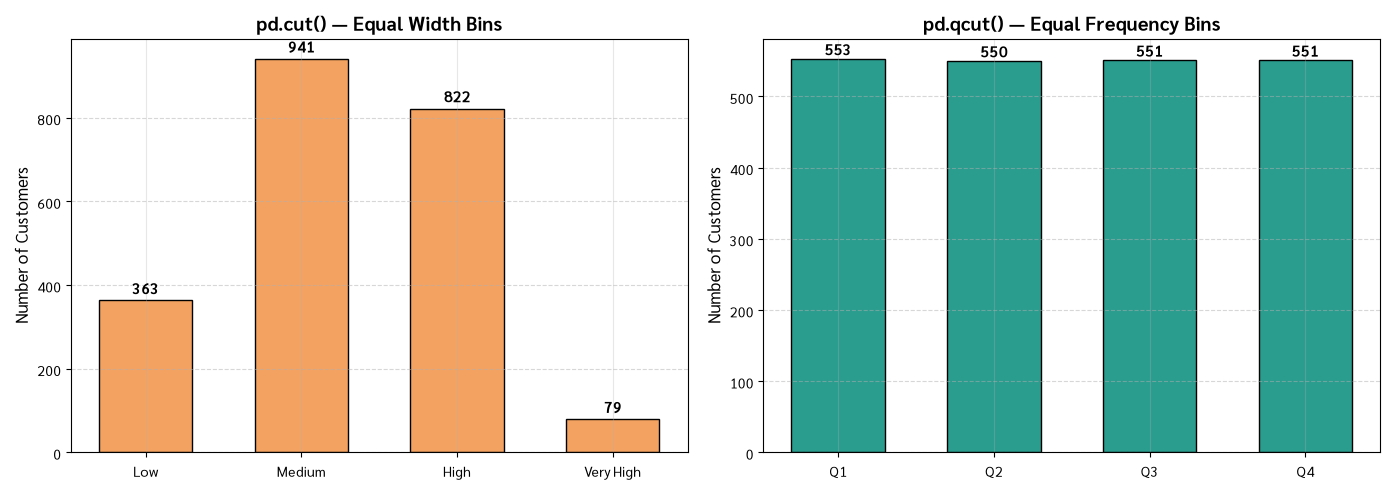


แปลผล: qcut ให้กลุ่มขนาดเท่ากันราว 25% ต่อกลุ่ม เหมาะกับการทำ Segmentation
        ขณะที่ cut ให้กลุ่มขนาดไม่เท่ากันเพราะรายได้กระจายตัวแบบเบ้


In [50]:
# =============================================================================
# Exercise 16: Income quantiles with pd.qcut()
# =============================================================================
# แบ่ง Income เป็น 4 ควอไทล์ (จำนวนสมาชิกเท่ากัน) แล้วนับจำนวนลูกค้า

# --- แบ่งด้วย pd.qcut (Equal-frequency binning) ---
q_labels = ["Q1 (Lowest)", "Q2", "Q3", "Q4 (Highest)"]
df["Income_Quartile"] = pd.qcut(df["Income"], q=4, labels=q_labels)

# --- นับจำนวนลูกค้าแต่ละควอไทล์ ---
q_count = df["Income_Quartile"].value_counts(sort=False)
q_pct = df["Income_Quartile"].value_counts(normalize=True, sort=False) * 100

# --- ดูขอบช่วงที่ qcut คำนวณให้ ---
q_edges = pd.qcut(df["Income"], q=4).cat.categories

print("=" * 75)
print("การแบ่งกลุ่มรายได้ด้วย pd.qcut() — จำนวนสมาชิกเท่ากัน")
print("=" * 75)
print(f"{'Quartile':<16} {'ช่วงรายได้':<30} {'จำนวน':>8} {'สัดส่วน':>10}")
print("-" * 75)
for name, interval in zip(q_labels, q_edges):
    rng = f"({interval.left:,.0f} - {interval.right:,.0f}]"
    print(f"{name:<16} {rng:<30} {q_count[name]:>8,} {q_pct[name]:>9.2f}%")
print("-" * 75)
print(f"{'Total':<16} {'':<30} {q_count.sum():>8,} {100.0:>9.2f}%")

# --- เปรียบเทียบกับผลของ pd.cut จาก Exercise 5 ---
cut_count = df["Income_Group"].value_counts(sort=False)

print("\n" + "=" * 75)
print("เปรียบเทียบ pd.cut vs pd.qcut")
print("=" * 75)
compare = pd.DataFrame({
    "pd.cut (เท่าความกว้าง)": cut_count.values,
    "pd.qcut (เท่าจำนวน)": q_count.values,
}, index=["Group 1", "Group 2", "Group 3", "Group 4"])
print(compare.to_string())
print(f"\nส่วนเบี่ยงเบนมาตรฐานของจำนวนสมาชิก:")
print(f"  pd.cut  : {cut_count.std():>8.2f}  (ไม่สมดุล)")
print(f"  pd.qcut : {q_count.std():>8.2f}  (สมดุลเกือบสมบูรณ์)")

# --- วาดกราฟเปรียบเทียบ 2 วิธี ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# แผงซ้าย: pd.cut
b1 = ax[0].bar(range(4), cut_count.values, color="#F4A261",
               edgecolor="black", width=0.6)
for bar, v in zip(b1, cut_count.values):
    ax[0].text(bar.get_x() + bar.get_width()/2, v + 15, f"{v:,}",
               ha="center", fontsize=11, fontweight="bold")
ax[0].set_xticks(range(4))
ax[0].set_xticklabels(["Low", "Medium", "High", "Very High"])
ax[0].set_title("pd.cut() — Equal Width Bins", fontsize=14, fontweight="bold")
ax[0].set_ylabel("Number of Customers", fontsize=12)
ax[0].grid(axis="y", linestyle="--", alpha=0.5)

# แผงขวา: pd.qcut
b2 = ax[1].bar(range(4), q_count.values, color="#2A9D8F",
               edgecolor="black", width=0.6)
for bar, v in zip(b2, q_count.values):
    ax[1].text(bar.get_x() + bar.get_width()/2, v + 5, f"{v:,}",
               ha="center", fontsize=11, fontweight="bold")
ax[1].set_xticks(range(4))
ax[1].set_xticklabels(["Q1", "Q2", "Q3", "Q4"])
ax[1].set_title("pd.qcut() — Equal Frequency Bins", fontsize=14, fontweight="bold")
ax[1].set_ylabel("Number of Customers", fontsize=12)
ax[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print("\nแปลผล: qcut ให้กลุ่มขนาดเท่ากันราว 25% ต่อกลุ่ม เหมาะกับการทำ Segmentation")
print("        ขณะที่ cut ให้กลุ่มขนาดไม่เท่ากันเพราะรายได้กระจายตัวแบบเบ้")

---

## Exercise 17 — Stacked bar chart

> **โจทย์:** Create a stacked bar chart showing the number of customers by marital status `Marital` and education `Education`.

**วัตถุประสงค์:** แสดงจำนวนลูกค้าแยกตาม 2 มิติพร้อมกันด้วย Stacked Bar Chart

### `pd.crosstab()` — สร้างตารางไขว้ (Contingency Table)

```python
ct = pd.crosstab(df["Marital"], df["Education"])
```

นับจำนวนข้อมูลในทุกการจับคู่ของ 2 ตัวแปรหมวดหมู่ — แถว = `Marital`, คอลัมน์ = `Education`

| Parameter | ผลลัพธ์ |
|-----------|---------|
| `normalize="index"` | แปลงเป็นสัดส่วนของแต่ละ **แถว** (รวมแถวได้ 100%) |
| `normalize="columns"` | สัดส่วนของแต่ละ **คอลัมน์** |
| `margins=True` | เพิ่มแถว/คอลัมน์ผลรวม (`All`) |

### Stacked Bar ทำได้ง่ายที่สุดด้วย `DataFrame.plot`

```python
ct.plot(kind="bar", stacked=True)
```

### Stacked (จำนวน) vs 100% Stacked (สัดส่วน) — ใช้ต่างกัน

| รูปแบบ | อ่านอะไรได้ | ข้อจำกัด |
|--------|-------------|----------|
| **Stacked** | ขนาดรวมของแต่ละกลุ่ม + องค์ประกอบภายใน | กลุ่มเล็กเทียบองค์ประกอบยาก |
| **100% Stacked** | **สัดส่วน**ภายในแต่ละกลุ่ม เทียบกันได้ตรง ๆ | มองไม่เห็นว่ากลุ่มไหนใหญ่กว่า |

จึงควรวาด **ทั้งสองแบบคู่กัน** เพื่อไม่ให้ตีความผิด

Crosstab: จำนวนลูกค้าแยกตาม Marital x Education
Education  2nCycle  Basic  Graduation  Master  PhD  Total
Marital                                                  
Divorced        22      1         118      37   52    230
Married         80     20         429     138  187    854
Single          35     18         248      77   99    477
Together        56     14         283     101  114    568
Widow            5      1          35      11   24     76
Total          198     54        1113     364  476   2205

สัดส่วนระดับการศึกษาภายในแต่ละสถานภาพสมรส (% ต่อแถว):
Education  2nCycle  Basic  Graduation  Master    PhD
Marital                                             
Divorced      9.57   0.43       51.30   16.09  22.61
Married       9.37   2.34       50.23   16.16  21.90
Single        7.34   3.77       51.99   16.14  20.75
Together      9.86   2.46       49.82   17.78  20.07
Widow         6.58   1.32       46.05   14.47  31.58


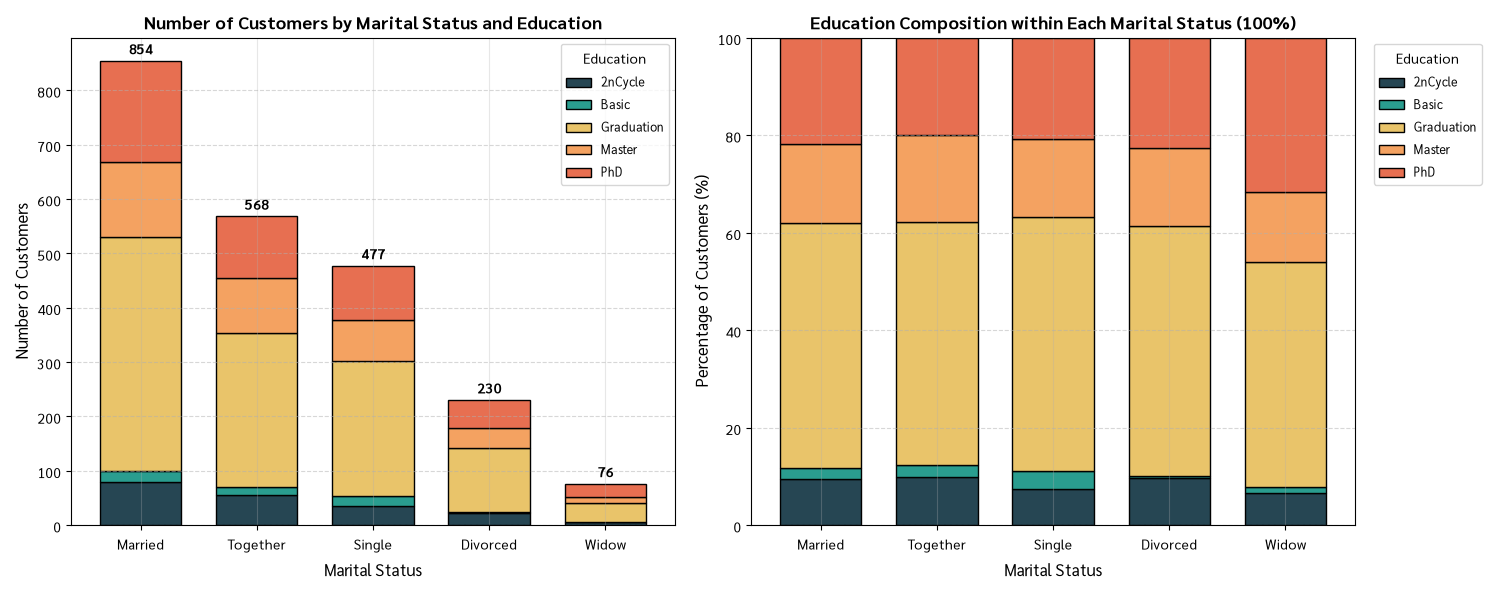


แปลผล: คู่ที่มีลูกค้ามากที่สุดคือ Married + Graduation (429 ราย)
        กลุ่มสถานภาพสมรสที่ใหญ่ที่สุด: Married (854 ราย)
        กราฟ 100% Stacked แสดงว่าทุกสถานภาพสมรสมีสัดส่วนการศึกษาใกล้เคียงกัน
        -> การศึกษาและสถานภาพสมรสค่อนข้างเป็นอิสระต่อกัน


In [51]:
# =============================================================================
# Exercise 17: Stacked bar chart — Marital x Education
# =============================================================================
# แสดงจำนวนลูกค้าแยกตามสถานภาพสมรสและระดับการศึกษา

# --- สร้างตารางไขว้: แถว = Marital, คอลัมน์ = Education ---
ct = pd.crosstab(df["Marital"], df["Education"])

# --- เรียงแถวจากกลุ่มใหญ่ไปเล็ก เพื่อให้กราฟอ่านง่าย ---
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

print("=" * 80)
print("Crosstab: จำนวนลูกค้าแยกตาม Marital x Education")
print("=" * 80)
print(pd.crosstab(df["Marital"], df["Education"], margins=True,
                  margins_name="Total").to_string())

# --- ตารางสัดส่วนภายในแต่ละสถานภาพสมรส (รวมแถวได้ 100%) ---
ct_pct = pd.crosstab(df["Marital"], df["Education"], normalize="index") * 100
print("\nสัดส่วนระดับการศึกษาภายในแต่ละสถานภาพสมรส (% ต่อแถว):")
print(ct_pct.round(2).to_string())

# --- วาด Stacked Bar 2 แบบเทียบกัน ---
colors = ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# แผงซ้าย: Stacked Bar แบบจำนวนจริง
ct.plot(kind="bar", stacked=True, ax=ax[0], color=colors,
        edgecolor="black", width=0.7)
ax[0].set_title("Number of Customers by Marital Status and Education",
                fontsize=13, fontweight="bold")
ax[0].set_xlabel("Marital Status", fontsize=12)
ax[0].set_ylabel("Number of Customers", fontsize=12)
ax[0].legend(title="Education", fontsize=9, title_fontsize=10)
ax[0].tick_params(axis="x", rotation=0)
ax[0].grid(axis="y", linestyle="--", alpha=0.5)

# เขียนผลรวมกำกับบนยอดแท่งแต่ละกลุ่ม
for i, total in enumerate(ct.sum(axis=1)):
    ax[0].text(i, total + 12, f"{total:,}", ha="center",
               fontsize=10, fontweight="bold")

# แผงขวา: 100% Stacked Bar — เทียบสัดส่วนภายในกลุ่มได้ตรง ๆ
ct_pct_sorted = ct_pct.loc[ct.index]
ct_pct_sorted.plot(kind="bar", stacked=True, ax=ax[1], color=colors,
                   edgecolor="black", width=0.7)
ax[1].set_title("Education Composition within Each Marital Status (100%)",
                fontsize=13, fontweight="bold")
ax[1].set_xlabel("Marital Status", fontsize=12)
ax[1].set_ylabel("Percentage of Customers (%)", fontsize=12)
ax[1].set_ylim(0, 100)
ax[1].legend(title="Education", fontsize=9, title_fontsize=10,
             bbox_to_anchor=(1.02, 1), loc="upper left")
ax[1].tick_params(axis="x", rotation=0)
ax[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# --- หาคู่ Marital x Education ที่มีลูกค้ามากที่สุด ---
stacked = ct.stack()
top_pair = stacked.idxmax()
print(f"\nแปลผล: คู่ที่มีลูกค้ามากที่สุดคือ {top_pair[0]} + {top_pair[1]} "
      f"({stacked.max():,} ราย)")
print(f"        กลุ่มสถานภาพสมรสที่ใหญ่ที่สุด: {ct.sum(axis=1).idxmax()} "
      f"({ct.sum(axis=1).max():,} ราย)")
print("        กราฟ 100% Stacked แสดงว่าทุกสถานภาพสมรสมีสัดส่วนการศึกษาใกล้เคียงกัน")
print("        -> การศึกษาและสถานภาพสมรสค่อนข้างเป็นอิสระต่อกัน")

---

## Exercise 18 — Online purchase analysis

> **โจทย์:** Calculate the average `NumWebPurchases` and `NumWebVisitsMonth` grouped by marital status `Marital`.

**วัตถุประสงค์:** เปรียบเทียบพฤติกรรมออนไลน์ (ซื้อ vs เข้าชม) แยกตามสถานภาพสมรส

### GroupBy หลายคอลัมน์พร้อมกัน

```python
df.groupby("Marital")[["NumWebPurchases", "NumWebVisitsMonth"]].mean()
```

ส่ง **list ของคอลัมน์** ใน `[[...]]` จะได้ผลลัพธ์เป็น **DataFrame** ที่แต่ละคอลัมน์คือค่าเฉลี่ยของตัวแปรนั้น

### `.agg()` พร้อมระบุฟังก์ชันต่อคอลัมน์ (Dictionary form)

```python
df.groupby("Marital").agg({
    "NumWebPurchases":   ["mean", "median"],
    "NumWebVisitsMonth": ["mean", "std"],
})
```

ทำให้คำนวณสถิติ **ต่างกันในแต่ละคอลัมน์** ได้ในคำสั่งเดียว

### Metric ที่ควรสร้างเพิ่ม: Conversion Rate

ตัวเลขดิบ 2 ตัวยังไม่บอก "ประสิทธิภาพ" — ควรคำนวณอัตราแปลงเป็นยอดซื้อ

```
Web Conversion Rate = NumWebPurchases / NumWebVisitsMonth
```

ค่าสูง = เข้าเว็บแล้ว **ซื้อจริง** บ่อย · ค่าต่ำ = เข้าดูเยอะแต่ไม่ซื้อ (Browsing behavior)

ค่าเฉลี่ยพฤติกรรมออนไลน์ แยกตาม Marital
          NumWebPurchases  NumWebVisitsMonth
Marital                                     
Divorced            4.339              5.513
Married             4.100              5.375
Single              3.876              5.285
Together            4.125              5.306
Widow               4.618              4.934

ตารางสรุปแบบละเอียด:
         NumWebPurchases                      NumWebVisitsMonth              
                   count   mean median    std              mean median    std
Marital                                                                      
Divorced             230  4.339    4.0  2.910             5.513    6.0  2.444
Married              854  4.100    4.0  2.676             5.375    6.0  2.306
Single               477  3.876    3.0  2.777             5.285    6.0  2.571
Together             568  4.125    4.0  2.711             5.306    6.0  2.436
Widow                 76  4.618    4.0  2.766             4.934    5.0  2.311

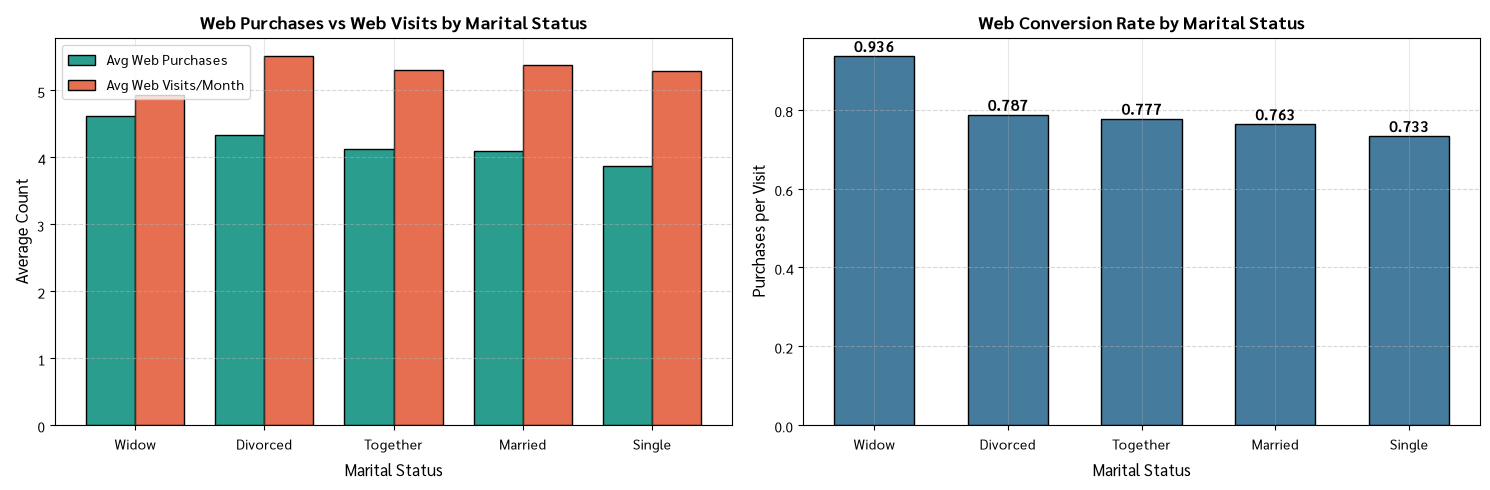


แปลผล: Widow มี Conversion Rate สูงสุด (0.936 ครั้งซื้อต่อการเข้าชม)
        Single ต่ำสุด (0.733) — เข้าเว็บบ่อยแต่ซื้อน้อย
        เชิงธุรกิจ: กลุ่ม Conversion ต่ำควรใช้ Retargeting / Cart Reminder


In [52]:
# =============================================================================
# Exercise 18: Online purchase analysis by Marital status
# =============================================================================
# เปรียบเทียบจำนวนการซื้อออนไลน์และการเข้าชมเว็บไซต์ แยกตามสถานภาพสมรส

cols = ["NumWebPurchases", "NumWebVisitsMonth"]

# --- คำตอบตรงตามโจทย์: ค่าเฉลี่ยของ 2 คอลัมน์ แยกตาม Marital ---
avg_online = df.groupby("Marital")[cols].mean().round(3)

print("=" * 70)
print("ค่าเฉลี่ยพฤติกรรมออนไลน์ แยกตาม Marital")
print("=" * 70)
print(avg_online.to_string())

# --- ขยายผล: ใช้ .agg() แบบ dictionary เพื่อดูหลายสถิติ ---
detail = df.groupby("Marital").agg({
    "NumWebPurchases": ["count", "mean", "median", "std"],
    "NumWebVisitsMonth": ["mean", "median", "std"],
}).round(3)

print("\nตารางสรุปแบบละเอียด:")
print(detail.to_string())

# --- สร้าง Metric เพิ่ม: Web Conversion Rate ---
avg_online["Conversion_Rate"] = (avg_online["NumWebPurchases"]
                                 / avg_online["NumWebVisitsMonth"]).round(3)
avg_online = avg_online.sort_values("Conversion_Rate", ascending=False)

print("\n" + "=" * 70)
print("Web Conversion Rate = NumWebPurchases / NumWebVisitsMonth")
print("=" * 70)
print(avg_online.to_string())

# --- วาดกราฟ 2 แผง ---
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# แผงซ้าย: Grouped Bar เทียบ Purchases กับ Visits
order = avg_online.index
x = np.arange(len(order))
width = 0.38
ax[0].bar(x - width/2, avg_online["NumWebPurchases"], width,
          label="Avg Web Purchases", color="#2A9D8F", edgecolor="black")
ax[0].bar(x + width/2, avg_online["NumWebVisitsMonth"], width,
          label="Avg Web Visits/Month", color="#E76F51", edgecolor="black")
ax[0].set_xticks(x)
ax[0].set_xticklabels(order, rotation=0)
ax[0].set_title("Web Purchases vs Web Visits by Marital Status",
                fontsize=13, fontweight="bold")
ax[0].set_xlabel("Marital Status", fontsize=12)
ax[0].set_ylabel("Average Count", fontsize=12)
ax[0].legend()
ax[0].grid(axis="y", linestyle="--", alpha=0.5)

# แผงขวา: Conversion Rate เรียงมาก -> น้อย
bars = ax[1].bar(order, avg_online["Conversion_Rate"],
                 color="#457B9D", edgecolor="black", width=0.6)
for bar, v in zip(bars, avg_online["Conversion_Rate"]):
    ax[1].text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.3f}",
               ha="center", fontsize=11, fontweight="bold")
ax[1].set_title("Web Conversion Rate by Marital Status", fontsize=13, fontweight="bold")
ax[1].set_xlabel("Marital Status", fontsize=12)
ax[1].set_ylabel("Purchases per Visit", fontsize=12)
ax[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

best, worst = avg_online.index[0], avg_online.index[-1]
print(f"\nแปลผล: {best} มี Conversion Rate สูงสุด "
      f"({avg_online.loc[best, 'Conversion_Rate']:.3f} ครั้งซื้อต่อการเข้าชม)")
print(f"        {worst} ต่ำสุด ({avg_online.loc[worst, 'Conversion_Rate']:.3f}) "
      f"— เข้าเว็บบ่อยแต่ซื้อน้อย")
print("        เชิงธุรกิจ: กลุ่ม Conversion ต่ำควรใช้ Retargeting / Cart Reminder")

---

## Exercise 19 — Multiple campaign responses

> **โจทย์:** Create a new column summing `AcceptedCmp1–5` and identify customers who accepted at least 2 campaigns.

**วัตถุประสงค์:** สร้างคอลัมน์ใหม่รวมจำนวนแคมเปญที่ตอบรับ แล้วหาลูกค้าที่ตอบรับตั้งแต่ 2 แคมเปญขึ้นไป

### การรวมค่าหลายคอลัมน์ด้วย `.sum(axis=1)`

```python
cmp_cols = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"]
df["Total_Accepted"] = df[cmp_cols].sum(axis=1)
```

### `axis` — พารามิเตอร์ที่สับสนที่สุดใน Pandas

| `axis` | ทิศทาง | ผลลัพธ์ |
|--------|--------|---------|
| `axis=0` (ค่าเริ่มต้น) | ไล่**ลงตามแถว** | ผลรวม**ของแต่ละคอลัมน์** |
| `axis=1` | ไล่**ข้ามคอลัมน์** | ผลรวม**ของแต่ละแถว** ← ที่ต้องการในข้อนี้ |

จำง่าย ๆ ว่า `axis=1` = "ทำงานข้ามคอลัมน์ ได้ผลลัพธ์ 1 ค่าต่อ 1 แถว"

### ทำไมต้องหาคนที่ตอบรับหลายแคมเปญ?

ลูกค้าที่ตอบรับ **≥ 2 แคมเปญ** คือกลุ่มที่พิสูจน์แล้วว่า **ตอบสนองต่อการตลาด** (Marketing-responsive)
กลุ่มนี้มีมูลค่าสูงเป็นพิเศษเพราะ

1. **ต้นทุนการตลาดต่อยอดขายต่ำกว่า** — ไม่ต้องโน้มน้าวมาก
2. ใช้เป็น **Training data** ของโมเดลทำนายการตอบรับแคมเปญถัดไปได้
3. เหมาะทำ **Lookalike targeting** — หาลูกค้าใหม่ที่มีโปรไฟล์คล้ายกลุ่มนี้

การกระจายตัวของจำนวนแคมเปญที่ลูกค้าตอบรับ
จำนวนแคมเปญที่ตอบรับ      จำนวนลูกค้า    สัดส่วน
----------------------------------------------------------------------
         0 แคมเปญ                  1,747     79.23%
         1 แคมเปญ                    322     14.60%
         2 แคมเปญ                     81      3.67%
         3 แคมเปญ                     44      2.00%
         4 แคมเปญ                     11      0.50%
----------------------------------------------------------------------
Total                           2,205    100.00%

ลูกค้าที่ตอบรับตั้งแต่ 2 แคมเปญขึ้นไป (Multi-campaign Responders)
จำนวน : 136 ราย (6.17% ของลูกค้าทั้งหมด)

ตัวอย่าง 10 รายแรก (เรียงตามจำนวนแคมเปญที่ตอบรับ):
  No  Age  Income  Education  Marital  Total_Accepted  MntWines  Response
 239   46  102692 Graduation Divorced               4       168         1
 401   26   80134 Graduation Together               4       966         0
 414   59   84865        PhD   Single               4      1248         1
 5

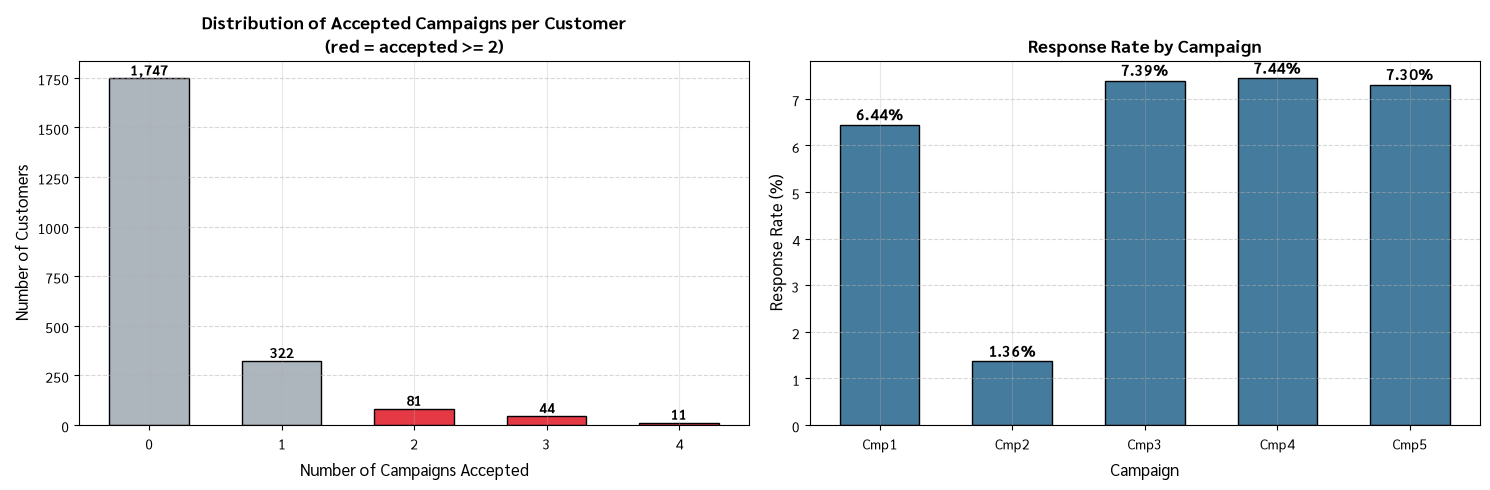


แปลผล: มีลูกค้าเพียง 6.2% ที่ตอบรับตั้งแต่ 2 แคมเปญ
        แต่กลุ่มนี้มีรายได้เฉลี่ยสูงกว่ากลุ่มอื่น 1.58 เท่า
        และใช้จ่ายค่าไวน์สูงกว่า 3.23 เท่า
        เชิงธุรกิจ: ใช้กลุ่มนี้เป็นฐานทำ Lookalike Targeting หาลูกค้าใหม่


In [53]:
# =============================================================================
# Exercise 19: Multiple campaign responses
# =============================================================================
# สร้างคอลัมน์รวมจำนวนแคมเปญที่ตอบรับ และหาลูกค้าที่ตอบรับ >= 2 แคมเปญ

# --- รายชื่อคอลัมน์แคมเปญทั้ง 5 ---
cmp_cols = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
            "AcceptedCmp4", "AcceptedCmp5"]

# --- สร้างคอลัมน์ใหม่: ผลรวมแนวแถว (axis=1) ---
df["Total_Accepted"] = df[cmp_cols].sum(axis=1)

# --- นับการกระจายตัวของจำนวนแคมเปญที่ตอบรับ ---
dist = df["Total_Accepted"].value_counts().sort_index()

print("=" * 70)
print("การกระจายตัวของจำนวนแคมเปญที่ลูกค้าตอบรับ")
print("=" * 70)
print(f"{'จำนวนแคมเปญที่ตอบรับ':<24} {'จำนวนลูกค้า':>12} {'สัดส่วน':>10}")
print("-" * 70)
for n, cnt in dist.items():
    print(f"{n:>10} แคมเปญ{'':<10} {cnt:>12,} {cnt/len(df)*100:>9.2f}%")
print("-" * 70)
print(f"{'Total':<24} {dist.sum():>12,} {100.0:>9.2f}%")

# --- กรองลูกค้าที่ตอบรับตั้งแต่ 2 แคมเปญขึ้นไป (คำตอบของโจทย์) ---
multi_responders = df[df["Total_Accepted"] >= 2]

print("\n" + "=" * 70)
print("ลูกค้าที่ตอบรับตั้งแต่ 2 แคมเปญขึ้นไป (Multi-campaign Responders)")
print("=" * 70)
print(f"จำนวน : {len(multi_responders):,} ราย "
      f"({len(multi_responders)/len(df)*100:.2f}% ของลูกค้าทั้งหมด)")

show_cols = ["No", "Age", "Income", "Education", "Marital",
             "Total_Accepted", "MntWines", "Response"]
print("\nตัวอย่าง 10 รายแรก (เรียงตามจำนวนแคมเปญที่ตอบรับ):")
print(multi_responders.nlargest(10, "Total_Accepted")[show_cols].to_string(index=False))

# --- Response Rate ของแต่ละแคมเปญ ---
print("\n" + "=" * 70)
print("Response Rate แยกตามแคมเปญ")
print("=" * 70)
for c in cmp_cols:
    rate = df[c].mean() * 100
    bar = "#" * int(rate * 2)      # แท่งกราฟแบบข้อความ
    print(f"  {c:<14} : {df[c].sum():>4,} ราย ({rate:>5.2f}%) {bar}")

# --- เปรียบเทียบโปรไฟล์ Multi-responder กับลูกค้าทั่วไป ---
others = df[df["Total_Accepted"] < 2]
profile_cols = ["Age", "Income", "MntWines", "MntMeatProducts",
                "NumWebPurchases", "NumCatalogPurchases", "Recency"]
profile = pd.DataFrame({
    "Multi_Responder (>=2)": multi_responders[profile_cols].mean(),
    "Others (<2)": others[profile_cols].mean(),
}).round(2)
profile["Ratio"] = (profile["Multi_Responder (>=2)"] / profile["Others (<2)"]).round(2)

print("\n" + "=" * 70)
print("เปรียบเทียบโปรไฟล์: ผู้ตอบรับหลายแคมเปญ vs ลูกค้าอื่น")
print("=" * 70)
print(profile.to_string())

# --- วาดกราฟ 2 แผง ---
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# แผงซ้าย: การกระจายตัวจำนวนแคมเปญที่ตอบรับ — ไล่สีเน้นกลุ่ม >= 2
bar_colors = ["#ADB5BD" if n < 2 else "#E63946" for n in dist.index]
bars = ax[0].bar(dist.index.astype(str), dist.values,
                 color=bar_colors, edgecolor="black", width=0.6)
for bar, v in zip(bars, dist.values):
    ax[0].text(bar.get_x() + bar.get_width()/2, v + 15, f"{v:,}",
               ha="center", fontsize=10, fontweight="bold")
ax[0].set_title("Distribution of Accepted Campaigns per Customer\n(red = accepted >= 2)",
                fontsize=13, fontweight="bold")
ax[0].set_xlabel("Number of Campaigns Accepted", fontsize=12)
ax[0].set_ylabel("Number of Customers", fontsize=12)
ax[0].grid(axis="y", linestyle="--", alpha=0.5)

# แผงขวา: Response Rate รายแคมเปญ
rates = [df[c].mean() * 100 for c in cmp_cols]
bars2 = ax[1].bar([c.replace("AcceptedCmp", "Cmp") for c in cmp_cols], rates,
                  color="#457B9D", edgecolor="black", width=0.6)
for bar, v in zip(bars2, rates):
    ax[1].text(bar.get_x() + bar.get_width()/2, v + 0.1, f"{v:.2f}%",
               ha="center", fontsize=11, fontweight="bold")
ax[1].set_title("Response Rate by Campaign", fontsize=13, fontweight="bold")
ax[1].set_xlabel("Campaign", fontsize=12)
ax[1].set_ylabel("Response Rate (%)", fontsize=12)
ax[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nแปลผล: มีลูกค้าเพียง {len(multi_responders)/len(df)*100:.1f}% "
      f"ที่ตอบรับตั้งแต่ 2 แคมเปญ")
print(f"        แต่กลุ่มนี้มีรายได้เฉลี่ยสูงกว่ากลุ่มอื่น "
      f"{profile.loc['Income', 'Ratio']:.2f} เท่า")
print(f"        และใช้จ่ายค่าไวน์สูงกว่า {profile.loc['MntWines', 'Ratio']:.2f} เท่า")
print("        เชิงธุรกิจ: ใช้กลุ่มนี้เป็นฐานทำ Lookalike Targeting หาลูกค้าใหม่")

---

## Exercise 20 — Heatmap of correlations

> **โจทย์:** Create a heatmap of the correlation matrix for product spending variables `MntWines`, `MntMeatProducts`, `MntSweetProducts`, `MntGoldProds`.

**วัตถุประสงค์:** แสดง Correlation Matrix ของ 4 หมวดสินค้าเป็น Heatmap

### Correlation Matrix

ตาราง n × n ที่ช่อง (i, j) คือค่า r ระหว่างตัวแปร i กับ j

- **แนวทแยงเป็น 1.0 เสมอ** (ตัวแปรสัมพันธ์กับตัวเองสมบูรณ์)
- **สมมาตรรอบแนวทแยง** — `corr(A,B) = corr(B,A)` จึงมีข้อมูลซ้ำครึ่งหนึ่ง

### `sns.heatmap()` — Parameter สำคัญ

| Parameter | ความหมาย |
|-----------|----------|
| `annot=True` | เขียนตัวเลขในแต่ละช่อง |
| `fmt=".2f"` | รูปแบบตัวเลข (ทศนิยม 2 ตำแหน่ง) |
| `cmap` | ชุดสี — ใช้ **Diverging** เช่น `"coolwarm"` เมื่อค่ามีทั้งบวกและลบ |
| `vmin` / `vmax` | ตรึงขอบเขตสี — ควรตั้ง `-1, 1` เพื่อให้สีมีความหมายคงที่ |
| `center=0` | ให้สีกลาง (ขาว) อยู่ที่ 0 |
| `mask` | ซ่อนบางช่อง — ใช้ซ่อนครึ่งบนที่ซ้ำซ้อน |

### เทคนิคซ่อนครึ่งบนด้วย `np.triu`

```python
mask = np.triu(np.ones_like(corr, dtype=bool))
```

`np.triu` (triangle-upper) สร้าง mask ของสามเหลี่ยมบน ทำให้เหลือแสดงเฉพาะครึ่งล่าง อ่านง่ายขึ้นมาก

> **เลือก cmap ให้ถูกประเภท:** Diverging (`coolwarm`, `RdBu`) สำหรับค่าที่มีจุดกลางมีความหมาย · Sequential (`Blues`, `viridis`) สำหรับค่าที่ไล่ทางเดียว

Correlation Matrix ของยอดใช้จ่าย 4 หมวดสินค้า
                  MntWines  MntMeatProducts  MntSweetProducts  MntGoldProds
MntWines            1.0000           0.5931            0.3886        0.3902
MntMeatProducts     0.5931           1.0000            0.5565        0.3756
MntSweetProducts    0.3886           0.5565            1.0000        0.3557
MntGoldProds        0.3902           0.3756            0.3557        1.0000


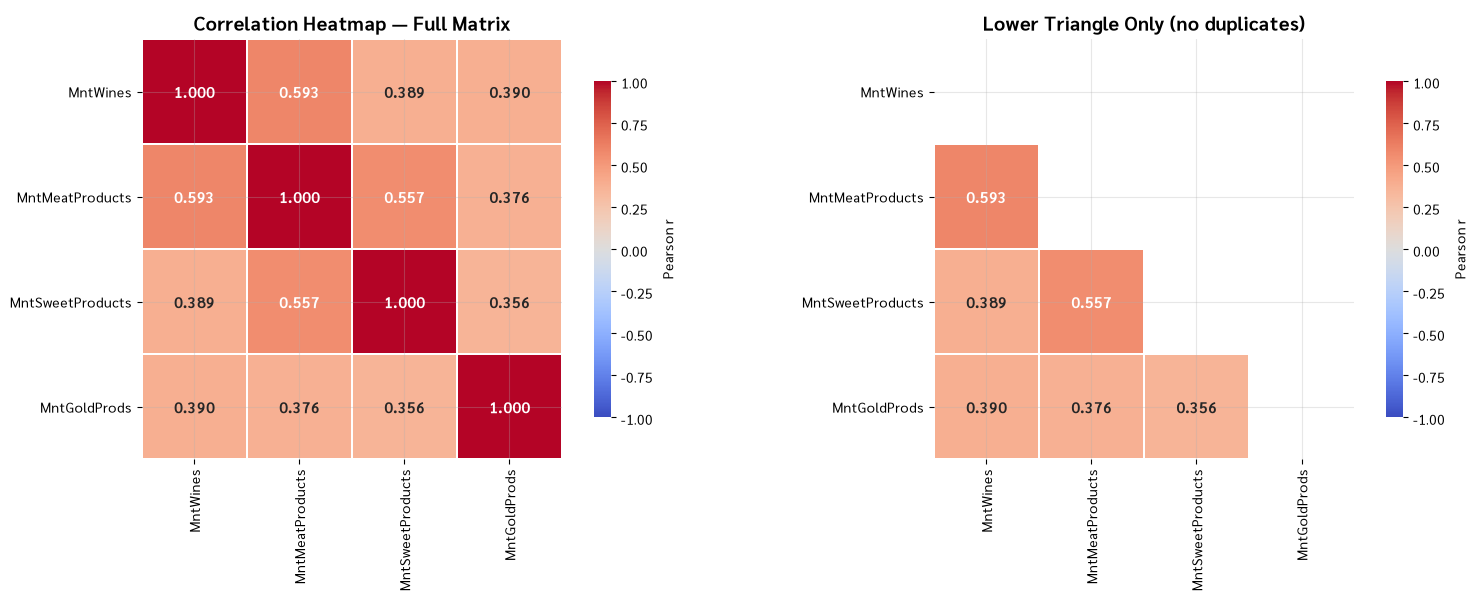

อันดับความสัมพันธ์รายคู่ (เรียงจากแรงไปอ่อน)
  1. MntWines           <-> MntMeatProducts    r =  0.593  (ปานกลาง)
  2. MntMeatProducts    <-> MntSweetProducts   r =  0.557  (ปานกลาง)
  3. MntWines           <-> MntGoldProds       r =  0.390  (อ่อน)
  4. MntWines           <-> MntSweetProducts   r =  0.389  (อ่อน)
  5. MntMeatProducts    <-> MntGoldProds       r =  0.376  (อ่อน)
  6. MntSweetProducts   <-> MntGoldProds       r =  0.356  (อ่อน)

แปลผล: คู่ที่สัมพันธ์กันแรงที่สุดคือ MntWines กับ MntMeatProducts (r = 0.593)
        หมายความว่าลูกค้าที่ซื้อสินค้าหมวดหนึ่งมากมักซื้ออีกหมวดมากด้วย
        เชิงธุรกิจ: เป็นโอกาส Cross-selling — จัด Bundle สินค้าคู่ที่ r สูง


In [54]:
# =============================================================================
# Exercise 20: Heatmap of correlation matrix (product spending)
# =============================================================================
# สร้าง Heatmap ของ Correlation Matrix สำหรับยอดใช้จ่าย 4 หมวดสินค้า

prod_cols = ["MntWines", "MntMeatProducts", "MntSweetProducts", "MntGoldProds"]

# --- คำนวณ Correlation Matrix ---
corr = df[prod_cols].corr()

print("=" * 80)
print("Correlation Matrix ของยอดใช้จ่าย 4 หมวดสินค้า")
print("=" * 80)
print(corr.round(4).to_string())

# --- วาด Heatmap 2 แบบเทียบกัน ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# แผงซ้าย: Heatmap เต็มรูป
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0,            # ตรึงขอบเขตสีให้มีความหมายคงที่
            square=True, linewidths=1.2, linecolor="white",
            cbar_kws={"label": "Pearson r", "shrink": 0.8},
            annot_kws={"fontsize": 11, "fontweight": "bold"},
            ax=ax[0])
ax[0].set_title("Correlation Heatmap — Full Matrix", fontsize=14, fontweight="bold")

# แผงขวา: ซ่อนครึ่งบนที่ซ้ำซ้อนด้วย np.triu
mask = np.triu(np.ones_like(corr, dtype=bool))    # True = ช่องที่จะซ่อน
sns.heatmap(corr, mask=mask, annot=True, fmt=".3f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0,
            square=True, linewidths=1.2, linecolor="white",
            cbar_kws={"label": "Pearson r", "shrink": 0.8},
            annot_kws={"fontsize": 11, "fontweight": "bold"},
            ax=ax[1])
ax[1].set_title("Lower Triangle Only (no duplicates)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

# --- จัดอันดับความสัมพันธ์รายคู่ ---
pairs = []
for i in range(len(prod_cols)):
    for j in range(i + 1, len(prod_cols)):
        pairs.append((prod_cols[i], prod_cols[j], corr.iloc[i, j]))
pairs.sort(key=lambda t: abs(t[2]), reverse=True)

print("=" * 80)
print("อันดับความสัมพันธ์รายคู่ (เรียงจากแรงไปอ่อน)")
print("=" * 80)
for rank, (a, b, r) in enumerate(pairs, start=1):
    if abs(r) >= 0.6:
        lvl = "แรง"
    elif abs(r) >= 0.4:
        lvl = "ปานกลาง"
    elif abs(r) >= 0.2:
        lvl = "อ่อน"
    else:
        lvl = "อ่อนมาก"
    print(f"  {rank}. {a:<18} <-> {b:<18} r = {r:>6.3f}  ({lvl})")

print(f"\nแปลผล: คู่ที่สัมพันธ์กันแรงที่สุดคือ {pairs[0][0]} กับ {pairs[0][1]} "
      f"(r = {pairs[0][2]:.3f})")
print("        หมายความว่าลูกค้าที่ซื้อสินค้าหมวดหนึ่งมากมักซื้ออีกหมวดมากด้วย")
print("        เชิงธุรกิจ: เป็นโอกาส Cross-selling — จัด Bundle สินค้าคู่ที่ r สูง")

---

# ส่วนที่ 2 — Insight Analysis (Exercise 21–30)

Exercise 1–20 เน้นการ**คำนวณ**และ**วาดกราฟ** แต่ Exercise 21–30 เน้นการ**ตีความเชิงธุรกิจ**

| สิ่งที่ต่างกัน | Exercise 1–20 | Exercise 21–30 |
|----------------|---------------|----------------|
| คำถาม | "คำนวณค่า X" | "ค่า X บอกอะไรกับธุรกิจ" |
| ผลลัพธ์ | ตัวเลข / กราฟ | **Insight + ข้อเสนอแนะ** |
| เกณฑ์ตัดสิน | ถูก/ผิด | เหตุผลสนับสนุนหนักแน่นพอหรือไม่ |

## กรอบการวิเคราะห์ที่ใช้ในส่วนนี้

ทุกข้อจะเดินตาม 4 ขั้นเสมอ

1. **Compute** — คำนวณตัวเลขที่เกี่ยวข้อง (ค่ากลาง, สัดส่วน, correlation)
2. **Visualize** — วาดกราฟให้เห็นรูปแบบ
3. **Interpret** — ตีความว่าตัวเลขบอกอะไร พร้อมระบุข้อจำกัด
4. **Recommend** — เสนอแนวทางปฏิบัติทางธุรกิจที่ทำได้จริง

> **ข้อควรระวังตลอดส่วนนี้:** ข้อมูลชุดนี้เป็น **Observational data** ไม่ใช่การทดลองแบบสุ่ม (RCT)
> จึงสรุปได้เพียง **ความสัมพันธ์ (Association)** ไม่ใช่ **ความเป็นเหตุเป็นผล (Causation)**

---

## Exercise 21 — Income vs Wine Spending

> **โจทย์:** Analyze whether higher `Income` is associated with higher spending on wine `MntWines`. What insight can be drawn about premium product targeting?

**วัตถุประสงค์:** วิเคราะห์ว่ารายได้สูงสัมพันธ์กับการใช้จ่ายไวน์สูงจริงหรือไม่ และนำไปใช้กับการทำตลาดสินค้าพรีเมียมอย่างไร

### วิธีวิเคราะห์ที่ใช้ — ดู 3 มุมประกอบกัน

| มุมมอง | เครื่องมือ | ตอบคำถามว่า |
|--------|-----------|-------------|
| **ความแรงโดยรวม** | Pearson r | สัมพันธ์กันแรงแค่ไหนในภาพรวม |
| **รูปแบบความสัมพันธ์** | แบ่งกลุ่มรายได้ (qcut) + ค่าเฉลี่ยต่อกลุ่ม | เป็นเส้นตรง หรือเร่งตัวในช่วงปลาย |
| **ความเข้มข้นของยอดขาย** | สัดส่วนยอดขายไวน์ที่มาจากแต่ละกลุ่ม | ควรลงงบการตลาดที่กลุ่มไหน |

### ทำไมต้องดูแบบแบ่งกลุ่ม ไม่ใช่แค่ค่า r?

ค่า r เดียวสมมติว่าความสัมพันธ์เป็น **เส้นตรงสม่ำเสมอทั้งช่วง** แต่ในความจริงพฤติกรรมมักไม่เป็นเส้นตรง เช่น

- รายได้ช่วงต้นเพิ่มขึ้นแต่ยอดไวน์แทบไม่ขยับ (ยังต้องใช้จ่ายของจำเป็น)
- รายได้เกินจุดหนึ่งแล้วยอดไวน์พุ่งเร็ว (มีเงินเหลือใช้จ่ายสินค้าฟุ่มเฟือย)

การแบ่งกลุ่มจึงเผย **จุดเปลี่ยน (Threshold)** ที่นำไปกำหนดเกณฑ์คัดลูกค้าเป้าหมายได้ตรงกว่า

ขั้นที่ 1: ความสัมพันธ์โดยรวมระหว่าง Income และ MntWines
Pearson  r = 0.7305  (p = 0.000e+00)  <- วัดความสัมพันธ์เชิงเส้น
Spearman r = 0.8439  (p = 0.000e+00)  <- วัดความสัมพันธ์เชิงอันดับ
R-squared  = 0.5336  -> Income อธิบายความผันแปรของยอดไวน์ได้ 53.4%

หมายเหตุ: Spearman > Pearson แสดงว่าความสัมพันธ์เป็นแบบเพิ่มขึ้นเรื่อย ๆ
          แต่ไม่ใช่เส้นตรงสมบูรณ์ (Monotonic but non-linear)

ขั้นที่ 2: ยอดใช้จ่ายไวน์แยกตาม Income Quintile
                   n  avg_income  avg_wine  median_wine  total_wine  wine_share_%  wine_per_1k_income
Income_Quintile                                                                                      
Q1 (ต่ำสุด)      441    22995.98     16.34          8.0        7205          1.07                0.71
Q2               441    38192.68     71.91         36.0       31713          4.70                1.88
Q3               441    51378.32    267.44        198.0      117941         17.47                5.21
Q4               441    65055.81    511.42        

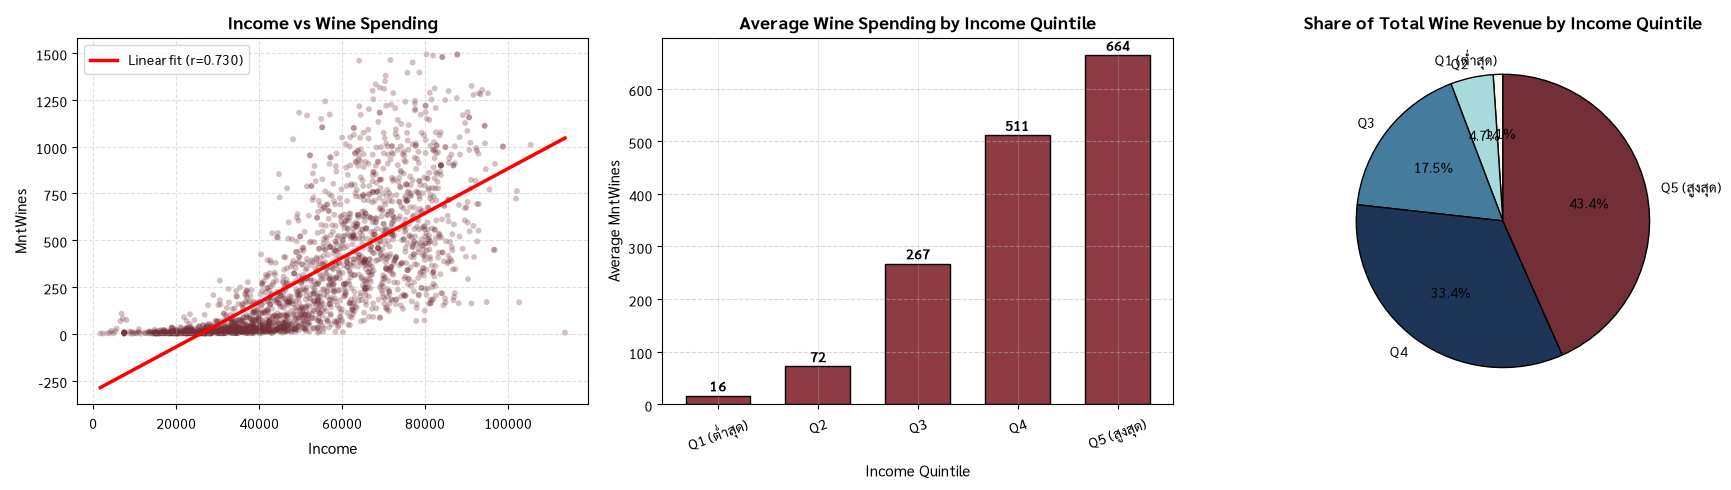

INSIGHT: Premium Product Targeting
1. รายได้สูงสัมพันธ์กับยอดใช้จ่ายไวน์สูงจริง (r = 0.730, p < 0.001 มีนัยสำคัญทางสถิติ)
2. กลุ่มรายได้สูงสุด (Q5) ใช้จ่ายไวน์เฉลี่ยมากกว่ากลุ่มต่ำสุด (Q1) 40.6 เท่า
3. Q4 + Q5 รวมกันสร้างยอดขายไวน์ถึง 76.8% ของยอดขายไวน์ทั้งระบบ
   (คิดเป็นลูกค้าเพียง 40% ของฐานลูกค้า)
4. ความเต็มใจจ่าย (wine per 1,000 income) เพิ่มจาก 0.7 -> 8.2
   แสดงว่าคนรายได้สูงไม่เพียงจ่ายมากขึ้นตามรายได้ แต่จ่ายเป็น 'สัดส่วน' มากขึ้นด้วย

ข้อเสนอแนะเชิงธุรกิจ:
  - ทุ่มงบการตลาดไวน์พรีเมียมที่กลุ่มรายได้ > 58,317 (Q4-Q5) เพราะได้ ROI สูงสุด
  - ทำ Wine Club / Subscription สำหรับกลุ่ม Q5 เพื่อสร้างรายได้ประจำ
  - กลุ่ม Q1-Q2 ไม่ควรเสนอไวน์ราคาสูง แต่เสนอไวน์ระดับเริ่มต้นหรือขนาดเล็กแทน

ข้อจำกัด: r^2 = 0.53 หมายความว่ายังมีความผันแปรอีก 47% ที่รายได้อธิบายไม่ได้
          ปัจจัยอื่น เช่น รสนิยม อายุ การมีบุตร ก็มีผลด้วย


In [55]:
# =============================================================================
# Exercise 21: Income vs Wine Spending — Premium Product Targeting
# =============================================================================
from scipy import stats

# ----- ขั้นที่ 1: วัดความสัมพันธ์โดยรวม -----
r_pearson, p_pearson = stats.pearsonr(df["Income"], df["MntWines"])
r_spearman, p_spearman = stats.spearmanr(df["Income"], df["MntWines"])

print("=" * 75)
print("ขั้นที่ 1: ความสัมพันธ์โดยรวมระหว่าง Income และ MntWines")
print("=" * 75)
print(f"Pearson  r = {r_pearson:.4f}  (p = {p_pearson:.3e})  <- วัดความสัมพันธ์เชิงเส้น")
print(f"Spearman r = {r_spearman:.4f}  (p = {p_spearman:.3e})  <- วัดความสัมพันธ์เชิงอันดับ")
print(f"R-squared  = {r_pearson**2:.4f}  -> Income อธิบายความผันแปรของยอดไวน์ได้ "
      f"{r_pearson**2*100:.1f}%")
if r_spearman > r_pearson:
    print("\nหมายเหตุ: Spearman > Pearson แสดงว่าความสัมพันธ์เป็นแบบเพิ่มขึ้นเรื่อย ๆ")
    print("          แต่ไม่ใช่เส้นตรงสมบูรณ์ (Monotonic but non-linear)")

# ----- ขั้นที่ 2: แบ่งรายได้เป็น 5 Quintile เพื่อหารูปแบบ -----
df["Income_Quintile"] = pd.qcut(df["Income"], q=5,
                                labels=["Q1 (ต่ำสุด)", "Q2", "Q3", "Q4", "Q5 (สูงสุด)"])

wine_by_q = df.groupby("Income_Quintile", observed=True).agg(
    n=("MntWines", "count"),
    avg_income=("Income", "mean"),
    avg_wine=("MntWines", "mean"),
    median_wine=("MntWines", "median"),
    total_wine=("MntWines", "sum"),
).round(2)
wine_by_q["wine_share_%"] = (wine_by_q["total_wine"] / df["MntWines"].sum() * 100).round(2)
# สัดส่วนของยอดใช้จ่ายไวน์เทียบกับรายได้ — วัด "ความเต็มใจจ่าย"
wine_by_q["wine_per_1k_income"] = (wine_by_q["avg_wine"]
                                   / wine_by_q["avg_income"] * 1000).round(2)

print("\n" + "=" * 100)
print("ขั้นที่ 2: ยอดใช้จ่ายไวน์แยกตาม Income Quintile")
print("=" * 100)
print(wine_by_q.to_string())

# ----- ขั้นที่ 3: Visualize 3 แผง -----
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# แผง 1: Scatter + เส้นแนวโน้ม
ax[0].scatter(df["Income"], df["MntWines"], alpha=0.3, s=18,
              color="#722F37", edgecolors="none")
slope, intercept = np.polyfit(df["Income"], df["MntWines"], 1)
xl = np.linspace(df["Income"].min(), df["Income"].max(), 100)
ax[0].plot(xl, slope * xl + intercept, "r-", linewidth=2.5,
           label=f"Linear fit (r={r_pearson:.3f})")
ax[0].set_title("Income vs Wine Spending", fontsize=13, fontweight="bold")
ax[0].set_xlabel("Income", fontsize=11)
ax[0].set_ylabel("MntWines", fontsize=11)
ax[0].legend()
ax[0].grid(linestyle="--", alpha=0.4)

# แผง 2: ค่าเฉลี่ยยอดไวน์ต่อ Quintile — เห็นว่าเร่งตัวหรือไม่
q_idx = wine_by_q.index.astype(str)
bars = ax[1].bar(q_idx, wine_by_q["avg_wine"], color="#8E3B46",
                 edgecolor="black", width=0.65)
for bar, v in zip(bars, wine_by_q["avg_wine"]):
    ax[1].text(bar.get_x() + bar.get_width()/2, v + 8, f"{v:,.0f}",
               ha="center", fontsize=10, fontweight="bold")
ax[1].set_title("Average Wine Spending by Income Quintile", fontsize=13, fontweight="bold")
ax[1].set_xlabel("Income Quintile", fontsize=11)
ax[1].set_ylabel("Average MntWines", fontsize=11)
ax[1].tick_params(axis="x", rotation=20)
ax[1].grid(axis="y", linestyle="--", alpha=0.5)

# แผง 3: สัดส่วนยอดขายไวน์ที่มาจากแต่ละ Quintile
ax[2].pie(wine_by_q["total_wine"], labels=q_idx, autopct="%1.1f%%",
          colors=["#F1FAEE", "#A8DADC", "#457B9D", "#1D3557", "#722F37"],
          startangle=90, textprops={"fontsize": 10},
          wedgeprops={"edgecolor": "black"})
ax[2].set_title("Share of Total Wine Revenue by Income Quintile",
                fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

# ----- ขั้นที่ 4: สรุป Insight -----
growth = (wine_by_q["avg_wine"].iloc[-1] / wine_by_q["avg_wine"].iloc[0])
top2_share = wine_by_q["wine_share_%"].iloc[-2:].sum()

print("=" * 75)
print("INSIGHT: Premium Product Targeting")
print("=" * 75)
print(f"1. รายได้สูงสัมพันธ์กับยอดใช้จ่ายไวน์สูงจริง (r = {r_pearson:.3f}, "
      f"p < 0.001 มีนัยสำคัญทางสถิติ)")
print(f"2. กลุ่มรายได้สูงสุด (Q5) ใช้จ่ายไวน์เฉลี่ยมากกว่ากลุ่มต่ำสุด (Q1) "
      f"{growth:.1f} เท่า")
print(f"3. Q4 + Q5 รวมกันสร้างยอดขายไวน์ถึง {top2_share:.1f}% ของยอดขายไวน์ทั้งระบบ")
print(f"   (คิดเป็นลูกค้าเพียง {wine_by_q['n'].iloc[-2:].sum()/len(df)*100:.0f}% ของฐานลูกค้า)")
print(f"4. ความเต็มใจจ่าย (wine per 1,000 income) เพิ่มจาก "
      f"{wine_by_q['wine_per_1k_income'].iloc[0]:.1f} -> "
      f"{wine_by_q['wine_per_1k_income'].iloc[-1]:.1f}")
print("   แสดงว่าคนรายได้สูงไม่เพียงจ่ายมากขึ้นตามรายได้ แต่จ่ายเป็น 'สัดส่วน' มากขึ้นด้วย")
print("\nข้อเสนอแนะเชิงธุรกิจ:")
print(f"  - ทุ่มงบการตลาดไวน์พรีเมียมที่กลุ่มรายได้ > "
      f"{df['Income'].quantile(0.6):,.0f} (Q4-Q5) เพราะได้ ROI สูงสุด")
print("  - ทำ Wine Club / Subscription สำหรับกลุ่ม Q5 เพื่อสร้างรายได้ประจำ")
print("  - กลุ่ม Q1-Q2 ไม่ควรเสนอไวน์ราคาสูง แต่เสนอไวน์ระดับเริ่มต้นหรือขนาดเล็กแทน")
print("\nข้อจำกัด: r^2 = "
      f"{r_pearson**2:.2f} หมายความว่ายังมีความผันแปรอีก "
      f"{(1-r_pearson**2)*100:.0f}% ที่รายได้อธิบายไม่ได้")
print("          ปัจจัยอื่น เช่น รสนิยม อายุ การมีบุตร ก็มีผลด้วย")

---

## Exercise 22 — Education vs Meat Purchases

> **โจทย์:** Compare average spending on meat `MntMeatProducts` across different `Education` levels. What does this suggest about dietary preferences by education?

**วัตถุประสงค์:** เทียบยอดใช้จ่ายเนื้อสัตว์ตามระดับการศึกษา และตีความเรื่องความชอบด้านอาหาร

### ปัญหาของการเทียบค่าเฉลี่ยตรง ๆ: ตัวแปรกวน (Confounding Variable)

ถ้าพบว่ากลุ่มการศึกษาสูงใช้จ่ายเนื้อสัตว์มากกว่า จะสรุปว่า "การศึกษาทำให้กินเนื้อมากขึ้น" **ไม่ได้** เพราะ

```
การศึกษาสูง  →  รายได้สูง  →  ใช้จ่ายทุกหมวดมากขึ้น (รวมเนื้อสัตว์)
```

**รายได้** คือตัวแปรกวนที่อาจเป็นสาเหตุจริง

### วิธีแก้: ดู "สัดส่วน" ไม่ใช่ "ยอดเงิน"

```
Meat Share = MntMeatProducts / ยอดใช้จ่ายรวมทุกหมวด
```

สัดส่วนนี้ **ตัดผลของกำลังซื้อออก** — ถ้ากลุ่มหนึ่งมี Meat Share สูงกว่า แปลว่ากลุ่มนั้นให้
**ความสำคัญ**กับเนื้อสัตว์มากกว่าจริง ไม่ใช่เพราะมีเงินมากกว่า นี่คือการวัด **Preference** ที่แท้จริง

### การทดสอบนัยสำคัญ: ANOVA (One-way)

```python
stats.f_oneway(group1, group2, group3, ...)
```

ทดสอบสมมติฐานว่า "ค่าเฉลี่ยของทุกกลุ่มเท่ากัน" — ถ้า `p < 0.05` แปลว่ามีอย่างน้อย 1 กลุ่มที่ต่างจริง ไม่ใช่ความผันผวนจากการสุ่ม

ยอดใช้จ่ายเนื้อสัตว์แยกตามระดับการศึกษา
               n  avg_meat  median_meat  avg_income  avg_total_spend  meat_share_%
Education                                                                         
Graduation  1113   179.313         81.0   51984.008          621.747          26.4
PhD          476   163.571         69.5   55220.582          672.723          22.7
Master       364   163.343         63.5   52629.580          611.280          25.0
2nCycle      198   136.379         48.0   47625.333          499.490          23.8
Basic         54    11.444          7.0   20306.259           81.796          14.1

One-way ANOVA: ค่าเฉลี่ยยอดเนื้อสัตว์ต่างกันระหว่างกลุ่มการศึกษาหรือไม่
F-statistic = 8.9032
p-value     = 3.948e-07
สรุป: ต่างกันอย่างมีนัยสำคัญ (p < 0.05)

ANOVA ของ Meat Share: F = 19.0038, p = 2.234e-15
สรุป: สัดส่วนต่างกันอย่างมีนัยสำคัญ


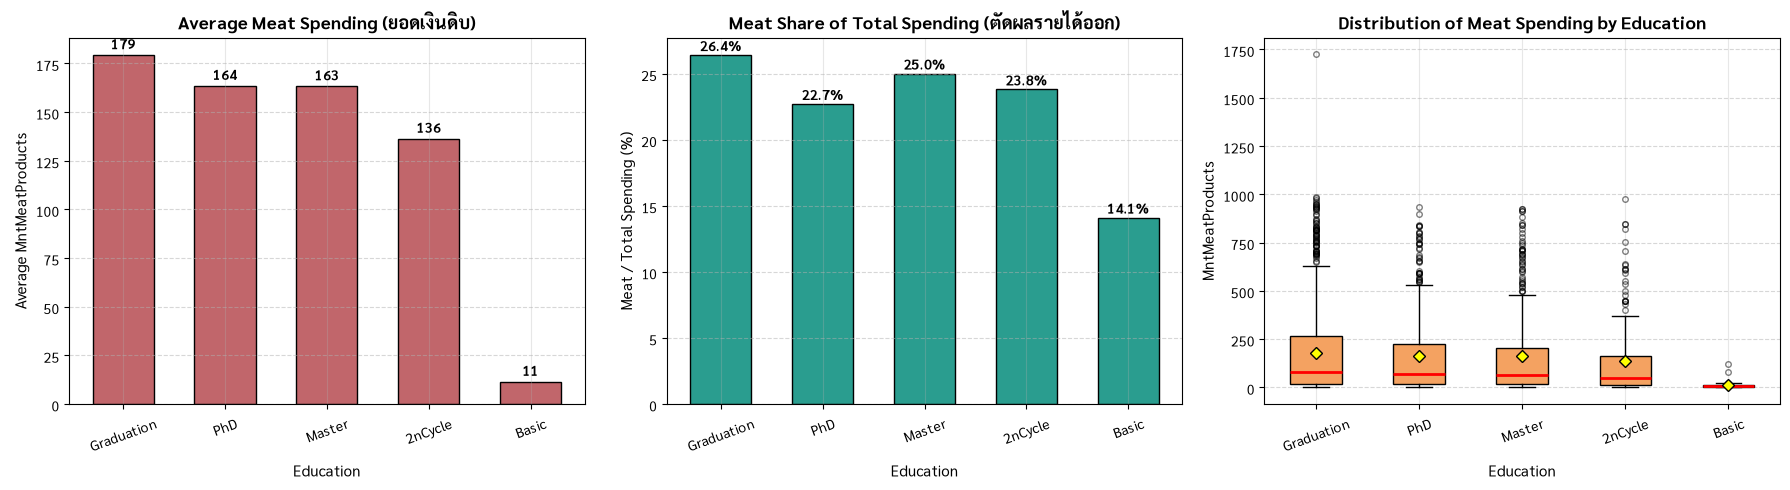

INSIGHT: Dietary Preferences by Education
1. เมื่อดู 'ยอดเงิน' กลุ่ม Graduation ใช้จ่ายเนื้อสัตว์สูงสุด (179)
2. แต่เมื่อดู 'สัดส่วน' กลุ่ม Graduation ให้น้ำหนักกับเนื้อสัตว์สูงสุด (26.4% ของยอดใช้จ่ายรวม)
   -> ทั้งสองมุมชี้กลุ่มเดียวกัน ความชอบเนื้อสัตว์ของกลุ่มนี้ชัดเจน
3. ความต่างของ Meat Share ระหว่างกลุ่มสูงสุด-ต่ำสุด เพียง 12.3 จุดเปอร์เซ็นต์
   -> ความชอบเนื้อสัตว์ 'เชิงสัดส่วน' ไม่ต่างกันมากระหว่างระดับการศึกษา
4. ส่วนต่างของยอดเงินดิบ (168) อธิบายด้วยรายได้ได้เป็นส่วนใหญ่

ข้อเสนอแนะเชิงธุรกิจ:
  - ไม่ควรแบ่ง Segment สินค้าเนื้อสัตว์ด้วย 'ระดับการศึกษา' เพราะความชอบไม่ต่างกันจริง
  - ควรใช้ 'รายได้' เป็นเกณฑ์แบ่งระดับราคาสินค้าเนื้อสัตว์แทน
  - กลุ่มการศึกษาสูง+รายได้สูง เสนอเนื้อเกรดพรีเมียม / นำเข้า

ข้อจำกัด: การศึกษาและรายได้สัมพันธ์กัน (r = 0.174 เมื่อเรียงเป็นอันดับ)
          การสรุปว่า 'การศึกษาเป็นสาเหตุ' จึงทำไม่ได้จากข้อมูลนี้


In [56]:
# =============================================================================
# Exercise 22: Education vs Meat Purchases — Dietary Preferences
# =============================================================================
from scipy import stats

mnt_cols = ["MntWines", "MntFruits", "MntMeatProducts",
            "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

# --- สร้างคอลัมน์ยอดใช้จ่ายรวม และสัดส่วนเนื้อสัตว์ ---
df["Total_Spending"] = df[mnt_cols].sum(axis=1)
df["Meat_Share"] = df["MntMeatProducts"] / df["Total_Spending"].replace(0, np.nan)

# ----- ขั้นที่ 1: เทียบยอดเงินดิบ (ตามที่โจทย์ถาม) -----
meat_by_edu = df.groupby("Education").agg(
    n=("MntMeatProducts", "count"),
    avg_meat=("MntMeatProducts", "mean"),
    median_meat=("MntMeatProducts", "median"),
    avg_income=("Income", "mean"),
    avg_total_spend=("Total_Spending", "mean"),
    meat_share=("Meat_Share", "mean"),
).round(3).sort_values("avg_meat", ascending=False)
meat_by_edu["meat_share_%"] = (meat_by_edu["meat_share"] * 100).round(2)

print("=" * 105)
print("ยอดใช้จ่ายเนื้อสัตว์แยกตามระดับการศึกษา")
print("=" * 105)
print(meat_by_edu.drop(columns=["meat_share"]).to_string())

# ----- ขั้นที่ 2: ทดสอบนัยสำคัญด้วย ANOVA -----
groups = [df.loc[df["Education"] == lvl, "MntMeatProducts"]
          for lvl in df["Education"].unique()]
f_stat, p_val = stats.f_oneway(*groups)

print("\n" + "=" * 75)
print("One-way ANOVA: ค่าเฉลี่ยยอดเนื้อสัตว์ต่างกันระหว่างกลุ่มการศึกษาหรือไม่")
print("=" * 75)
print(f"F-statistic = {f_stat:.4f}")
print(f"p-value     = {p_val:.3e}")
print(f"สรุป: {'ต่างกันอย่างมีนัยสำคัญ (p < 0.05)' if p_val < 0.05 else 'ไม่ต่างกันอย่างมีนัยสำคัญ'}")

# --- ANOVA ของสัดส่วน (ตัดผลกำลังซื้อออกแล้ว) ---
groups_share = [df.loc[df["Education"] == lvl, "Meat_Share"].dropna()
                for lvl in df["Education"].unique()]
f_s, p_s = stats.f_oneway(*groups_share)
print(f"\nANOVA ของ Meat Share: F = {f_s:.4f}, p = {p_s:.3e}")
print(f"สรุป: {'สัดส่วนต่างกันอย่างมีนัยสำคัญ' if p_s < 0.05 else 'สัดส่วนไม่ต่างกันอย่างมีนัยสำคัญ'}")

# ----- ขั้นที่ 3: Visualize 3 แผง -----
order = meat_by_edu.index.tolist()
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# แผง 1: ยอดเงินดิบ
b1 = ax[0].bar(order, meat_by_edu["avg_meat"], color="#C1666B",
               edgecolor="black", width=0.6)
for bar, v in zip(b1, meat_by_edu["avg_meat"]):
    ax[0].text(bar.get_x() + bar.get_width()/2, v + 3, f"{v:,.0f}",
               ha="center", fontsize=10, fontweight="bold")
ax[0].set_title("Average Meat Spending (ยอดเงินดิบ)", fontsize=13, fontweight="bold")
ax[0].set_xlabel("Education", fontsize=11)
ax[0].set_ylabel("Average MntMeatProducts", fontsize=11)
ax[0].tick_params(axis="x", rotation=20)
ax[0].grid(axis="y", linestyle="--", alpha=0.5)

# แผง 2: สัดส่วน — ตัดผลกำลังซื้อออกแล้ว
b2 = ax[1].bar(order, meat_by_edu["meat_share_%"], color="#2A9D8F",
               edgecolor="black", width=0.6)
for bar, v in zip(b2, meat_by_edu["meat_share_%"]):
    ax[1].text(bar.get_x() + bar.get_width()/2, v + 0.3, f"{v:.1f}%",
               ha="center", fontsize=10, fontweight="bold")
ax[1].set_title("Meat Share of Total Spending (ตัดผลรายได้ออก)",
                fontsize=13, fontweight="bold")
ax[1].set_xlabel("Education", fontsize=11)
ax[1].set_ylabel("Meat / Total Spending (%)", fontsize=11)
ax[1].tick_params(axis="x", rotation=20)
ax[1].grid(axis="y", linestyle="--", alpha=0.5)

# แผง 3: Box Plot — เห็นการกระจายตัวด้วย
ax[2].boxplot([df.loc[df["Education"] == lvl, "MntMeatProducts"] for lvl in order],
              tick_labels=order, patch_artist=True, showmeans=True,
              boxprops=dict(facecolor="#F4A261", color="black"),
              medianprops=dict(color="red", linewidth=2),
              meanprops=dict(marker="D", markerfacecolor="yellow",
                             markeredgecolor="black", markersize=6),
              flierprops=dict(marker="o", markersize=4, alpha=0.5))
ax[2].set_title("Distribution of Meat Spending by Education", fontsize=13, fontweight="bold")
ax[2].set_xlabel("Education", fontsize=11)
ax[2].set_ylabel("MntMeatProducts", fontsize=11)
ax[2].tick_params(axis="x", rotation=20)
ax[2].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# ----- ขั้นที่ 4: สรุป Insight -----
top_money = meat_by_edu.index[0]
share_sorted = meat_by_edu.sort_values("meat_share_%", ascending=False)
top_share = share_sorted.index[0]

print("=" * 75)
print("INSIGHT: Dietary Preferences by Education")
print("=" * 75)
print(f"1. เมื่อดู 'ยอดเงิน' กลุ่ม {top_money} ใช้จ่ายเนื้อสัตว์สูงสุด "
      f"({meat_by_edu['avg_meat'].iloc[0]:,.0f})")
print(f"2. แต่เมื่อดู 'สัดส่วน' กลุ่ม {top_share} ให้น้ำหนักกับเนื้อสัตว์สูงสุด "
      f"({share_sorted['meat_share_%'].iloc[0]:.1f}% ของยอดใช้จ่ายรวม)")
if top_money != top_share:
    print("   -> สองมุมให้คำตอบต่างกัน! แสดงว่ายอดเงินดิบถูกบิดด้วยกำลังซื้อ")
else:
    print("   -> ทั้งสองมุมชี้กลุ่มเดียวกัน ความชอบเนื้อสัตว์ของกลุ่มนี้ชัดเจน")
print(f"3. ความต่างของ Meat Share ระหว่างกลุ่มสูงสุด-ต่ำสุด เพียง "
      f"{share_sorted['meat_share_%'].iloc[0] - share_sorted['meat_share_%'].iloc[-1]:.1f} "
      "จุดเปอร์เซ็นต์")
print("   -> ความชอบเนื้อสัตว์ 'เชิงสัดส่วน' ไม่ต่างกันมากระหว่างระดับการศึกษา")
print(f"4. ส่วนต่างของยอดเงินดิบ ({meat_by_edu['avg_meat'].iloc[0] - meat_by_edu['avg_meat'].iloc[-1]:,.0f}) "
      "อธิบายด้วยรายได้ได้เป็นส่วนใหญ่")

print("\nข้อเสนอแนะเชิงธุรกิจ:")
print("  - ไม่ควรแบ่ง Segment สินค้าเนื้อสัตว์ด้วย 'ระดับการศึกษา' เพราะความชอบไม่ต่างกันจริง")
print("  - ควรใช้ 'รายได้' เป็นเกณฑ์แบ่งระดับราคาสินค้าเนื้อสัตว์แทน")
print("  - กลุ่มการศึกษาสูง+รายได้สูง เสนอเนื้อเกรดพรีเมียม / นำเข้า")
# แปลง Education เป็นอันดับตัวเลข (Ordinal) แล้ววัดความสัมพันธ์กับรายได้
edu_order = {"Basic": 1, "2nCycle": 2, "Graduation": 3, "Master": 4, "PhD": 5}
edu_rank = df["Education"].map(edu_order)
r_edu_income = edu_rank.corr(df["Income"])

print(f"\nข้อจำกัด: การศึกษาและรายได้สัมพันธ์กัน (r = {r_edu_income:.3f} เมื่อเรียงเป็นอันดับ)")
print("          การสรุปว่า 'การศึกษาเป็นสาเหตุ' จึงทำไม่ได้จากข้อมูลนี้")

---

## Exercise 23 — Marital Status vs Online Behavior

> **โจทย์:** Examine differences in `NumWebPurchases` and `NumWebVisitsMonth` across `Marital` categories. What insight can be drawn about digital engagement by family status?

**วัตถุประสงค์:** วิเคราะห์ความต่างของพฤติกรรมดิจิทัลตามสถานภาพครอบครัว

### การตีความ 2 ตัวชี้วัดคู่กัน — Matrix 4 ช่อง

ตัวชี้วัด 2 ตัวนี้ตีความคู่กันได้เป็น 4 รูปแบบพฤติกรรม

| | **Visits ต่ำ** | **Visits สูง** |
|---|---|---|
| **Purchases สูง** | ★ **Efficient Buyer** — รู้ว่าต้องการอะไร เข้ามาซื้อเลย | **Heavy Engager** — ทั้งดูทั้งซื้อมาก |
| **Purchases ต่ำ** | **Offline-oriented** — ไม่ใช้ช่องทางออนไลน์ | ⚠ **Browser** — ดูเยอะแต่ไม่ซื้อ (เสียโอกาส) |

กลุ่ม **Browser** คือกลุ่มที่มี **โอกาสปรับปรุงสูงสุด** — มีความสนใจแล้ว แต่ติดขัดบางอย่างจนไม่ซื้อ (ราคา, ความเชื่อมั่น, ขั้นตอนชำระเงิน)

### Channel Mix — สัดส่วนการใช้ช่องทาง

นอกจากดูออนไลน์อย่างเดียว ควรเทียบกับช่องทางอื่นเพื่อเห็นภาพรวม

```
Web Share = NumWebPurchases / (Web + Catalog + Store)
```

บอกว่าแต่ละกลุ่ม **พึ่งพาช่องทางออนไลน์** มากน้อยเพียงใดเมื่อเทียบกับหน้าร้านและแคตตาล็อก

พฤติกรรมดิจิทัลแยกตามสถานภาพสมรส
            n  web_purchases  web_visits  conversion  store_purchases  catalog_purchases  web_share_%
Marital                                                                                              
Widow      76          4.618       4.934       1.225            6.355              3.303         32.2
Single    477          3.876       5.285       1.117            5.679              2.639         32.4
Married   854          4.100       5.375       1.072            5.869              2.581         33.3
Divorced  230          4.339       5.513       1.066            5.861              2.691         33.6
Together  568          4.125       5.306       1.060            5.790              2.641         33.1

One-way ANOVA: พฤติกรรมดิจิทัลต่างกันระหว่างกลุ่มหรือไม่
  NumWebPurchases      : F =  1.9316, p = 0.1025 -> ไม่ต่างกันอย่างมีนัยสำคัญ
  NumWebVisitsMonth    : F =  0.9652, p = 0.4254 -> ไม่ต่างกันอย่างมีนัยสำคัญ


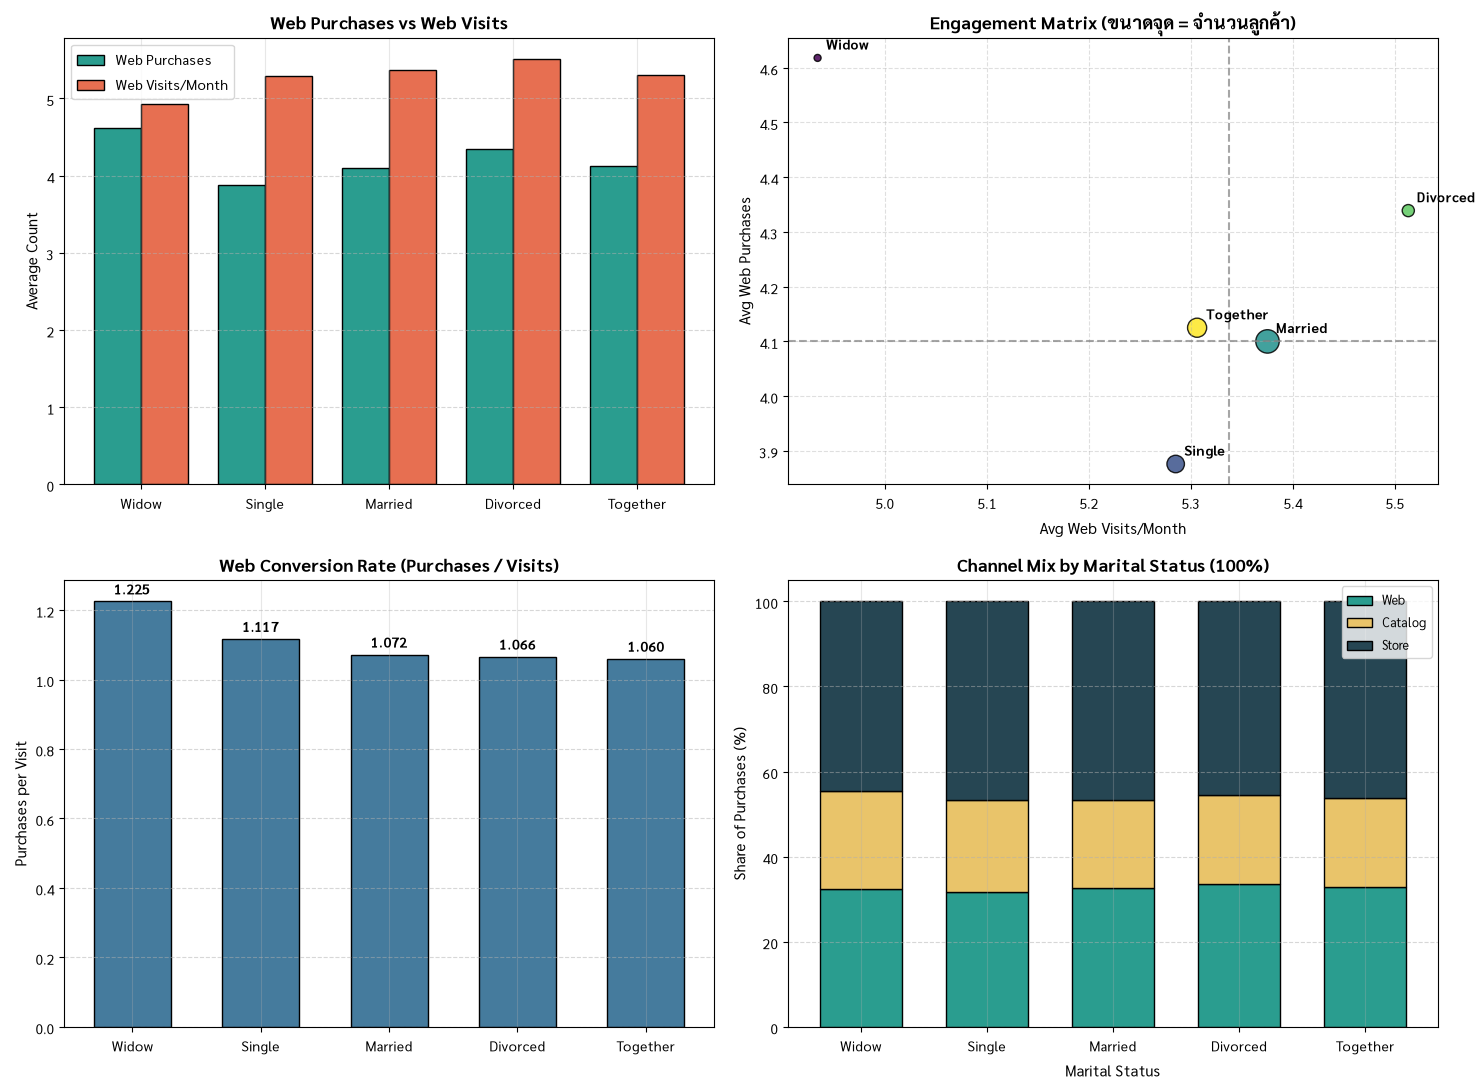

INSIGHT: Digital Engagement by Family Status
เกณฑ์แบ่ง: Visits เฉลี่ยรวม = 5.34, Purchases เฉลี่ยรวม = 4.10

  Widow        (n=  76) : Efficient Buyer — เข้าน้อยแต่ซื้อมาก (กลุ่มคุณภาพ)
  Single       (n= 477) : Offline-oriented — ไม่ค่อยใช้ช่องทางออนไลน์
  Married      (n= 854) : Browser — ดูเยอะแต่ซื้อน้อย (โอกาสปรับปรุง)
  Divorced     (n= 230) : Heavy Engager — ทั้งดูทั้งซื้อมาก
  Together     (n= 568) : Efficient Buyer — เข้าน้อยแต่ซื้อมาก (กลุ่มคุณภาพ)

1. Widow มี Conversion Rate สูงสุด (1.225)
2. Together ต่ำสุด (1.060) — ต่างกัน 1.16 เท่า
3. สัดส่วนการซื้อผ่านเว็บของทุกกลุ่มอยู่ราว 32-34% ของการซื้อทั้งหมด
4. หน้าร้าน (Store) ยังเป็นช่องทางหลักของทุกกลุ่ม — เว็บเป็นช่องทางเสริม

ข้อเสนอแนะเชิงธุรกิจ:
  - กลุ่ม Browser (Visits สูง Purchases ต่ำ): ทำ Retargeting Ads, Cart Abandonment Email, ลดขั้นตอนชำระเงิน
  - กลุ่ม Efficient Buyer: เสนอ Subscription / Auto-replenish เพราะรู้ว่าต้องการอะไรอยู่แล้ว
  - กลุ่ม Offline-oriented: ทำ Omnichannel เช่น Click & Collect เชื่อมออนไลน์กับ

In [57]:
# =============================================================================
# Exercise 23: Marital Status vs Online Behavior — Digital Engagement
# =============================================================================
from scipy import stats

purchase_cols = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]

# --- สร้าง Metric เพิ่มเติม ---
df["Total_Purchases"] = df[purchase_cols].sum(axis=1)
df["Web_Share"] = df["NumWebPurchases"] / df["Total_Purchases"].replace(0, np.nan)
df["Web_Conversion"] = df["NumWebPurchases"] / df["NumWebVisitsMonth"].replace(0, np.nan)

# ----- ขั้นที่ 1: ตารางสรุปตามสถานภาพสมรส -----
online = df.groupby("Marital").agg(
    n=("NumWebPurchases", "count"),
    web_purchases=("NumWebPurchases", "mean"),
    web_visits=("NumWebVisitsMonth", "mean"),
    conversion=("Web_Conversion", "mean"),
    web_share=("Web_Share", "mean"),
    store_purchases=("NumStorePurchases", "mean"),
    catalog_purchases=("NumCatalogPurchases", "mean"),
).round(3)
online["web_share_%"] = (online["web_share"] * 100).round(2)
online = online.drop(columns=["web_share"]).sort_values("conversion", ascending=False)

print("=" * 110)
print("พฤติกรรมดิจิทัลแยกตามสถานภาพสมรส")
print("=" * 110)
print(online.to_string())

# ----- ขั้นที่ 2: ทดสอบนัยสำคัญ -----
print("\n" + "=" * 75)
print("One-way ANOVA: พฤติกรรมดิจิทัลต่างกันระหว่างกลุ่มหรือไม่")
print("=" * 75)
for metric in ["NumWebPurchases", "NumWebVisitsMonth"]:
    groups = [df.loc[df["Marital"] == m, metric] for m in df["Marital"].unique()]
    f, p = stats.f_oneway(*groups)
    verdict = "ต่างกันอย่างมีนัยสำคัญ" if p < 0.05 else "ไม่ต่างกันอย่างมีนัยสำคัญ"
    print(f"  {metric:<20} : F = {f:>7.4f}, p = {p:.4f} -> {verdict}")

# ----- ขั้นที่ 3: Visualize 4 แผง -----
order = online.index.tolist()
fig, ax = plt.subplots(2, 2, figsize=(15, 11))

# แผง (0,0): Grouped Bar — Purchases vs Visits
x = np.arange(len(order))
w = 0.38
ax[0, 0].bar(x - w/2, online["web_purchases"], w, label="Web Purchases",
             color="#2A9D8F", edgecolor="black")
ax[0, 0].bar(x + w/2, online["web_visits"], w, label="Web Visits/Month",
             color="#E76F51", edgecolor="black")
ax[0, 0].set_xticks(x); ax[0, 0].set_xticklabels(order)
ax[0, 0].set_title("Web Purchases vs Web Visits", fontsize=13, fontweight="bold")
ax[0, 0].set_ylabel("Average Count", fontsize=11)
ax[0, 0].legend(); ax[0, 0].grid(axis="y", linestyle="--", alpha=0.5)

# แผง (0,1): Scatter Matrix 4 ช่อง — Visits vs Purchases
ax[0, 1].scatter(online["web_visits"], online["web_purchases"],
                 s=online["n"] / 3, c=range(len(order)), cmap="viridis",
                 edgecolors="black", alpha=0.85)
for i, m in enumerate(order):
    ax[0, 1].annotate(m, (online["web_visits"].iloc[i], online["web_purchases"].iloc[i]),
                      xytext=(6, 6), textcoords="offset points",
                      fontsize=10, fontweight="bold")
# เส้นแบ่ง 4 ควอดแรนต์ที่ค่าเฉลี่ยรวม
ax[0, 1].axhline(df["NumWebPurchases"].mean(), color="gray", linestyle="--", alpha=0.7)
ax[0, 1].axvline(df["NumWebVisitsMonth"].mean(), color="gray", linestyle="--", alpha=0.7)
ax[0, 1].set_title("Engagement Matrix (ขนาดจุด = จำนวนลูกค้า)",
                   fontsize=13, fontweight="bold")
ax[0, 1].set_xlabel("Avg Web Visits/Month", fontsize=11)
ax[0, 1].set_ylabel("Avg Web Purchases", fontsize=11)
ax[0, 1].grid(linestyle="--", alpha=0.4)

# แผง (1,0): Conversion Rate
bars = ax[1, 0].bar(order, online["conversion"], color="#457B9D",
                    edgecolor="black", width=0.6)
for bar, v in zip(bars, online["conversion"]):
    ax[1, 0].text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.3f}",
                  ha="center", fontsize=10, fontweight="bold")
ax[1, 0].set_title("Web Conversion Rate (Purchases / Visits)",
                   fontsize=13, fontweight="bold")
ax[1, 0].set_ylabel("Purchases per Visit", fontsize=11)
ax[1, 0].grid(axis="y", linestyle="--", alpha=0.5)

# แผง (1,1): Channel Mix แบบ 100% Stacked
mix = online[["web_purchases", "catalog_purchases", "store_purchases"]]
mix_pct = mix.div(mix.sum(axis=1), axis=0) * 100
mix_pct.plot(kind="bar", stacked=True, ax=ax[1, 1],
             color=["#2A9D8F", "#E9C46A", "#264653"], edgecolor="black", width=0.65)
ax[1, 1].set_title("Channel Mix by Marital Status (100%)", fontsize=13, fontweight="bold")
ax[1, 1].set_ylabel("Share of Purchases (%)", fontsize=11)
ax[1, 1].set_xlabel("Marital Status", fontsize=11)
ax[1, 1].legend(["Web", "Catalog", "Store"], fontsize=9)
ax[1, 1].tick_params(axis="x", rotation=0)
ax[1, 1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# ----- ขั้นที่ 4: จัดกลุ่มตาม Engagement Matrix -----
mean_v = df["NumWebVisitsMonth"].mean()
mean_p = df["NumWebPurchases"].mean()

print("=" * 75)
print("INSIGHT: Digital Engagement by Family Status")
print("=" * 75)
print(f"เกณฑ์แบ่ง: Visits เฉลี่ยรวม = {mean_v:.2f}, Purchases เฉลี่ยรวม = {mean_p:.2f}\n")
for m in order:
    v, p = online.loc[m, "web_visits"], online.loc[m, "web_purchases"]
    if p >= mean_p and v < mean_v:
        label = "Efficient Buyer — เข้าน้อยแต่ซื้อมาก (กลุ่มคุณภาพ)"
    elif p >= mean_p and v >= mean_v:
        label = "Heavy Engager — ทั้งดูทั้งซื้อมาก"
    elif p < mean_p and v >= mean_v:
        label = "Browser — ดูเยอะแต่ซื้อน้อย (โอกาสปรับปรุง)"
    else:
        label = "Offline-oriented — ไม่ค่อยใช้ช่องทางออนไลน์"
    print(f"  {m:<12} (n={int(online.loc[m, 'n']):>4}) : {label}")

best, worst = order[0], order[-1]
print(f"\n1. {best} มี Conversion Rate สูงสุด ({online.loc[best, 'conversion']:.3f})")
print(f"2. {worst} ต่ำสุด ({online.loc[worst, 'conversion']:.3f}) — "
      f"ต่างกัน {online.loc[best, 'conversion']/online.loc[worst, 'conversion']:.2f} เท่า")
print(f"3. สัดส่วนการซื้อผ่านเว็บของทุกกลุ่มอยู่ราว "
      f"{online['web_share_%'].min():.0f}-{online['web_share_%'].max():.0f}% "
      "ของการซื้อทั้งหมด")
print("4. หน้าร้าน (Store) ยังเป็นช่องทางหลักของทุกกลุ่ม — เว็บเป็นช่องทางเสริม")

print("\nข้อเสนอแนะเชิงธุรกิจ:")
print(f"  - กลุ่ม Browser (Visits สูง Purchases ต่ำ): ทำ Retargeting Ads, "
      "Cart Abandonment Email, ลดขั้นตอนชำระเงิน")
print(f"  - กลุ่ม Efficient Buyer: เสนอ Subscription / Auto-replenish "
      "เพราะรู้ว่าต้องการอะไรอยู่แล้ว")
print("  - กลุ่ม Offline-oriented: ทำ Omnichannel เช่น Click & Collect "
      "เชื่อมออนไลน์กับหน้าร้าน")

---

## Exercise 24 — Age vs Campaign Response

> **โจทย์:** Investigate whether age `Age` influences the likelihood of responding to campaigns `Response`. Which age group is most receptive?

**วัตถุประสงค์:** ตรวจสอบว่าอายุมีผลต่อโอกาสตอบรับแคมเปญหรือไม่ และกลุ่มอายุใดตอบรับดีที่สุด

### ปัญหา: ตัวแปรตามเป็น Binary (0/1)

`Response` มีแค่ 0 กับ 1 จึงใช้ Scatter Plot ธรรมดาดูแนวโน้มไม่ได้ (จุดจะเรียงเป็น 2 เส้นเท่านั้น)
**วิธีแก้:** แบ่งอายุเป็นช่วง (Age Band) แล้วคำนวณ **Response Rate ในแต่ละช่วง**

```python
df.groupby("Age_Group")["Response"].mean()   # ค่าเฉลี่ยของ 0/1 = อัตราการตอบรับ
```

### การแบ่งช่วงอายุด้วย `pd.cut` กำหนดขอบเอง

```python
bins = [0, 30, 40, 50, 60, 70, 200]
labels = ["<30", "30-39", "40-49", "50-59", "60-69", "70+"]
pd.cut(df["Age"], bins=bins, labels=labels)
```

การกำหนดขอบช่วงเองดีกว่า `bins=n` เพราะได้ช่วงที่ **สื่อความหมายทางการตลาด** (Generation-based)

### การทดสอบนัยสำคัญสำหรับข้อมูลหมวดหมู่: Chi-square Test

```python
stats.chi2_contingency(pd.crosstab(df["Age_Group"], df["Response"]))
```

ทดสอบว่า 2 ตัวแปรหมวดหมู่ **เป็นอิสระต่อกัน** หรือไม่

- `p < 0.05` → อายุและการตอบรับ **ไม่เป็นอิสระ** (อายุมีความสัมพันธ์จริง)
- `p ≥ 0.05` → ความต่างที่เห็นอาจเกิดจากความผันผวนจากการสุ่ม

### Lift — ตัวชี้วัดที่นักการตลาดใช้จริง

```
Lift = Response Rate ของกลุ่ม / Response Rate เฉลี่ยทั้งระบบ
```

`Lift = 1.5` หมายความว่ากลุ่มนี้ตอบรับดีกว่าค่าเฉลี่ย **50%** ใช้จัดลำดับความสำคัญของกลุ่มเป้าหมายได้ทันที

Response Rate แยกตามช่วงอายุ (ค่าเฉลี่ยรวม = 15.10%)
             n  n_responded  avg_income  avg_spending  response_rate_%   lift
Age_Group                                                                    
<30         43           10  57882.5581      927.1860            23.26  1.540
30-39      336           66  44773.3542      531.9048            19.64  1.300
40-49      691           94  48015.3430      502.7221            13.60  0.901
50-59      528           75  53359.7955      635.8333            14.20  0.940
60-69      473           60  56777.6469      689.2474            12.68  0.840
70+        134           28  60339.7090      823.4179            20.90  1.384

การทดสอบทางสถิติ
Chi-square test (Age_Group x Response):
  chi2 = 14.8384, dof = 5, p-value = 0.0111
  สรุป: ไม่เป็นอิสระ -> อายุสัมพันธ์กับการตอบรับ

Welch's t-test (อายุของผู้ตอบรับ vs ไม่ตอบรับ):
  อายุเฉลี่ยผู้ตอบรับ    : 50.50 ปี (n = 333)
  อายุเฉลี่ยผู้ไม่ตอบรับ : 51.20 ปี (n = 1,872)
  t = -0.9579, p-value = 0.33

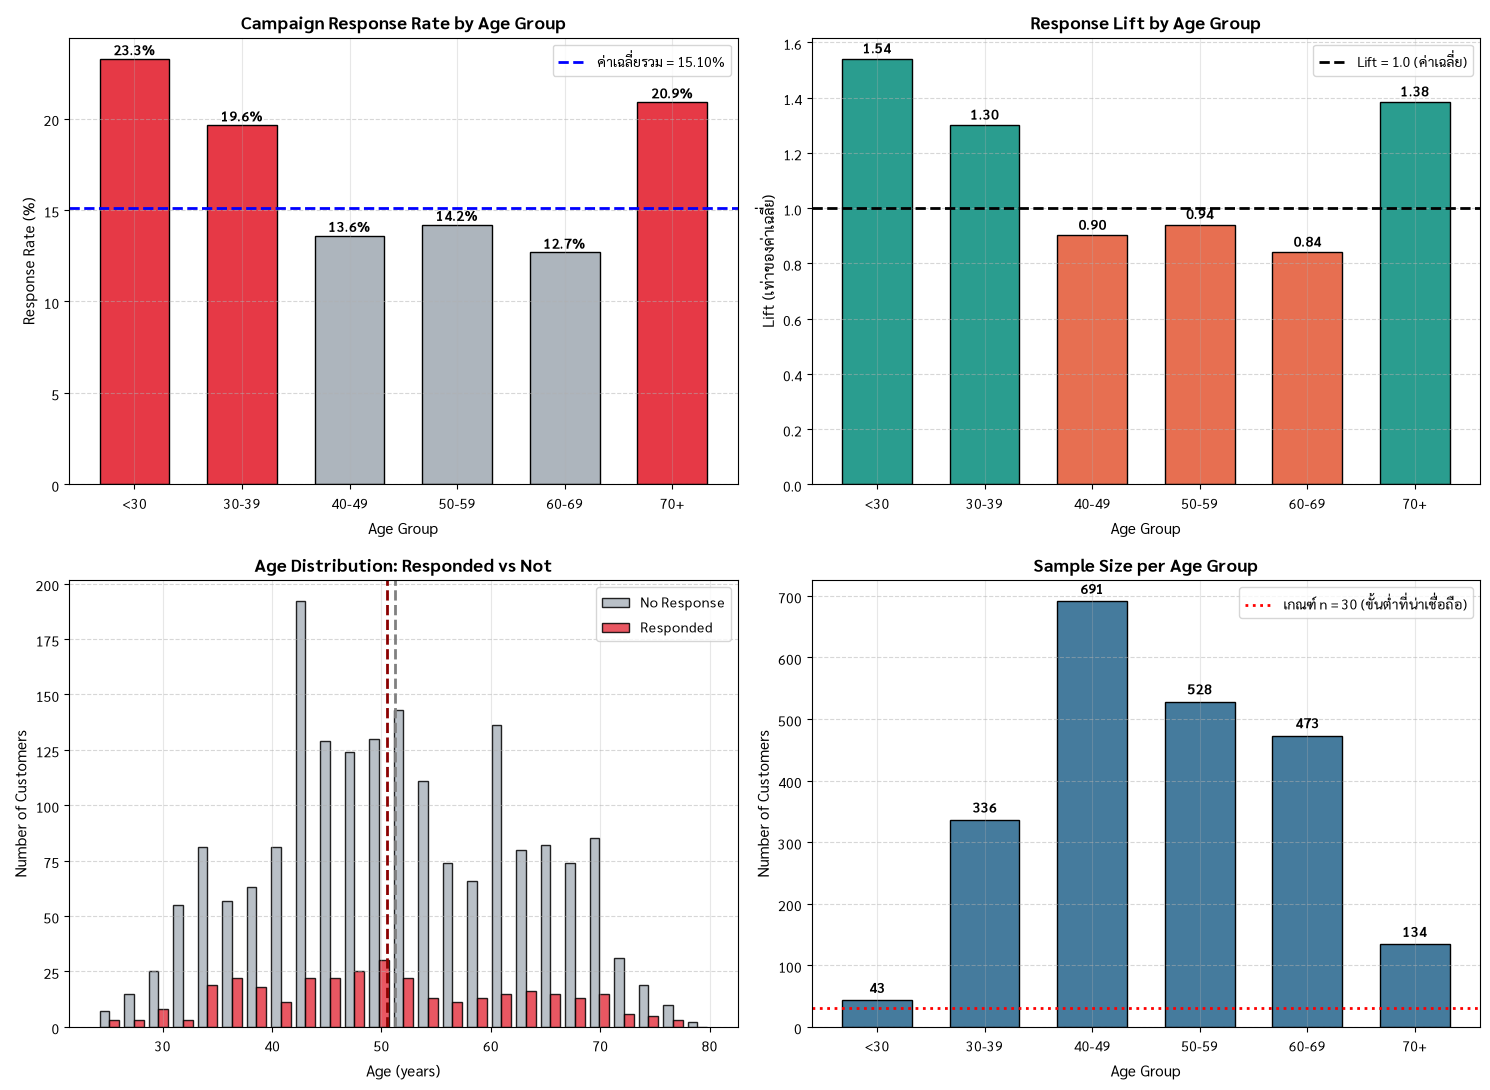

INSIGHT: Which Age Group is Most Receptive?
1. กลุ่มอายุที่ตอบรับดีที่สุด (n >= 30) : <30 (23.26%, Lift = 1.54)
2. กลุ่มอายุที่ตอบรับต่ำสุด           : 60-69 (12.68%, Lift = 0.84)
3. ความต่างระหว่างกลุ่มดีสุด-แย่สุด : 10.58 จุดเปอร์เซ็นต์
4. อายุเฉลี่ยของผู้ตอบรับสูงกว่าผู้ไม่ตอบรับ -0.70 ปี

ข้อสรุปทางสถิติ:
  อายุสัมพันธ์กับการตอบรับแคมเปญอย่างมีนัยสำคัญ (chi2 p = 0.0111)
  แต่ขนาดของความสัมพันธ์เล็กมาก (point-biserial r = -0.021)
  -> อายุเพียงตัวเดียวไม่เพียงพอที่จะใช้ทำนายการตอบรับแคมเปญ

ข้อเสนอแนะเชิงธุรกิจ:
  - จัดลำดับความสำคัญกลุ่ม <30 เป็นเป้าหมายแรกของแคมเปญถัดไป
  - ไม่ควรใช้อายุเป็นเกณฑ์เดียว ควรรวมกับรายได้และประวัติการซื้อ
  - สร้าง Propensity Model ที่ใช้หลายตัวแปรร่วมกันจะแม่นกว่าการแบ่งตามอายุอย่างเดียว


In [58]:
# =============================================================================
# Exercise 24: Age vs Campaign Response — Most Receptive Age Group
# =============================================================================
from scipy import stats

# ----- ขั้นที่ 1: แบ่งช่วงอายุแบบกำหนดขอบเอง -----
bins = [0, 30, 40, 50, 60, 70, 200]
labels = ["<30", "30-39", "40-49", "50-59", "60-69", "70+"]
df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=False)

overall_rate = df["Response"].mean()

# --- คำนวณ Response Rate และ Lift ของแต่ละช่วงอายุ ---
age_resp = df.groupby("Age_Group", observed=True).agg(
    n=("Response", "count"),
    n_responded=("Response", "sum"),
    response_rate=("Response", "mean"),
    avg_income=("Income", "mean"),
    avg_spending=("Total_Spending", "mean"),
).round(4)
age_resp["response_rate_%"] = (age_resp["response_rate"] * 100).round(2)
age_resp["lift"] = (age_resp["response_rate"] / overall_rate).round(3)

print("=" * 100)
print(f"Response Rate แยกตามช่วงอายุ (ค่าเฉลี่ยรวม = {overall_rate*100:.2f}%)")
print("=" * 100)
print(age_resp.drop(columns=["response_rate"]).to_string())

# ----- ขั้นที่ 2: ทดสอบนัยสำคัญ -----
print("\n" + "=" * 75)
print("การทดสอบทางสถิติ")
print("=" * 75)

# Chi-square: อายุ (แบ่งกลุ่ม) กับการตอบรับ เป็นอิสระต่อกันหรือไม่
ct = pd.crosstab(df["Age_Group"], df["Response"])
chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
print(f"Chi-square test (Age_Group x Response):")
print(f"  chi2 = {chi2:.4f}, dof = {dof}, p-value = {p_chi:.4f}")
print(f"  สรุป: {'ไม่เป็นอิสระ -> อายุสัมพันธ์กับการตอบรับ' if p_chi < 0.05 else 'เป็นอิสระ -> ไม่พบความสัมพันธ์ที่มีนัยสำคัญ'}")

# t-test: อายุเฉลี่ยของผู้ตอบรับ vs ไม่ตอบรับ ต่างกันหรือไม่
age_yes = df.loc[df["Response"] == 1, "Age"]
age_no = df.loc[df["Response"] == 0, "Age"]
t_stat, p_t = stats.ttest_ind(age_yes, age_no, equal_var=False)   # Welch's t-test
print(f"\nWelch's t-test (อายุของผู้ตอบรับ vs ไม่ตอบรับ):")
print(f"  อายุเฉลี่ยผู้ตอบรับ    : {age_yes.mean():.2f} ปี (n = {len(age_yes):,})")
print(f"  อายุเฉลี่ยผู้ไม่ตอบรับ : {age_no.mean():.2f} ปี (n = {len(age_no):,})")
print(f"  t = {t_stat:.4f}, p-value = {p_t:.4f}")
print(f"  สรุป: {'ต่างกันอย่างมีนัยสำคัญ' if p_t < 0.05 else 'ไม่ต่างกันอย่างมีนัยสำคัญ'}")

# Point-biserial correlation: สำหรับ ตัวแปรต่อเนื่อง vs binary
r_pb, p_pb = stats.pointbiserialr(df["Response"], df["Age"])
print(f"\nPoint-biserial correlation (Age vs Response): r = {r_pb:.4f}, p = {p_pb:.4f}")

# ----- ขั้นที่ 3: Visualize 4 แผง -----
fig, ax = plt.subplots(2, 2, figsize=(15, 11))
ag_idx = age_resp.index.astype(str)

# แผง (0,0): Response Rate ต่อช่วงอายุ + เส้นค่าเฉลี่ยรวม
colors = ["#E63946" if v > overall_rate else "#ADB5BD"
          for v in age_resp["response_rate"]]
bars = ax[0, 0].bar(ag_idx, age_resp["response_rate_%"], color=colors,
                    edgecolor="black", width=0.65)
for bar, v in zip(bars, age_resp["response_rate_%"]):
    ax[0, 0].text(bar.get_x() + bar.get_width()/2, v + 0.2, f"{v:.1f}%",
                  ha="center", fontsize=10, fontweight="bold")
ax[0, 0].axhline(overall_rate * 100, color="blue", linestyle="--", linewidth=2,
                 label=f"ค่าเฉลี่ยรวม = {overall_rate*100:.2f}%")
ax[0, 0].set_title("Campaign Response Rate by Age Group", fontsize=13, fontweight="bold")
ax[0, 0].set_xlabel("Age Group", fontsize=11)
ax[0, 0].set_ylabel("Response Rate (%)", fontsize=11)
ax[0, 0].legend()
ax[0, 0].grid(axis="y", linestyle="--", alpha=0.5)

# แผง (0,1): Lift — เกิน 1.0 คือดีกว่าค่าเฉลี่ย
lift_colors = ["#2A9D8F" if v >= 1 else "#E76F51" for v in age_resp["lift"]]
bars2 = ax[0, 1].bar(ag_idx, age_resp["lift"], color=lift_colors,
                     edgecolor="black", width=0.65)
for bar, v in zip(bars2, age_resp["lift"]):
    ax[0, 1].text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.2f}",
                  ha="center", fontsize=10, fontweight="bold")
ax[0, 1].axhline(1.0, color="black", linestyle="--", linewidth=2, label="Lift = 1.0 (ค่าเฉลี่ย)")
ax[0, 1].set_title("Response Lift by Age Group", fontsize=13, fontweight="bold")
ax[0, 1].set_xlabel("Age Group", fontsize=11)
ax[0, 1].set_ylabel("Lift (เท่าของค่าเฉลี่ย)", fontsize=11)
ax[0, 1].legend()
ax[0, 1].grid(axis="y", linestyle="--", alpha=0.5)

# แผง (1,0): Histogram เทียบการกระจายอายุของ 2 กลุ่ม
ax[1, 0].hist([age_no, age_yes], bins=25, label=["No Response", "Responded"],
              color=["#ADB5BD", "#E63946"], edgecolor="black", alpha=0.85)
ax[1, 0].axvline(age_no.mean(), color="gray", linestyle="--", linewidth=2)
ax[1, 0].axvline(age_yes.mean(), color="darkred", linestyle="--", linewidth=2)
ax[1, 0].set_title("Age Distribution: Responded vs Not", fontsize=13, fontweight="bold")
ax[1, 0].set_xlabel("Age (years)", fontsize=11)
ax[1, 0].set_ylabel("Number of Customers", fontsize=11)
ax[1, 0].legend()
ax[1, 0].grid(axis="y", linestyle="--", alpha=0.5)

# แผง (1,1): จำนวนลูกค้าในแต่ละช่วงอายุ — เตือนเรื่อง Sample size
bars3 = ax[1, 1].bar(ag_idx, age_resp["n"], color="#457B9D",
                     edgecolor="black", width=0.65)
for bar, v in zip(bars3, age_resp["n"]):
    ax[1, 1].text(bar.get_x() + bar.get_width()/2, v + 12, f"{v:,}",
                  ha="center", fontsize=10, fontweight="bold")
ax[1, 1].axhline(30, color="red", linestyle=":", linewidth=2,
                 label="เกณฑ์ n = 30 (ขั้นต่ำที่น่าเชื่อถือ)")
ax[1, 1].set_title("Sample Size per Age Group", fontsize=13, fontweight="bold")
ax[1, 1].set_xlabel("Age Group", fontsize=11)
ax[1, 1].set_ylabel("Number of Customers", fontsize=11)
ax[1, 1].legend()
ax[1, 1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# ----- ขั้นที่ 4: สรุป Insight -----
# พิจารณาเฉพาะกลุ่มที่มีสมาชิก >= 30 ราย เพื่อความน่าเชื่อถือ
reliable = age_resp[age_resp["n"] >= 30]
best_group = reliable["response_rate_%"].idxmax()
worst_group = reliable["response_rate_%"].idxmin()

print("=" * 75)
print("INSIGHT: Which Age Group is Most Receptive?")
print("=" * 75)
print(f"1. กลุ่มอายุที่ตอบรับดีที่สุด (n >= 30) : {best_group} "
      f"({reliable.loc[best_group, 'response_rate_%']:.2f}%, "
      f"Lift = {reliable.loc[best_group, 'lift']:.2f})")
print(f"2. กลุ่มอายุที่ตอบรับต่ำสุด           : {worst_group} "
      f"({reliable.loc[worst_group, 'response_rate_%']:.2f}%, "
      f"Lift = {reliable.loc[worst_group, 'lift']:.2f})")
print(f"3. ความต่างระหว่างกลุ่มดีสุด-แย่สุด : "
      f"{reliable.loc[best_group, 'response_rate_%'] - reliable.loc[worst_group, 'response_rate_%']:.2f} "
      "จุดเปอร์เซ็นต์")
print(f"4. อายุเฉลี่ยของผู้ตอบรับสูงกว่าผู้ไม่ตอบรับ "
      f"{age_yes.mean() - age_no.mean():+.2f} ปี")

small = age_resp[age_resp["n"] < 30]
if len(small) > 0:
    print(f"\nข้อควรระวัง: กลุ่ม {list(small.index.astype(str))} มีสมาชิกน้อยกว่า 30 ราย")
    print("             Response Rate ของกลุ่มนี้ผันผวนสูง ไม่ควรนำไปตัดสินใจ")

print("\nข้อสรุปทางสถิติ:")
if p_chi < 0.05:
    print(f"  อายุสัมพันธ์กับการตอบรับแคมเปญอย่างมีนัยสำคัญ (chi2 p = {p_chi:.4f})")
else:
    print(f"  ไม่พบความสัมพันธ์ที่มีนัยสำคัญระหว่างช่วงอายุกับการตอบรับ (chi2 p = {p_chi:.4f})")
print(f"  แต่ขนาดของความสัมพันธ์เล็กมาก (point-biserial r = {r_pb:.3f})")
print("  -> อายุเพียงตัวเดียวไม่เพียงพอที่จะใช้ทำนายการตอบรับแคมเปญ")

print("\nข้อเสนอแนะเชิงธุรกิจ:")
print(f"  - จัดลำดับความสำคัญกลุ่ม {best_group} เป็นเป้าหมายแรกของแคมเปญถัดไป")
print("  - ไม่ควรใช้อายุเป็นเกณฑ์เดียว ควรรวมกับรายได้และประวัติการซื้อ")
print("  - สร้าง Propensity Model ที่ใช้หลายตัวแปรร่วมกันจะแม่นกว่าการแบ่งตามอายุอย่างเดียว")

---

## Exercise 25 — Children in Household vs Spending

> **โจทย์:** Compare average spending on sweets `MntSweetProducts` between households with children (`Kidhome` + `Teenhome` > 0) and those without. What does this reveal about family consumption patterns?

**วัตถุประสงค์:** เทียบยอดใช้จ่ายขนมหวานระหว่างครัวเรือนที่มีบุตรกับไม่มีบุตร

### สมมติฐานที่ดูสมเหตุสมผล (แต่ต้องพิสูจน์)

> "ครัวเรือนที่มีเด็กน่าจะซื้อขนมหวานมากกว่า"

นี่คือสมมติฐานที่**ฟังดูมีเหตุผล** แต่ข้อมูลอาจให้คำตอบตรงกันข้าม — กรณีเช่นนี้เรียกว่า
**Counter-intuitive finding** ซึ่งมักเป็น Insight ที่มีค่าที่สุด เพราะขัดกับสิ่งที่ธุรกิจเชื่ออยู่

### การทดสอบความต่างของ 2 กลุ่ม

| การทดสอบ | เมื่อไร | ข้อสมมติ |
|----------|---------|----------|
| **Independent t-test** | เทียบค่าเฉลี่ย 2 กลุ่ม | ข้อมูลกระจายปกติ |
| **Welch's t-test** | ความแปรปรวน 2 กลุ่มไม่เท่ากัน | ปลอดภัยกว่า — ใช้ `equal_var=False` |
| **Mann-Whitney U** | ข้อมูล**ไม่**กระจายปกติ / เบ้มาก | ไม่ต้องสมมติการแจกแจง (Non-parametric) |

ข้อมูลยอดใช้จ่ายมักเบ้ขวามาก จึงควรรายงาน **Mann-Whitney U** ควบคู่ไปด้วย

### Effect Size — "ต่างกันอย่างมีนัยสำคัญ" ≠ "ต่างกันมาก"

p-value บอกแค่ว่าความต่าง **ไม่ใช่เรื่องบังเอิญ** แต่ไม่บอกว่า **ต่างมากแค่ไหน**
เมื่อ n ใหญ่ ความต่างเพียงเล็กน้อยก็ได้ p ต่ำ จึงต้องดู **Cohen's d** ประกอบ

```
Cohen's d = (mean₁ − mean₂) / pooled standard deviation
```

| \|d\| | ขนาดผล |
|------|---------|
| 0.2 | เล็ก (Small) |
| 0.5 | ปานกลาง (Medium) |
| 0.8 | ใหญ่ (Large) |

เปรียบเทียบยอดใช้จ่ายขนมหวาน: มีบุตร vs ไม่มีบุตร
                               มีบุตร      ไม่มีบุตร
--------------------------------------------------------------------------------
จำนวนลูกค้า (n)                 1,577            628
ค่าเฉลี่ย (Mean)                16.63          53.49
ค่ากลาง (Median)                 5.00          36.00
ส่วนเบี่ยงเบน (Std)             30.51          51.32
ค่าสูงสุด (Max)                195.00         262.00
--------------------------------------------------------------------------------
ส่วนต่างค่าเฉลี่ย (มีบุตร - ไม่มีบุตร) = -36.86 (-68.91%)

การทดสอบทางสถิติ
Welch's t-test    : t = -16.8523, p = 7.556e-55
Mann-Whitney U    : U =   223123.5, p = 4.691e-91  (ไม่สมมติการแจกแจง)
Cohen's d         : d =  -0.9798
ขนาดของผล (Effect Size) : ใหญ่ (Large)
นัยสำคัญทางสถิติ        : มีนัยสำคัญ (p < 0.05)

ขยายผล: เทียบยอดใช้จ่ายทุกหมวดสินค้า
                  มีบุตร  ไม่มีบุตร  ส่วนต่าง  ส่วนต่าง_%
MntWines          232.69     490.66   -257.97      -52.58
M

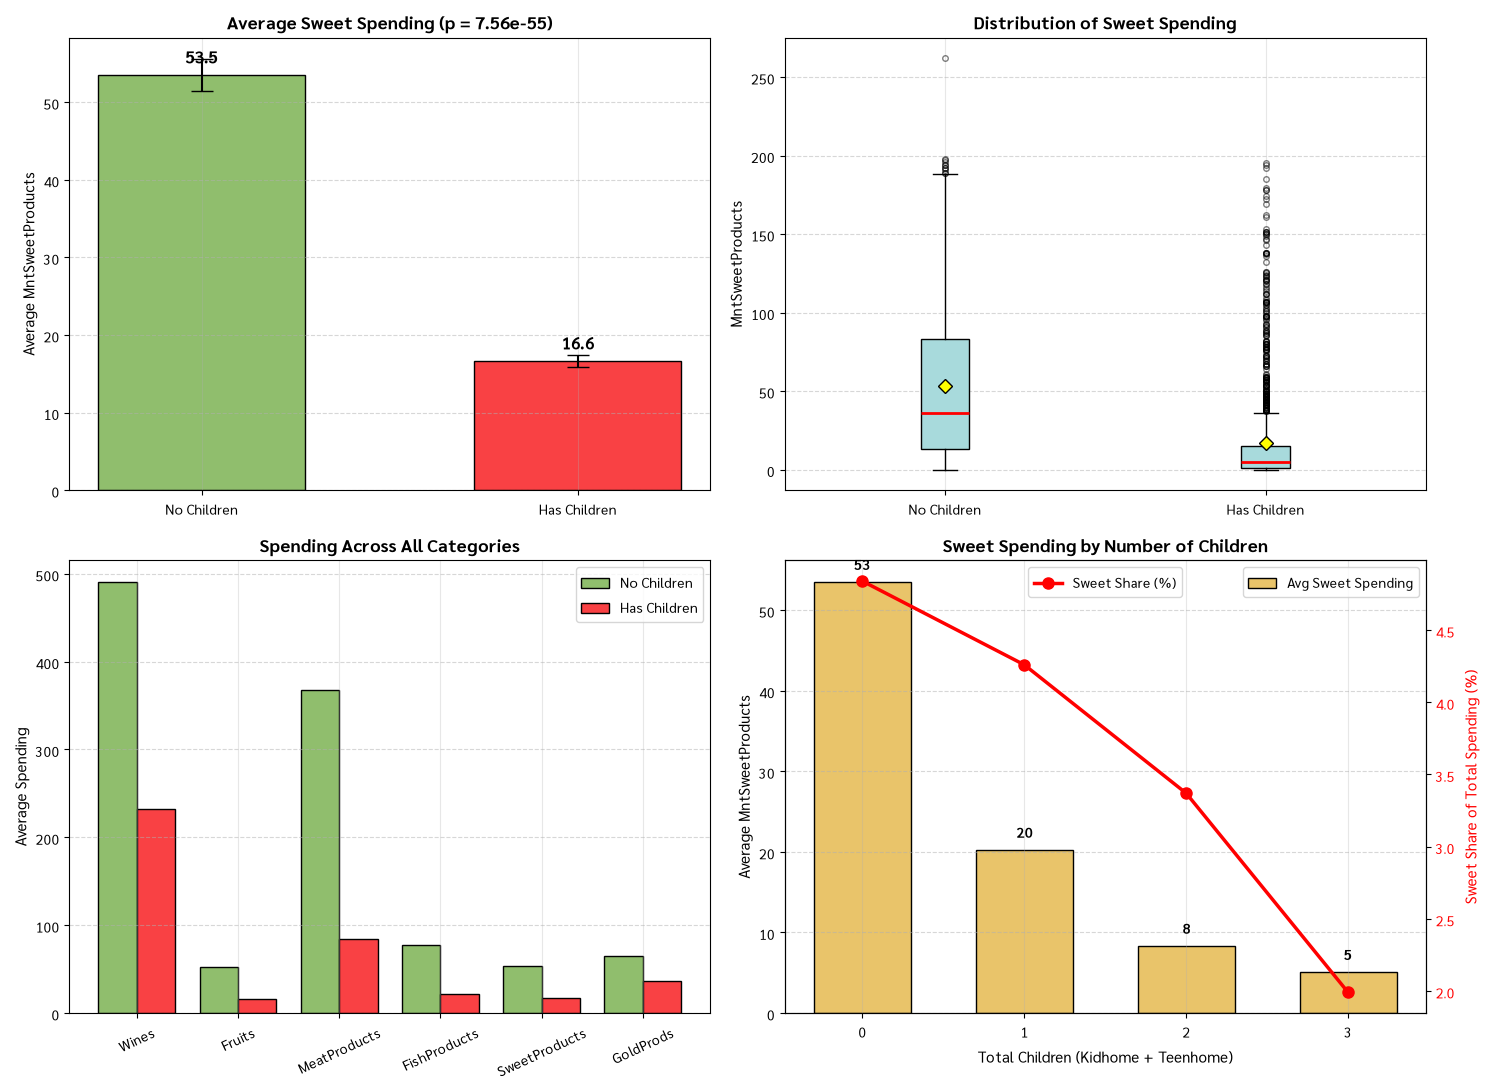

INSIGHT: Family Consumption Patterns
1. ครัวเรือนที่มีบุตรใช้จ่ายขนมหวานน้อยกว่าครัวเรือนที่ไม่มีบุตร 36.9 (68.9%)
   *** ผลลัพธ์ขัดกับสมมติฐานทั่วไปที่ว่า 'บ้านมีเด็กต้องซื้อขนมมากกว่า' ***
2. ความต่างมีนัยสำคัญทางสถิติ (p = 7.56e-55) และขนาดของผลอยู่ในระดับใหญ่ (Large)
3. รูปแบบนี้เกิดกับ 'ทุกหมวดสินค้า' ไม่ใช่เฉพาะขนมหวาน:
     Wines            :   -52.6%
     Fruits           :   -69.4%
     MeatProducts     :   -76.9%
     FishProducts     :   -71.3%
     SweetProducts    :   -68.9%
     GoldProds        :   -44.1%
   -> แสดงว่าสาเหตุไม่ใช่ 'ความชอบขนมหวาน' แต่เป็น 'กำลังซื้อโดยรวม'
4. รายได้เฉลี่ย: มีบุตร 46,257 vs ไม่มีบุตร 65,094
   ครัวเรือนที่มีบุตรมีภาระค่าใช้จ่ายอื่น (การศึกษา, ที่อยู่อาศัย) จึงเหลือ
   งบประมาณสำหรับสินค้าในร้านน้อยลง

ข้อเสนอแนะเชิงธุรกิจ:
  - ครัวเรือนมีบุตร: เน้น Family Pack ขนาดใหญ่ราคาต่อหน่วยถูก, คูปองส่วนลด
  - ครัวเรือนไม่มีบุตร: เน้นสินค้าพรีเมียม คุณภาพสูง ราคาต่อหน่วยสูง
  - ไม่ควรสมมติว่า 'บ้านมีเด็ก = ตลาดขนมหวาน' เพราะข้อมูลไม่สนับสนุน

ข้อจำ

In [59]:
# =============================================================================
# Exercise 25: Children in Household vs Sweet Spending
# =============================================================================
from scipy import stats

# --- แบ่ง 2 กลุ่มด้วย Boolean Indexing ---
with_kids = df[df["Total_Children"] > 0]
no_kids = df[df["Total_Children"] == 0]

col = "MntSweetProducts"

# ----- ขั้นที่ 1: เทียบค่าเฉลี่ยและค่ากลาง -----
print("=" * 80)
print("เปรียบเทียบยอดใช้จ่ายขนมหวาน: มีบุตร vs ไม่มีบุตร")
print("=" * 80)
print(f"{'':<22} {'มีบุตร':>14} {'ไม่มีบุตร':>14}")
print("-" * 80)
print(f"{'จำนวนลูกค้า (n)':<22} {len(with_kids):>14,} {len(no_kids):>14,}")
print(f"{'ค่าเฉลี่ย (Mean)':<22} {with_kids[col].mean():>14.2f} {no_kids[col].mean():>14.2f}")
print(f"{'ค่ากลาง (Median)':<22} {with_kids[col].median():>14.2f} {no_kids[col].median():>14.2f}")
print(f"{'ส่วนเบี่ยงเบน (Std)':<22} {with_kids[col].std():>14.2f} {no_kids[col].std():>14.2f}")
print(f"{'ค่าสูงสุด (Max)':<22} {with_kids[col].max():>14.2f} {no_kids[col].max():>14.2f}")

diff = with_kids[col].mean() - no_kids[col].mean()
print("-" * 80)
print(f"ส่วนต่างค่าเฉลี่ย (มีบุตร - ไม่มีบุตร) = {diff:+.2f} "
      f"({diff/no_kids[col].mean()*100:+.2f}%)")

# ----- ขั้นที่ 2: ทดสอบนัยสำคัญและ Effect Size -----
t_stat, p_t = stats.ttest_ind(with_kids[col], no_kids[col], equal_var=False)
u_stat, p_u = stats.mannwhitneyu(with_kids[col], no_kids[col], alternative="two-sided")

# Cohen's d — วัดขนาดของผล
n1, n2 = len(with_kids), len(no_kids)
s1, s2 = with_kids[col].std(), no_kids[col].std()
pooled_std = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
cohens_d = diff / pooled_std

print("\n" + "=" * 80)
print("การทดสอบทางสถิติ")
print("=" * 80)
print(f"Welch's t-test    : t = {t_stat:>8.4f}, p = {p_t:.3e}")
print(f"Mann-Whitney U    : U = {u_stat:>10.1f}, p = {p_u:.3e}  (ไม่สมมติการแจกแจง)")
print(f"Cohen's d         : d = {cohens_d:>8.4f}")

abs_d = abs(cohens_d)
if abs_d < 0.2:
    d_txt = "เล็กมาก (Negligible)"
elif abs_d < 0.5:
    d_txt = "เล็ก (Small)"
elif abs_d < 0.8:
    d_txt = "ปานกลาง (Medium)"
else:
    d_txt = "ใหญ่ (Large)"
print(f"ขนาดของผล (Effect Size) : {d_txt}")
print(f"นัยสำคัญทางสถิติ        : {'มีนัยสำคัญ (p < 0.05)' if p_t < 0.05 else 'ไม่มีนัยสำคัญ'}")

# ----- ขั้นที่ 3: ขยายผล — ดูทุกหมวดสินค้า ไม่ใช่แค่ขนมหวาน -----
mnt_cols = ["MntWines", "MntFruits", "MntMeatProducts",
            "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
compare_all = pd.DataFrame({
    "มีบุตร": with_kids[mnt_cols].mean(),
    "ไม่มีบุตร": no_kids[mnt_cols].mean(),
}).round(2)
compare_all["ส่วนต่าง"] = (compare_all["มีบุตร"] - compare_all["ไม่มีบุตร"]).round(2)
compare_all["ส่วนต่าง_%"] = (compare_all["ส่วนต่าง"] / compare_all["ไม่มีบุตร"] * 100).round(2)

print("\n" + "=" * 80)
print("ขยายผล: เทียบยอดใช้จ่ายทุกหมวดสินค้า")
print("=" * 80)
print(compare_all.to_string())

# --- ดูละเอียดตามจำนวนบุตร ---
by_n = df.groupby("Total_Children").agg(
    n=(col, "count"),
    avg_sweet=(col, "mean"),
    avg_total=("Total_Spending", "mean"),
    avg_income=("Income", "mean"),
).round(2)
by_n["sweet_share_%"] = (by_n["avg_sweet"] / by_n["avg_total"] * 100).round(2)

print("\nแยกตามจำนวนบุตร:")
print(by_n.to_string())

# ----- ขั้นที่ 4: Visualize 4 แผง -----
fig, ax = plt.subplots(2, 2, figsize=(15, 11))

# แผง (0,0): Bar เทียบ 2 กลุ่ม พร้อม Error Bar (SEM)
groups = ["No Children", "Has Children"]
means = [no_kids[col].mean(), with_kids[col].mean()]
sems = [no_kids[col].sem(), with_kids[col].sem()]
bars = ax[0, 0].bar(groups, means, yerr=sems, capsize=8,
                    color=["#90BE6D", "#F94144"], edgecolor="black", width=0.55)
for bar, v in zip(bars, means):
    ax[0, 0].text(bar.get_x() + bar.get_width()/2, v + 1.5, f"{v:.1f}",
                  ha="center", fontsize=12, fontweight="bold")
ax[0, 0].set_title(f"Average Sweet Spending (p = {p_t:.2e})", fontsize=13, fontweight="bold")
ax[0, 0].set_ylabel("Average MntSweetProducts", fontsize=11)
ax[0, 0].grid(axis="y", linestyle="--", alpha=0.5)

# แผง (0,1): Box Plot — เห็นการกระจายตัวและ Outlier
ax[0, 1].boxplot([no_kids[col], with_kids[col]], tick_labels=groups,
                 patch_artist=True, showmeans=True,
                 boxprops=dict(facecolor="#A8DADC", color="black"),
                 medianprops=dict(color="red", linewidth=2),
                 meanprops=dict(marker="D", markerfacecolor="yellow",
                                markeredgecolor="black", markersize=7),
                 flierprops=dict(marker="o", markersize=4, alpha=0.5))
ax[0, 1].set_title("Distribution of Sweet Spending", fontsize=13, fontweight="bold")
ax[0, 1].set_ylabel("MntSweetProducts", fontsize=11)
ax[0, 1].grid(axis="y", linestyle="--", alpha=0.5)

# แผง (1,0): เทียบทุกหมวดสินค้า
x = np.arange(len(mnt_cols))
w = 0.38
ax[1, 0].bar(x - w/2, compare_all["ไม่มีบุตร"], w, label="No Children",
             color="#90BE6D", edgecolor="black")
ax[1, 0].bar(x + w/2, compare_all["มีบุตร"], w, label="Has Children",
             color="#F94144", edgecolor="black")
ax[1, 0].set_xticks(x)
ax[1, 0].set_xticklabels([c.replace("Mnt", "") for c in mnt_cols], rotation=25)
ax[1, 0].set_title("Spending Across All Categories", fontsize=13, fontweight="bold")
ax[1, 0].set_ylabel("Average Spending", fontsize=11)
ax[1, 0].legend()
ax[1, 0].grid(axis="y", linestyle="--", alpha=0.5)

# แผง (1,1): แนวโน้มตามจำนวนบุตร
ax2 = ax[1, 1]
n_idx = by_n.index.astype(str)
bars4 = ax2.bar(n_idx, by_n["avg_sweet"], color="#E9C46A",
                edgecolor="black", width=0.6, label="Avg Sweet Spending")
for bar, v in zip(bars4, by_n["avg_sweet"]):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 1.5, f"{v:.0f}",
             ha="center", fontsize=10, fontweight="bold")
ax2.set_title("Sweet Spending by Number of Children", fontsize=13, fontweight="bold")
ax2.set_xlabel("Total Children (Kidhome + Teenhome)", fontsize=11)
ax2.set_ylabel("Average MntSweetProducts", fontsize=11)
ax2.grid(axis="y", linestyle="--", alpha=0.5)
# แกนที่ 2 ซ้อนทับ: สัดส่วนขนมหวานต่อยอดใช้จ่ายรวม
ax3 = ax2.twinx()
ax3.plot(n_idx, by_n["sweet_share_%"], color="red", marker="o",
         linewidth=2.5, markersize=8, label="Sweet Share (%)")
ax3.set_ylabel("Sweet Share of Total Spending (%)", fontsize=11, color="red")
ax3.tick_params(axis="y", labelcolor="red")
ax3.grid(False)
ax2.legend(loc="upper right"); ax3.legend(loc="upper center")

plt.tight_layout()
plt.show()

# ----- สรุป Insight -----
print("=" * 80)
print("INSIGHT: Family Consumption Patterns")
print("=" * 80)
direction = "มากกว่า" if diff > 0 else "น้อยกว่า"
print(f"1. ครัวเรือนที่มีบุตรใช้จ่ายขนมหวาน{direction}ครัวเรือนที่ไม่มีบุตร "
      f"{abs(diff):.1f} ({abs(diff)/no_kids[col].mean()*100:.1f}%)")
if diff < 0:
    print("   *** ผลลัพธ์ขัดกับสมมติฐานทั่วไปที่ว่า 'บ้านมีเด็กต้องซื้อขนมมากกว่า' ***")
print(f"2. ความต่างมีนัยสำคัญทางสถิติ (p = {p_t:.2e}) และขนาดของผลอยู่ในระดับ{d_txt}")
print(f"3. รูปแบบนี้เกิดกับ 'ทุกหมวดสินค้า' ไม่ใช่เฉพาะขนมหวาน:")
for c in mnt_cols:
    print(f"     {c.replace('Mnt',''):<16} : {compare_all.loc[c, 'ส่วนต่าง_%']:>+7.1f}%")
print("   -> แสดงว่าสาเหตุไม่ใช่ 'ความชอบขนมหวาน' แต่เป็น 'กำลังซื้อโดยรวม'")
print(f"4. รายได้เฉลี่ย: มีบุตร {with_kids['Income'].mean():,.0f} vs "
      f"ไม่มีบุตร {no_kids['Income'].mean():,.0f}")
print("   ครัวเรือนที่มีบุตรมีภาระค่าใช้จ่ายอื่น (การศึกษา, ที่อยู่อาศัย) จึงเหลือ")
print("   งบประมาณสำหรับสินค้าในร้านน้อยลง")

print("\nข้อเสนอแนะเชิงธุรกิจ:")
print("  - ครัวเรือนมีบุตร: เน้น Family Pack ขนาดใหญ่ราคาต่อหน่วยถูก, คูปองส่วนลด")
print("  - ครัวเรือนไม่มีบุตร: เน้นสินค้าพรีเมียม คุณภาพสูง ราคาต่อหน่วยสูง")
print("  - ไม่ควรสมมติว่า 'บ้านมีเด็ก = ตลาดขนมหวาน' เพราะข้อมูลไม่สนับสนุน")
print("\nข้อจำกัด: ข้อมูลนี้วัดเฉพาะการซื้อ 'ในร้านนี้' ครัวเรือนมีบุตรอาจซื้อขนม")
print("          จากร้านสะดวกซื้อหรือช่องทางอื่นที่ข้อมูลชุดนี้มองไม่เห็น")

---

## Exercise 26 — High-value Customers

> **โจทย์:** Identify customers with the highest combined spending `MntWines` + `MntMeatProducts` + `MntGoldProds`. What characteristics (age, marital, education) do they share?

**วัตถุประสงค์:** ระบุลูกค้ามูลค่าสูง และหาลักษณะร่วมของกลุ่มนี้

### การสร้างตัวชี้วัดรวม (Composite Metric)

```python
df["High_Value_Spending"] = df["MntWines"] + df["MntMeatProducts"] + df["MntGoldProds"]
```

3 หมวดนี้เป็นสินค้า **กำไรต่อหน่วยสูง** (ไวน์, เนื้อคุณภาพ, สินค้าพรีเมียม) จึงสะท้อนมูลค่าลูกค้าได้ดีกว่ายอดขายรวม

### การหา "ลักษณะร่วม" อย่างถูกวิธี — ต้องเทียบกับกลุ่มอ้างอิง

การบอกว่า "ลูกค้ามูลค่าสูง 60% เป็นคนแต่งงานแล้ว" **ยังไม่ใช่ Insight** เพราะถ้าฐานลูกค้าทั้งหมดก็มี
คนแต่งงาน 60% อยู่แล้ว ตัวเลขนี้ก็ไม่ได้บอกอะไรเลย

สิ่งที่ต้องคำนวณคือ **Over-representation Index** (เหมือน Lift)

```
Index = สัดส่วนในกลุ่มมูลค่าสูง / สัดส่วนในฐานลูกค้าทั้งหมด
```

| ค่า Index | ความหมาย |
|-----------|----------|
| `> 1.2` | กลุ่มนี้**พบมากเกินคาด** ในกลุ่มมูลค่าสูง → เป็นลักษณะร่วมจริง |
| `≈ 1.0` | พบตามสัดส่วนปกติ → ไม่ใช่ลักษณะเฉพาะ |
| `< 0.8` | พบ**น้อยกว่าคาด** → กลุ่มนี้มักไม่ใช่ลูกค้ามูลค่าสูง |

### การกำหนดเกณฑ์ "มูลค่าสูง"

ใช้ **Percentile** (เช่น Top 10%) ดีกว่าตัวเลขคงที่ เพราะปรับตามการกระจายตัวของข้อมูลจริงเสมอ

การระบุลูกค้ามูลค่าสูง (High-value Customers)
ตัวชี้วัด : MntWines + MntMeatProducts + MntGoldProds
เกณฑ์     : Top 10% (>= 1,316)
จำนวน     : 222 ราย จาก 2,205 ราย
ยอดใช้จ่ายรวมของกลุ่มนี้ : 355,051 (31.2% ของยอดรวมทั้งระบบ)

Top 20 ลูกค้ามูลค่าสูงสุด:
  No  Age  Income  Education  Marital  High_Value_Spending  MntWines  MntMeatProducts  MntGoldProds  Total_Accepted  Response
 968   51   75759 Graduation  Married                 2284      1394              708           182               3         1
1033   71   69098        PhD  Married                 2273      1315              780           178               0         0
1160   29   90638     Master   Single                 2167      1156              915            96               1         0
1548   29   90638     Master   Single                 2167      1156              915            96               1         1
1468   32   87679 Graduation Together                 2107      1259              815            33               3 

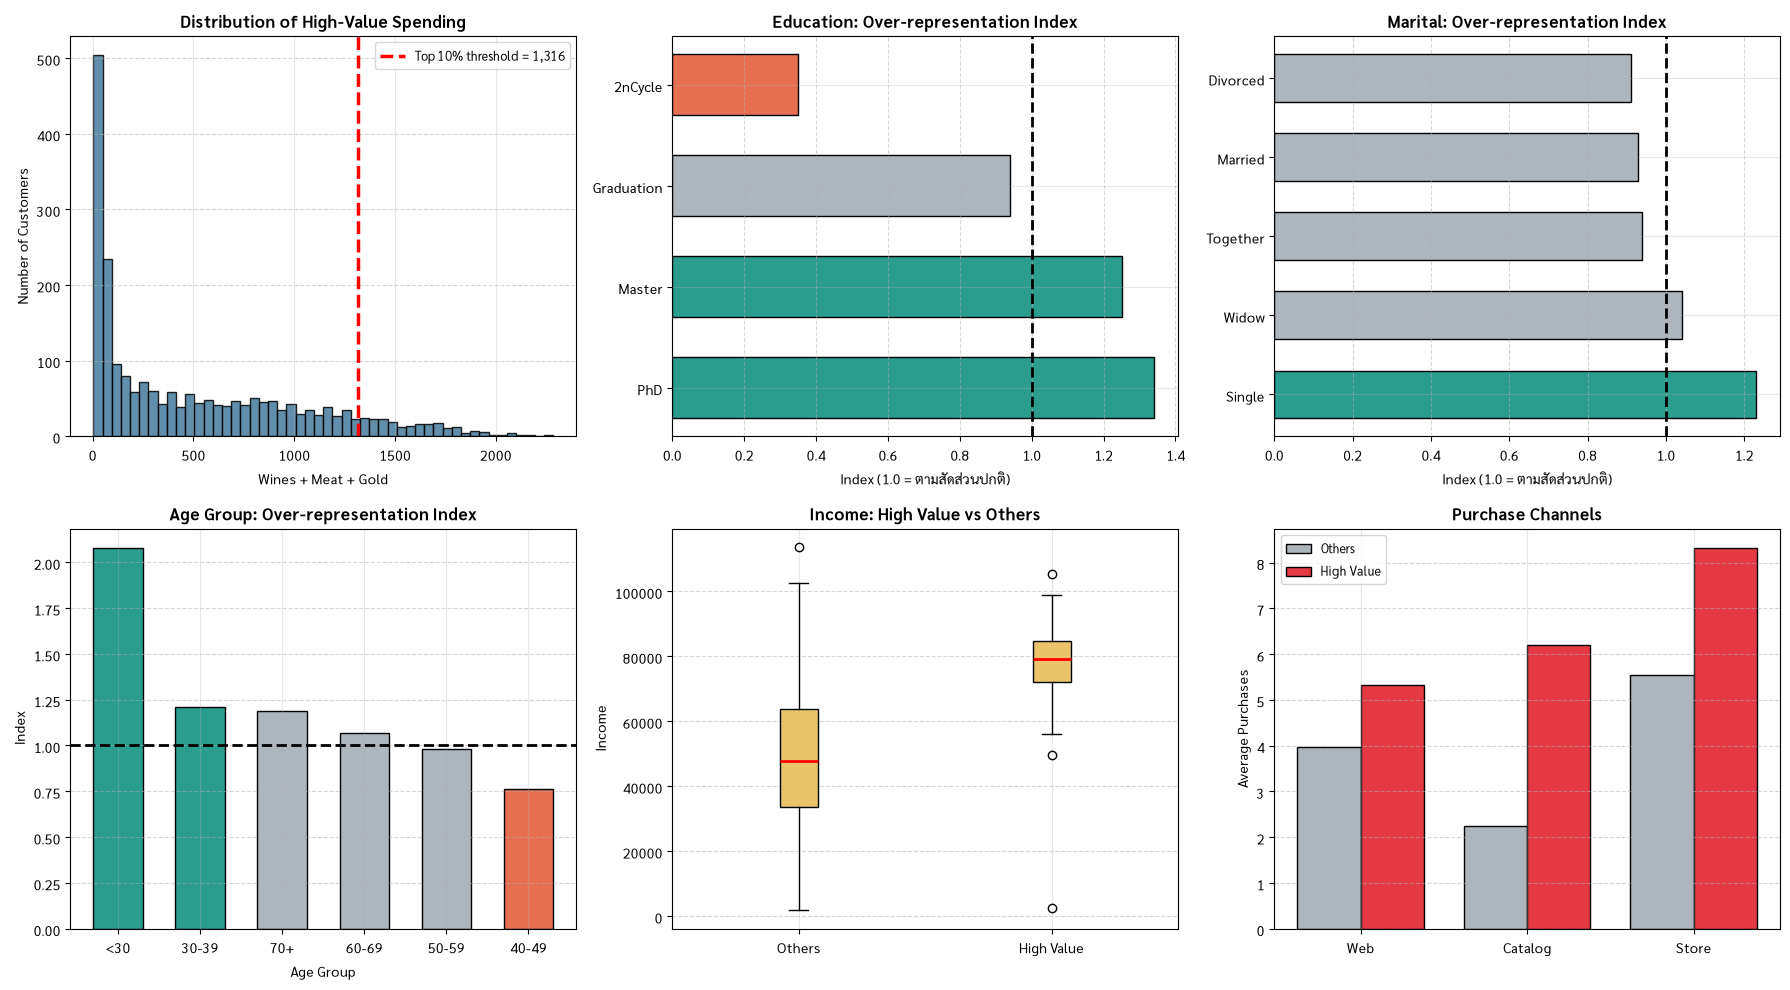

INSIGHT: What do High-value Customers Share?
1. ลูกค้า Top 10% (222 ราย) สร้างยอดใช้จ่ายสินค้ากำไรสูงถึง 31.2%
   -> ยืนยันหลัก Pareto: ลูกค้ากลุ่มเล็กสร้างมูลค่าสัดส่วนใหญ่

2. ลักษณะร่วมเชิงตัวเลข (เรียงตามความแตกต่างมากสุด):
     Total_Accepted         : HV =      1.19  vs อื่น =      0.20  (5.95 เท่า)
     NumCatalogPurchases    : HV =      6.20  vs อื่น =      2.25  (2.76 เท่า)
     Income                 : HV = 78,500.98  vs อื่น = 48,612.96  (1.61 เท่า)
     NumStorePurchases      : HV =      8.32  vs อื่น =      5.54  (1.50 เท่า)
     NumWebPurchases        : HV =      5.32  vs อื่น =      3.96  (1.34 เท่า)

3. ลักษณะร่วมเชิงหมวดหมู่ (Index > 1.2 = พบมากเกินคาด):
     Education      = PhD              Index = 1.34
     Education      = Master           Index = 1.25
     Marital        = Single           Index = 1.23
     Age_Group      = <30              Index = 2.08
     Age_Group      = 30-39            Index = 1.21

4. พฤติกรรมการซื้อ: กลุ่ม HV ซื้อผ่านแคตตาล็อกมากกว่ากลุ่มอ

In [60]:
# =============================================================================
# Exercise 26: High-value Customers — Shared Characteristics
# =============================================================================

# ----- ขั้นที่ 1: สร้างตัวชี้วัดมูลค่าลูกค้า -----
hv_cols = ["MntWines", "MntMeatProducts", "MntGoldProds"]
df["High_Value_Spending"] = df[hv_cols].sum(axis=1)

# --- กำหนดเกณฑ์ Top 10% ด้วย Percentile ---
threshold = df["High_Value_Spending"].quantile(0.90)
df["Is_High_Value"] = df["High_Value_Spending"] >= threshold

hv = df[df["Is_High_Value"]]        # กลุ่มมูลค่าสูง
others = df[~df["Is_High_Value"]]   # กลุ่มเปรียบเทียบ

print("=" * 80)
print("การระบุลูกค้ามูลค่าสูง (High-value Customers)")
print("=" * 80)
print(f"ตัวชี้วัด : MntWines + MntMeatProducts + MntGoldProds")
print(f"เกณฑ์     : Top 10% (>= {threshold:,.0f})")
print(f"จำนวน     : {len(hv):,} ราย จาก {len(df):,} ราย")
print(f"ยอดใช้จ่ายรวมของกลุ่มนี้ : {hv['High_Value_Spending'].sum():,.0f} "
      f"({hv['High_Value_Spending'].sum()/df['High_Value_Spending'].sum()*100:.1f}% "
      "ของยอดรวมทั้งระบบ)")

# --- Top 20 รายแรก ---
show_cols = ["No", "Age", "Income", "Education", "Marital",
             "High_Value_Spending", "MntWines", "MntMeatProducts",
             "MntGoldProds", "Total_Accepted", "Response"]
print("\nTop 20 ลูกค้ามูลค่าสูงสุด:")
print(df.nlargest(20, "High_Value_Spending")[show_cols].to_string(index=False))

# ----- ขั้นที่ 2: ลักษณะเชิงตัวเลข -----
num_cols = ["Age", "Income", "Recency", "Customer_Days", "Total_Children",
            "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",
            "NumWebVisitsMonth", "NumDealsPurchases", "Total_Accepted"]
num_profile = pd.DataFrame({
    "High_Value": hv[num_cols].mean(),
    "Others": others[num_cols].mean(),
}).round(2)
num_profile["Index"] = (num_profile["High_Value"] / num_profile["Others"]).round(2)
num_profile = num_profile.sort_values("Index", ascending=False)

print("\n" + "=" * 80)
print("ลักษณะเชิงตัวเลข: High-value vs ลูกค้าอื่น")
print("=" * 80)
print(num_profile.to_string())

# ----- ขั้นที่ 3: ลักษณะเชิงหมวดหมู่ — ใช้ Over-representation Index -----
def over_rep(col):
    """คำนวณสัดส่วนในกลุ่มมูลค่าสูง เทียบกับฐานลูกค้าทั้งหมด"""
    hv_pct = hv[col].value_counts(normalize=True) * 100
    all_pct = df[col].value_counts(normalize=True) * 100
    out = pd.DataFrame({"ในกลุ่ม_HV_%": hv_pct, "ในฐานลูกค้า_%": all_pct}).round(2)
    out["Index"] = (out["ในกลุ่ม_HV_%"] / out["ในฐานลูกค้า_%"]).round(2)
    return out.sort_values("Index", ascending=False)

for col in ["Education", "Marital", "Age_Group", "Income_Quartile"]:
    print("\n" + "=" * 70)
    print(f"Over-representation Index — {col}")
    print("=" * 70)
    tbl = over_rep(col)
    print(tbl.to_string())
    strong = tbl[tbl["Index"] > 1.2]
    if len(strong) > 0:
        print(f"  -> พบมากเกินคาด (Index > 1.2): {list(strong.index.astype(str))}")

# ----- ขั้นที่ 4: Visualize -----
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

# แผง (0,0): Histogram ของ High_Value_Spending + เส้นเกณฑ์
ax[0, 0].hist(df["High_Value_Spending"], bins=50, color="#457B9D",
              edgecolor="black", alpha=0.85)
ax[0, 0].axvline(threshold, color="red", linestyle="--", linewidth=2.5,
                 label=f"Top 10% threshold = {threshold:,.0f}")
ax[0, 0].set_title("Distribution of High-Value Spending", fontsize=12, fontweight="bold")
ax[0, 0].set_xlabel("Wines + Meat + Gold", fontsize=10)
ax[0, 0].set_ylabel("Number of Customers", fontsize=10)
ax[0, 0].legend(fontsize=9)
ax[0, 0].grid(axis="y", linestyle="--", alpha=0.5)

# แผง (0,1): Education — Index
edu_idx = over_rep("Education")
colors = ["#2A9D8F" if v > 1.2 else "#E76F51" if v < 0.8 else "#ADB5BD"
          for v in edu_idx["Index"]]
ax[0, 1].barh(edu_idx.index.astype(str), edu_idx["Index"], color=colors,
              edgecolor="black", height=0.6)
ax[0, 1].axvline(1.0, color="black", linestyle="--", linewidth=2)
ax[0, 1].set_title("Education: Over-representation Index", fontsize=12, fontweight="bold")
ax[0, 1].set_xlabel("Index (1.0 = ตามสัดส่วนปกติ)", fontsize=10)
ax[0, 1].grid(axis="x", linestyle="--", alpha=0.5)

# แผง (0,2): Marital — Index
mar_idx = over_rep("Marital")
colors = ["#2A9D8F" if v > 1.2 else "#E76F51" if v < 0.8 else "#ADB5BD"
          for v in mar_idx["Index"]]
ax[0, 2].barh(mar_idx.index.astype(str), mar_idx["Index"], color=colors,
              edgecolor="black", height=0.6)
ax[0, 2].axvline(1.0, color="black", linestyle="--", linewidth=2)
ax[0, 2].set_title("Marital: Over-representation Index", fontsize=12, fontweight="bold")
ax[0, 2].set_xlabel("Index (1.0 = ตามสัดส่วนปกติ)", fontsize=10)
ax[0, 2].grid(axis="x", linestyle="--", alpha=0.5)

# แผง (1,0): Age Group — Index
age_idx = over_rep("Age_Group")
colors = ["#2A9D8F" if v > 1.2 else "#E76F51" if v < 0.8 else "#ADB5BD"
          for v in age_idx["Index"]]
ax[1, 0].bar(age_idx.index.astype(str), age_idx["Index"], color=colors,
             edgecolor="black", width=0.6)
ax[1, 0].axhline(1.0, color="black", linestyle="--", linewidth=2)
ax[1, 0].set_title("Age Group: Over-representation Index", fontsize=12, fontweight="bold")
ax[1, 0].set_xlabel("Age Group", fontsize=10)
ax[1, 0].set_ylabel("Index", fontsize=10)
ax[1, 0].grid(axis="y", linestyle="--", alpha=0.5)

# แผง (1,1): Box Plot เทียบ Income ของ 2 กลุ่ม
ax[1, 1].boxplot([others["Income"], hv["Income"]],
                 tick_labels=["Others", "High Value"], patch_artist=True,
                 boxprops=dict(facecolor="#E9C46A", color="black"),
                 medianprops=dict(color="red", linewidth=2))
ax[1, 1].set_title("Income: High Value vs Others", fontsize=12, fontweight="bold")
ax[1, 1].set_ylabel("Income", fontsize=10)
ax[1, 1].grid(axis="y", linestyle="--", alpha=0.5)

# แผง (1,2): Channel Mix ของ 2 กลุ่ม
ch = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
x = np.arange(len(ch)); w = 0.38
ax[1, 2].bar(x - w/2, others[ch].mean(), w, label="Others",
             color="#ADB5BD", edgecolor="black")
ax[1, 2].bar(x + w/2, hv[ch].mean(), w, label="High Value",
             color="#E63946", edgecolor="black")
ax[1, 2].set_xticks(x)
ax[1, 2].set_xticklabels(["Web", "Catalog", "Store"])
ax[1, 2].set_title("Purchase Channels", fontsize=12, fontweight="bold")
ax[1, 2].set_ylabel("Average Purchases", fontsize=10)
ax[1, 2].legend(fontsize=9)
ax[1, 2].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# ----- สรุป Insight -----
print("=" * 80)
print("INSIGHT: What do High-value Customers Share?")
print("=" * 80)
print(f"1. ลูกค้า Top 10% ({len(hv):,} ราย) สร้างยอดใช้จ่ายสินค้ากำไรสูงถึง "
      f"{hv['High_Value_Spending'].sum()/df['High_Value_Spending'].sum()*100:.1f}%")
print("   -> ยืนยันหลัก Pareto: ลูกค้ากลุ่มเล็กสร้างมูลค่าสัดส่วนใหญ่\n")
print("2. ลักษณะร่วมเชิงตัวเลข (เรียงตามความแตกต่างมากสุด):")
for m in num_profile.index[:5]:
    print(f"     {m:<22} : HV = {num_profile.loc[m, 'High_Value']:>9,.2f}  "
          f"vs อื่น = {num_profile.loc[m, 'Others']:>9,.2f}  "
          f"({num_profile.loc[m, 'Index']:.2f} เท่า)")
print("\n3. ลักษณะร่วมเชิงหมวดหมู่ (Index > 1.2 = พบมากเกินคาด):")
for col in ["Education", "Marital", "Age_Group"]:
    tbl = over_rep(col)
    strong = tbl[tbl["Index"] > 1.2]
    if len(strong) > 0:
        for k in strong.index:
            print(f"     {col:<14} = {str(k):<16} Index = {strong.loc[k, 'Index']:.2f}")
    else:
        print(f"     {col:<14} : ไม่มีหมวดใดโดดเด่นชัดเจน (ทุก Index อยู่ราว 1.0)")

print(f"\n4. พฤติกรรมการซื้อ: กลุ่ม HV ซื้อผ่านแคตตาล็อกมากกว่ากลุ่มอื่น "
      f"{num_profile.loc['NumCatalogPurchases', 'Index']:.1f} เท่า")
print(f"   และตอบรับแคมเปญมากกว่า {num_profile.loc['Total_Accepted', 'Index']:.1f} เท่า")
print(f"5. ใช้ส่วนลดน้อยกว่าสัดส่วน "
      f"(NumDealsPurchases Index = {num_profile.loc['NumDealsPurchases', 'Index']:.2f})")
print("   -> กลุ่มนี้ไม่อ่อนไหวต่อราคา (Price-insensitive)")

print("\nข้อเสนอแนะเชิงธุรกิจ:")
print("  - สร้าง VIP / Loyalty Tier สำหรับกลุ่มนี้ เน้น 'สิทธิพิเศษ' ไม่ใช่ 'ส่วนลด'")
print("  - ใช้ช่องทางแคตตาล็อกและอีเมลส่วนบุคคล เพราะกลุ่มนี้ตอบสนองดี")
print("  - ทำ Lookalike Targeting จากโปรไฟล์กลุ่มนี้เพื่อหาลูกค้าใหม่")
print("  - เฝ้าระวัง Churn ของกลุ่มนี้เป็นพิเศษ เพราะการเสียลูกค้า 1 รายกระทบรายได้มาก")

---

## Exercise 27 — Campaign Acceptance Patterns

> **โจทย์:** Analyze customers who accepted multiple campaigns `AcceptedCmp1–5`. What demographic or behavioral traits distinguish them?

**วัตถุประสงค์:** วิเคราะห์ลูกค้าที่ตอบรับหลายแคมเปญ และหาลักษณะที่แยกพวกเขาออกจากลูกค้าอื่น

### แนวคิด: Responsiveness เป็นคุณสมบัติของลูกค้า

หากการตอบรับแคมเปญเป็นเพียง **เรื่องสุ่ม** จำนวนแคมเปญที่แต่ละคนตอบรับควรกระจายแบบ Binomial
แต่ถ้าพบว่ามีลูกค้ากลุ่มหนึ่งตอบรับ **หลายแคมเปญซ้ำ ๆ** แสดงว่า "ความพร้อมตอบรับการตลาด"
เป็น **คุณสมบัติติดตัวลูกค้า** (Persistent trait) ไม่ใช่ความบังเอิญ — ซึ่งมีค่ามหาศาลเพราะ **ทำนายได้**

### ตรวจสอบด้วยความสัมพันธ์ระหว่างแคมเปญ

ถ้า Correlation ระหว่างคอลัมน์ `AcceptedCmp1`…`AcceptedCmp5` เป็น **บวก** ทุกคู่
→ ยืนยันว่าคนที่ตอบรับแคมเปญหนึ่งมีแนวโน้มตอบรับแคมเปญอื่นด้วย

### การแบ่งกลุ่มตามระดับการตอบสนอง (Responsiveness Tier)

| Tier | เกณฑ์ | ความหมายทางการตลาด |
|------|-------|---------------------|
| **Non-responder** | 0 แคมเปญ | ไม่เคยตอบรับ — ต้นทุนการตลาดสูญเปล่า |
| **Occasional** | 1 แคมเปญ | ตอบรับเป็นครั้งคราว |
| **Loyal Responder** | 2–3 แคมเปญ | ตอบสนองสม่ำเสมอ |
| **Super Responder** | 4–5 แคมเปญ | ★ กลุ่มทองคำ — ตอบรับแทบทุกครั้ง |

### ตัวชี้วัดที่ต้องคำนวณเพื่อหา "ลักษณะที่แยกกลุ่ม"

ใช้ **Index** (อัตราส่วนต่อกลุ่มอ้างอิง) เหมือน Exercise 26 เพราะค่าเฉลี่ยดิบอย่างเดียวไม่บอกว่า
ความต่างนั้นมากพอจะมีความหมายทางธุรกิจหรือไม่

ความสัมพันธ์ระหว่างการตอบรับแคมเปญต่าง ๆ
              AcceptedCmp1  AcceptedCmp2  AcceptedCmp3  AcceptedCmp4  AcceptedCmp5
AcceptedCmp1         1.000         0.177         0.095         0.243         0.409
AcceptedCmp2         0.177         1.000         0.072         0.295         0.223
AcceptedCmp3         0.095         0.072         1.000        -0.080         0.081
AcceptedCmp4         0.243         0.295        -0.080         1.000         0.312
AcceptedCmp5         0.409         0.223         0.081         0.312         1.000

คู่ที่มี Correlation เป็นบวก: 9 จาก 10 คู่
-> ยืนยันว่าคนที่ตอบรับแคมเปญหนึ่งมีแนวโน้มตอบรับแคมเปญอื่นด้วย
   'ความพร้อมตอบรับการตลาด' เป็นคุณสมบัติติดตัวลูกค้า ไม่ใช่ความสุ่ม

เทียบการกระจายตัวจริง vs แบบสุ่ม (Binomial)
   จริง_%  ถ้าสุ่ม_%  ต่าง
0   79.23      73.44  5.79
1   14.60      23.38 -8.78
2    3.67       2.98  0.69
3    2.00       0.19  1.81
4    0.50       0.01  0.49
5    0.00       0.00  0.00

การที่ค่าจริงของกลุ่ม 2+ แคมเปญสูงกว่าแบบสุ่ม ยืน

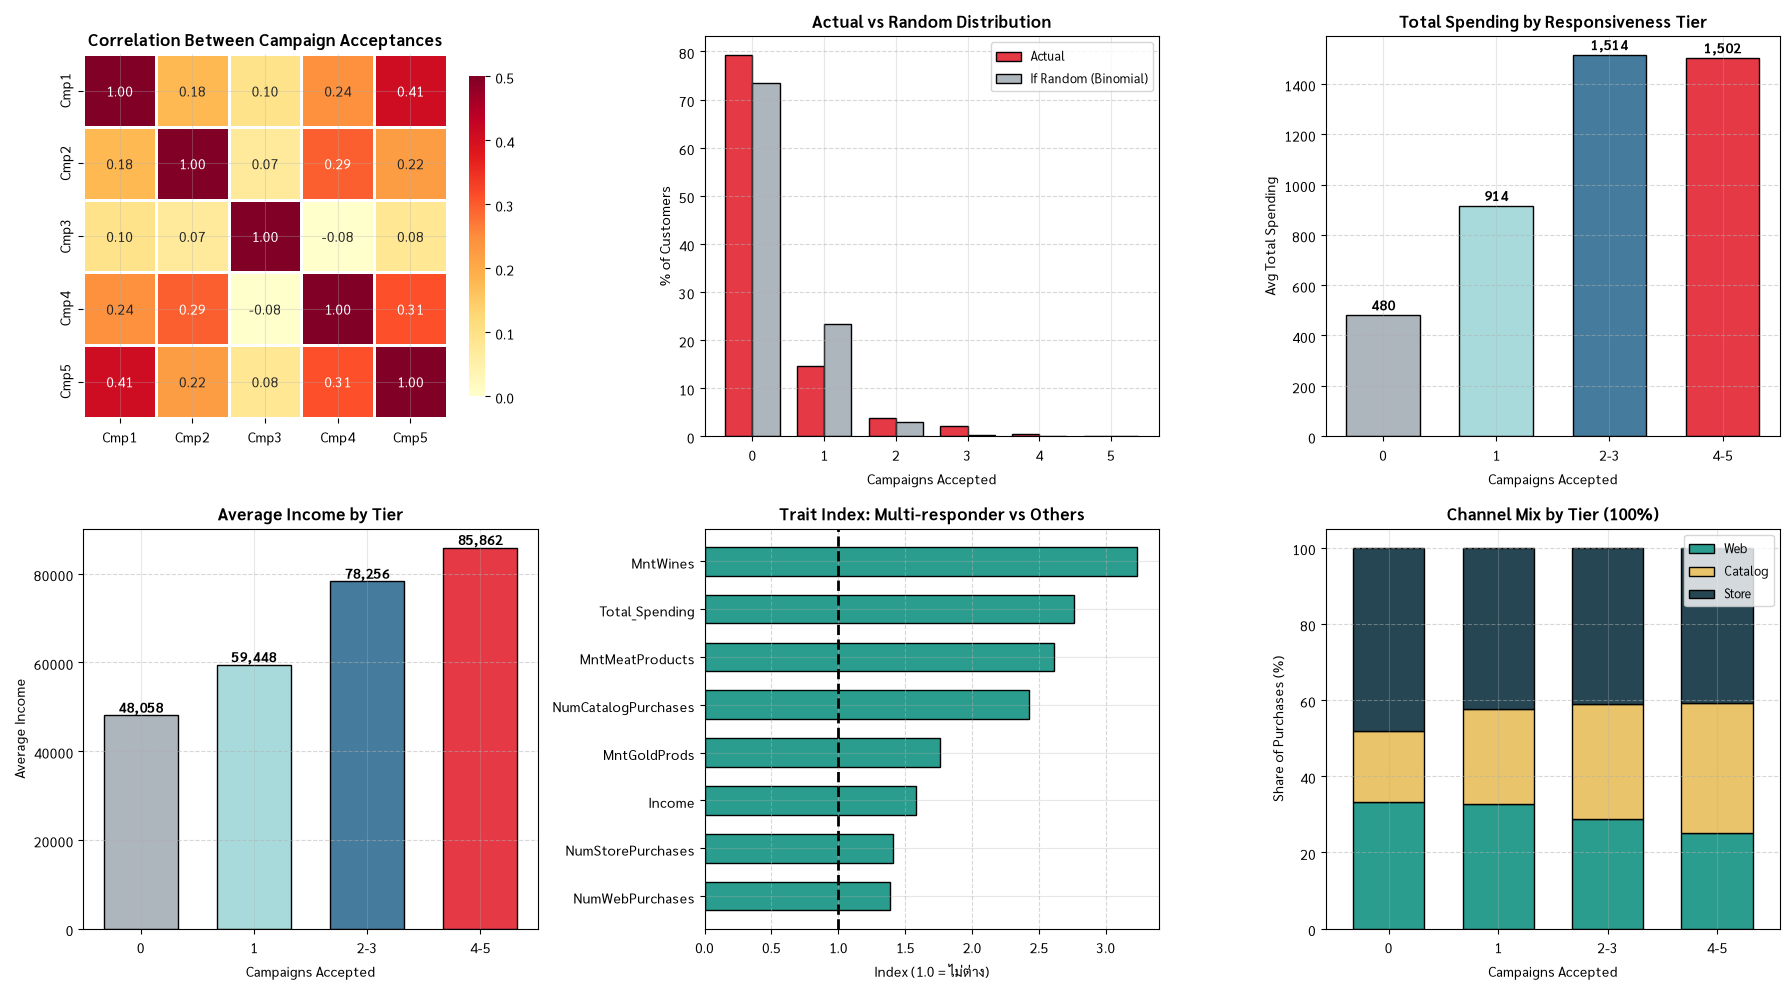

INSIGHT: Traits of Multi-campaign Responders
1. ผู้ตอบรับ >= 2 แคมเปญมีเพียง 136 ราย (6.2% ของฐานลูกค้า)
   แต่สร้างยอดใช้จ่ายรวม 15.4% ของทั้งระบบ
   กลุ่ม Super Responder (4-5 แคมเปญ) มี 11 ราย

2. ลักษณะที่แยกกลุ่มนี้ได้ชัดที่สุด (Index สูงสุด และมีนัยสำคัญ):
     MntWines                 :     870.29 vs     269.08  (3.23 เท่า)
     Total_Spending           :   1,513.02 vs     547.26  (2.77 เท่า)
     MntMeatProducts          :     392.87 vs     150.35  (2.61 เท่า)
     NumCatalogPurchases      :       5.90 vs       2.43  (2.43 เท่า)
     MntGoldProds             :      74.09 vs      42.08  (1.76 เท่า)
     Income                   :  78,870.87 vs  49,830.97  (1.58 เท่า)

3. ลักษณะที่ต่ำกว่ากลุ่มอื่น (Index < 1.0):
     Customer_Days            : Index = 1.00
     Age                      : Index = 0.98
     Recency                  : Index = 0.98
     NumWebVisitsMonth        : Index = 0.69
     NumDealsPurchases        : Index = 0.59
     Total_Children           : Index = 0.35

4

In [61]:
# =============================================================================
# Exercise 27: Campaign Acceptance Patterns — Distinguishing Traits
# =============================================================================
from scipy import stats

cmp_cols = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
            "AcceptedCmp4", "AcceptedCmp5"]

# ----- ขั้นที่ 1: ตรวจสอบว่า Responsiveness เป็นคุณสมบัติติดตัวหรือไม่ -----
cmp_corr = df[cmp_cols].corr()

print("=" * 80)
print("ความสัมพันธ์ระหว่างการตอบรับแคมเปญต่าง ๆ")
print("=" * 80)
print(cmp_corr.round(3).to_string())

pos_pairs = sum(1 for i in range(5) for j in range(i+1, 5) if cmp_corr.iloc[i, j] > 0)
print(f"\nคู่ที่มี Correlation เป็นบวก: {pos_pairs} จาก 10 คู่")
if pos_pairs >= 8:
    print("-> ยืนยันว่าคนที่ตอบรับแคมเปญหนึ่งมีแนวโน้มตอบรับแคมเปญอื่นด้วย")
    print("   'ความพร้อมตอบรับการตลาด' เป็นคุณสมบัติติดตัวลูกค้า ไม่ใช่ความสุ่ม")

# --- เทียบกับการกระจายแบบสุ่ม (Binomial) ---
actual_dist = df["Total_Accepted"].value_counts(normalize=True).sort_index()
p_avg = df[cmp_cols].values.mean()      # อัตราการตอบรับเฉลี่ยต่อแคมเปญ
expected_dist = pd.Series(
    [stats.binom.pmf(k, 5, p_avg) for k in range(6)], index=range(6))

print("\n" + "=" * 80)
print("เทียบการกระจายตัวจริง vs แบบสุ่ม (Binomial)")
print("=" * 80)
cmp_table = pd.DataFrame({
    "จริง_%": (actual_dist * 100).round(2),
    "ถ้าสุ่ม_%": (expected_dist * 100).round(2),
}).fillna(0)
cmp_table["ต่าง"] = (cmp_table["จริง_%"] - cmp_table["ถ้าสุ่ม_%"]).round(2)
print(cmp_table.to_string())
print("\nการที่ค่าจริงของกลุ่ม 2+ แคมเปญสูงกว่าแบบสุ่ม ยืนยันว่ามีกลุ่มลูกค้า")
print("ที่ตอบสนองการตลาดดีกว่าคนทั่วไปอย่างเป็นระบบ")

# ----- ขั้นที่ 2: แบ่ง Responsiveness Tier -----
def tier(n):
    if n == 0:
        return "0 — Non-responder"
    elif n == 1:
        return "1 — Occasional"
    elif n <= 3:
        return "2-3 — Loyal Responder"
    else:
        return "4-5 — Super Responder"

df["Resp_Tier"] = df["Total_Accepted"].apply(tier)
tier_order = ["0 — Non-responder", "1 — Occasional",
              "2-3 — Loyal Responder", "4-5 — Super Responder"]

tier_profile = df.groupby("Resp_Tier").agg(
    n=("No", "count"),
    age=("Age", "mean"),
    income=("Income", "mean"),
    total_spending=("Total_Spending", "mean"),
    wines=("MntWines", "mean"),
    meat=("MntMeatProducts", "mean"),
    recency=("Recency", "mean"),
    customer_days=("Customer_Days", "mean"),
    children=("Total_Children", "mean"),
    web_purch=("NumWebPurchases", "mean"),
    catalog_purch=("NumCatalogPurchases", "mean"),
    store_purch=("NumStorePurchases", "mean"),
    deals=("NumDealsPurchases", "mean"),
    web_visits=("NumWebVisitsMonth", "mean"),
    last_response=("Response", "mean"),
).round(2).loc[tier_order]
tier_profile["pct_of_base"] = (tier_profile["n"] / len(df) * 100).round(2)

print("\n" + "=" * 130)
print("โปรไฟล์ของแต่ละ Responsiveness Tier")
print("=" * 130)
print(tier_profile.to_string())

# ----- ขั้นที่ 3: หาลักษณะที่ "แยกกลุ่ม" ด้วย Index -----
multi = df[df["Total_Accepted"] >= 2]      # ตอบรับหลายแคมเปญ
single_or_none = df[df["Total_Accepted"] < 2]

traits = ["Age", "Income", "Total_Spending", "MntWines", "MntMeatProducts",
          "MntGoldProds", "Recency", "Customer_Days", "Total_Children",
          "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",
          "NumDealsPurchases", "NumWebVisitsMonth"]

trait_cmp = pd.DataFrame({
    "Multi (>=2)": multi[traits].mean(),
    "Others (<2)": single_or_none[traits].mean(),
}).round(2)
trait_cmp["Index"] = (trait_cmp["Multi (>=2)"] / trait_cmp["Others (<2)"]).round(3)

# ทดสอบนัยสำคัญของแต่ละลักษณะ
pvals = []
for t in traits:
    _, p = stats.ttest_ind(multi[t], single_or_none[t], equal_var=False)
    pvals.append(p)
trait_cmp["p_value"] = [f"{p:.2e}" for p in pvals]
trait_cmp["มีนัยสำคัญ"] = ["ใช่" if p < 0.05 else "ไม่" for p in pvals]
trait_cmp = trait_cmp.sort_values("Index", ascending=False)

print("\n" + "=" * 100)
print("ลักษณะที่แยกผู้ตอบรับหลายแคมเปญออกจากลูกค้าอื่น")
print("=" * 100)
print(trait_cmp.to_string())

# --- ลักษณะเชิงหมวดหมู่ ---
print("\n" + "=" * 80)
print("สัดส่วนเชิงหมวดหมู่: Multi-responder vs ฐานลูกค้า")
print("=" * 80)
for col in ["Education", "Marital", "Age_Group"]:
    m_pct = multi[col].value_counts(normalize=True) * 100
    a_pct = df[col].value_counts(normalize=True) * 100
    tbl = pd.DataFrame({"Multi_%": m_pct, "ฐานลูกค้า_%": a_pct}).round(2)
    tbl["Index"] = (tbl["Multi_%"] / tbl["ฐานลูกค้า_%"]).round(2)
    print(f"\n--- {col} ---")
    print(tbl.sort_values("Index", ascending=False).to_string())

# ----- ขั้นที่ 4: Visualize -----
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

# แผง (0,0): Heatmap ความสัมพันธ์ระหว่างแคมเปญ
sns.heatmap(cmp_corr, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=0.5,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            xticklabels=[c.replace("AcceptedCmp", "Cmp") for c in cmp_cols],
            yticklabels=[c.replace("AcceptedCmp", "Cmp") for c in cmp_cols],
            ax=ax[0, 0])
ax[0, 0].set_title("Correlation Between Campaign Acceptances",
                   fontsize=12, fontweight="bold")

# แผง (0,1): จริง vs สุ่ม
x = np.arange(len(cmp_table)); w = 0.38
ax[0, 1].bar(x - w/2, cmp_table["จริง_%"], w, label="Actual",
             color="#E63946", edgecolor="black")
ax[0, 1].bar(x + w/2, cmp_table["ถ้าสุ่ม_%"], w, label="If Random (Binomial)",
             color="#ADB5BD", edgecolor="black")
ax[0, 1].set_xticks(x); ax[0, 1].set_xticklabels(cmp_table.index)
ax[0, 1].set_title("Actual vs Random Distribution", fontsize=12, fontweight="bold")
ax[0, 1].set_xlabel("Campaigns Accepted", fontsize=10)
ax[0, 1].set_ylabel("% of Customers", fontsize=10)
ax[0, 1].legend(fontsize=9)
ax[0, 1].grid(axis="y", linestyle="--", alpha=0.5)

# แผง (0,2): Total Spending ต่อ Tier
t_idx = [t.split(" — ")[0] for t in tier_order]
bars = ax[0, 2].bar(t_idx, tier_profile["total_spending"],
                    color=["#ADB5BD", "#A8DADC", "#457B9D", "#E63946"],
                    edgecolor="black", width=0.65)
for bar, v in zip(bars, tier_profile["total_spending"]):
    ax[0, 2].text(bar.get_x() + bar.get_width()/2, v + 20, f"{v:,.0f}",
                  ha="center", fontsize=10, fontweight="bold")
ax[0, 2].set_title("Total Spending by Responsiveness Tier", fontsize=12, fontweight="bold")
ax[0, 2].set_xlabel("Campaigns Accepted", fontsize=10)
ax[0, 2].set_ylabel("Avg Total Spending", fontsize=10)
ax[0, 2].grid(axis="y", linestyle="--", alpha=0.5)

# แผง (1,0): Income ต่อ Tier
bars = ax[1, 0].bar(t_idx, tier_profile["income"],
                    color=["#ADB5BD", "#A8DADC", "#457B9D", "#E63946"],
                    edgecolor="black", width=0.65)
for bar, v in zip(bars, tier_profile["income"]):
    ax[1, 0].text(bar.get_x() + bar.get_width()/2, v + 600, f"{v:,.0f}",
                  ha="center", fontsize=10, fontweight="bold")
ax[1, 0].set_title("Average Income by Tier", fontsize=12, fontweight="bold")
ax[1, 0].set_xlabel("Campaigns Accepted", fontsize=10)
ax[1, 0].set_ylabel("Average Income", fontsize=10)
ax[1, 0].grid(axis="y", linestyle="--", alpha=0.5)

# แผง (1,1): Index ของลักษณะเชิงตัวเลข
top_traits = trait_cmp.head(8)
colors = ["#2A9D8F" if v > 1.2 else "#E76F51" if v < 0.8 else "#ADB5BD"
          for v in top_traits["Index"]]
ax[1, 1].barh(top_traits.index[::-1], top_traits["Index"][::-1],
              color=colors[::-1], edgecolor="black", height=0.6)
ax[1, 1].axvline(1.0, color="black", linestyle="--", linewidth=2)
ax[1, 1].set_title("Trait Index: Multi-responder vs Others", fontsize=12, fontweight="bold")
ax[1, 1].set_xlabel("Index (1.0 = ไม่ต่าง)", fontsize=10)
ax[1, 1].grid(axis="x", linestyle="--", alpha=0.5)

# แผง (1,2): Channel Mix ต่อ Tier
ch_mix = tier_profile[["web_purch", "catalog_purch", "store_purch"]]
ch_pct = ch_mix.div(ch_mix.sum(axis=1), axis=0) * 100
ch_pct.index = t_idx
ch_pct.plot(kind="bar", stacked=True, ax=ax[1, 2],
            color=["#2A9D8F", "#E9C46A", "#264653"], edgecolor="black", width=0.65)
ax[1, 2].set_title("Channel Mix by Tier (100%)", fontsize=12, fontweight="bold")
ax[1, 2].set_xlabel("Campaigns Accepted", fontsize=10)
ax[1, 2].set_ylabel("Share of Purchases (%)", fontsize=10)
ax[1, 2].legend(["Web", "Catalog", "Store"], fontsize=9)
ax[1, 2].tick_params(axis="x", rotation=0)
ax[1, 2].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# ----- สรุป Insight -----
super_resp = df[df["Total_Accepted"] >= 4]
print("=" * 80)
print("INSIGHT: Traits of Multi-campaign Responders")
print("=" * 80)
print(f"1. ผู้ตอบรับ >= 2 แคมเปญมีเพียง {len(multi):,} ราย "
      f"({len(multi)/len(df)*100:.1f}% ของฐานลูกค้า)")
print(f"   แต่สร้างยอดใช้จ่ายรวม {multi['Total_Spending'].sum()/df['Total_Spending'].sum()*100:.1f}% "
      "ของทั้งระบบ")
print(f"   กลุ่ม Super Responder (4-5 แคมเปญ) มี {len(super_resp)} ราย\n")

print("2. ลักษณะที่แยกกลุ่มนี้ได้ชัดที่สุด (Index สูงสุด และมีนัยสำคัญ):")
sig = trait_cmp[trait_cmp["มีนัยสำคัญ"] == "ใช่"]
for t in sig.index[:6]:
    print(f"     {t:<24} : {sig.loc[t, 'Multi (>=2)']:>10,.2f} vs "
          f"{sig.loc[t, 'Others (<2)']:>10,.2f}  "
          f"({sig.loc[t, 'Index']:.2f} เท่า)")

print("\n3. ลักษณะที่ต่ำกว่ากลุ่มอื่น (Index < 1.0):")
low = trait_cmp[trait_cmp["Index"] < 1.0]
for t in low.index:
    print(f"     {t:<24} : Index = {low.loc[t, 'Index']:.2f}")

print(f"\n4. Recency: กลุ่ม Multi = {multi['Recency'].mean():.1f} วัน vs "
      f"อื่น = {single_or_none['Recency'].mean():.1f} วัน")
print("   -> กลุ่มนี้ซื้อล่าสุดใกล้กว่า = ยัง Active อยู่ในระบบ")
print(f"5. Response ต่อแคมเปญล่าสุด: Multi = {multi['Response'].mean()*100:.1f}% vs "
      f"อื่น = {single_or_none['Response'].mean()*100:.1f}%")
print("   -> ประวัติการตอบรับในอดีตทำนายการตอบรับในอนาคตได้ดีที่สุด")

print("\nข้อเสนอแนะเชิงธุรกิจ:")
print("  - ใช้ 'จำนวนแคมเปญที่ตอบรับในอดีต' เป็น Feature หลักของ Propensity Model")
print("  - ส่งแคมเปญใหม่ให้กลุ่ม Multi-responder ก่อน เพื่อได้ ROI สูงสุด")
print("  - กลุ่ม Non-responder (0 แคมเปญ) ควรลดความถี่การส่ง เพื่อประหยัดต้นทุน")
print("    และลดความเสี่ยงถูกมองเป็น Spam")
print("  - ทำ A/B Test กับกลุ่ม Non-responder ด้วยข้อเสนอรูปแบบใหม่ เพื่อหาสาเหตุ")

---

## Exercise 28 — Recency vs Spending

> **โจทย์:** Explore the relationship between `Recency` (days since last purchase) and total spending. Do recent buyers tend to spend more?

**วัตถุประสงค์:** สำรวจความสัมพันธ์ระหว่างความใหม่ของการซื้อกับยอดใช้จ่ายรวม

### Recency คือหัวใจของโมเดล RFM

**RFM Model** เป็นกรอบวิเคราะห์มูลค่าลูกค้าที่ใช้กันแพร่หลายที่สุดในวงการค้าปลีก

| ตัวอักษร | ชื่อเต็ม | คอลัมน์ในชุดข้อมูลนี้ |
|----------|---------|------------------------|
| **R** | **Recency** — ซื้อล่าสุดเมื่อไร | `Recency` |
| **F** | **Frequency** — ซื้อบ่อยแค่ไหน | `NumWeb + NumCatalog + NumStore` |
| **M** | **Monetary** — ใช้จ่ายเท่าไร | ผลรวม `Mnt*` ทุกหมวด |

> **สำคัญ:** `Recency` ค่า**น้อย**หมายถึงซื้อ**เร็ว ๆ นี้** (ดี) — ทิศทางตรงข้ามกับตัวชี้วัดอื่น
> ดังนั้นถ้า "ซื้อใหม่ = ใช้จ่ายมาก" จริง จะต้องได้ Correlation เป็น **ลบ**

### การตีความผลที่อาจขัดความคาดหมาย

ในชุดข้อมูลที่เก็บในช่วงเวลาจำกัด (Snapshot) `Recency` อาจ**ไม่**สัมพันธ์กับยอดใช้จ่าย เพราะ

1. `Recency` วัดแค่ **ครั้งล่าสุดครั้งเดียว** ไม่ได้สะท้อนความถี่ทั้งช่วง
2. ยอดใช้จ่ายใน `Mnt*` เป็นผลรวม **2 ปี** ซึ่งเป็นช่วงเวลาต่างกันกับ Recency
3. ถ้าข้อมูลถูกสุ่มเลือกมาแล้ว (Sampled) ความสัมพันธ์ตามธรรมชาติอาจถูกลดทอน

การพบว่า "ไม่สัมพันธ์" ก็เป็นผลลัพธ์ที่มีค่า — บอกว่า **ไม่ควรใช้ Recency ตัวเดียว** ตัดสินมูลค่าลูกค้า

ความสัมพันธ์ระหว่าง Recency และ Total Spending
หมายเหตุ: Recency น้อย = ซื้อเร็ว ๆ นี้ ดังนั้นถ้า 'ซื้อใหม่ใช้จ่ายมาก' -> r ควรเป็นลบ

Pearson  r =   0.0218  (p = 0.3057)
Spearman r =   0.0210  (p = 0.3251)

สรุป: แทบไม่มีความสัมพันธ์เชิงเส้น
นัยสำคัญ: ไม่มีนัยสำคัญ (p >= 0.05)

Correlation ของ Recency กับแต่ละหมวดสินค้า:
  MntWines             : r =  0.0165 (p = 0.4395)  
  MntFruits            : r = -0.0049 (p = 0.8178)  
  MntMeatProducts      : r =  0.0261 (p = 0.2199)  
  MntFishProducts      : r =  0.0012 (p = 0.9559)  
  MntSweetProducts     : r =  0.0255 (p = 0.2307)  
  MntGoldProds         : r =  0.0186 (p = 0.3838)  
  Total_Spending       : r =  0.0218 (p = 0.3057)  
  Total_Purchases      : r =  0.0099 (p = 0.6436)  
  Income               : r =  0.0067 (p = 0.7526)  
  (* = มีนัยสำคัญทางสถิติที่ระดับ 0.05)

ยอดใช้จ่ายแยกตามกลุ่ม Recency
                 n  avg_spending  median_spending  avg_purchases  avg_income  response_rate_%
Recency_Group                              

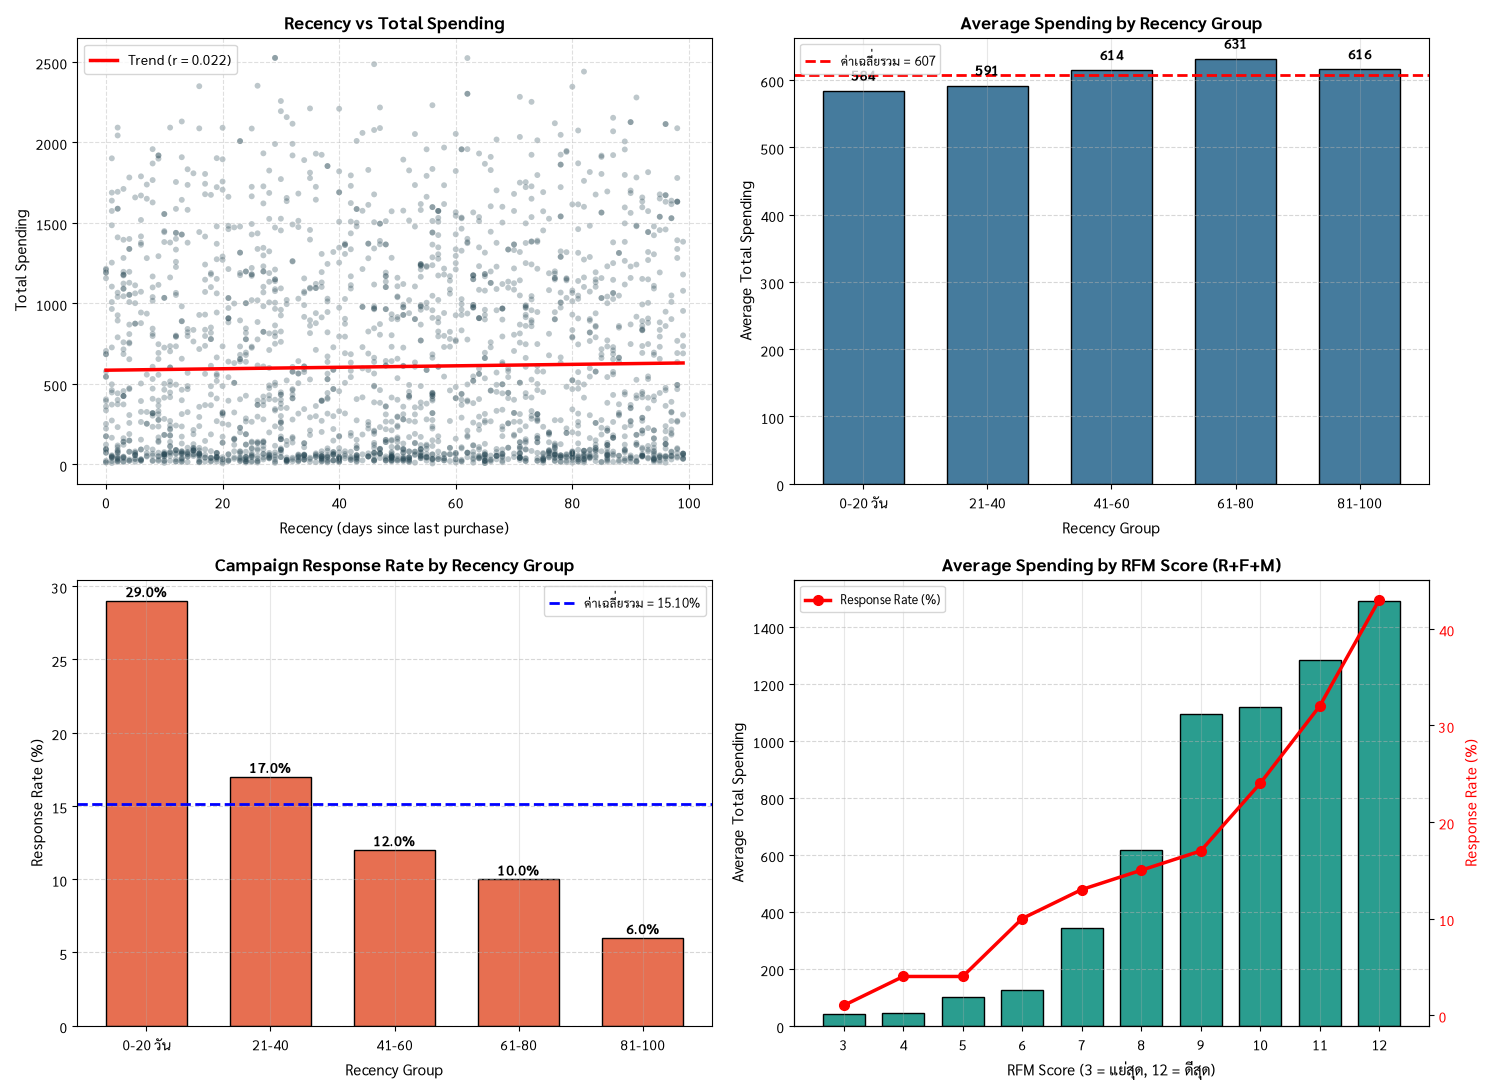

INSIGHT: Do recent buyers spend more?
1. คำตอบ: ไม่ — Recency กับยอดใช้จ่ายรวม มีความสัมพันธ์เพียง r = 0.0218
   แทบไม่มีความสัมพันธ์เชิงเส้น — ขัดกับสมมติฐานที่คาดไว้
2. ค่าเฉลี่ยยอดใช้จ่ายของทุกกลุ่ม Recency ใกล้เคียงกัน (ต่างกันมากสุด 47)
3. แต่ Response Rate ต่อแคมเปญต่างกันชัดกว่า: 6.0% - 29.0%
   กลุ่ม 0-20 วัน ตอบรับแคมเปญดีที่สุด
4. เมื่อรวมเป็น RFM Score ความสัมพันธ์กับยอดใช้จ่ายแข็งแรงขึ้นมาก (r = 0.7759)
   -> ยืนยันว่าต้องใช้หลายมิติร่วมกัน ไม่ใช่ Recency ตัวเดียว

เหตุผลที่ Recency ไม่สัมพันธ์กับยอดใช้จ่ายในข้อมูลชุดนี้:
  - Recency วัดเฉพาะ 'ครั้งล่าสุดครั้งเดียว' ไม่สะท้อนความถี่ตลอดช่วง
  - ยอดใช้จ่าย Mnt* เป็นผลรวม 2 ปี ซึ่งเป็นกรอบเวลาที่ต่างกัน
  - Recency กระจายค่อนข้างสม่ำเสมอ (0-99 วัน) คล้ายถูกสุ่มมา ไม่มีรูปแบบธรรมชาติ

ข้อเสนอแนะเชิงธุรกิจ:
  - ไม่ควรใช้ Recency ตัวเดียวตัดสินมูลค่าลูกค้า ต้องใช้ RFM ครบ 3 มิติ
  - ใช้ Recency ทำ 'Re-activation Campaign' กับกลุ่มที่ไม่ซื้อนาน (> 74 วัน) แทน
  - ลูกค้า RFM Score สูง (10-12) คือกลุ่มที่ควรรักษาไว้เป็นอันดับแรก


In [62]:
# =============================================================================
# Exercise 28: Recency vs Total Spending — Do recent buyers spend more?
# =============================================================================
from scipy import stats

mnt_cols = ["MntWines", "MntFruits", "MntMeatProducts",
            "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

# ----- ขั้นที่ 1: วัดความสัมพันธ์ -----
r_p, p_p = stats.pearsonr(df["Recency"], df["Total_Spending"])
r_s, p_s = stats.spearmanr(df["Recency"], df["Total_Spending"])

print("=" * 80)
print("ความสัมพันธ์ระหว่าง Recency และ Total Spending")
print("=" * 80)
print("หมายเหตุ: Recency น้อย = ซื้อเร็ว ๆ นี้ ดังนั้นถ้า 'ซื้อใหม่ใช้จ่ายมาก' -> r ควรเป็นลบ\n")
print(f"Pearson  r = {r_p:>8.4f}  (p = {p_p:.4f})")
print(f"Spearman r = {r_s:>8.4f}  (p = {p_s:.4f})")

if abs(r_p) < 0.1:
    verdict = "แทบไม่มีความสัมพันธ์เชิงเส้น"
elif r_p < 0:
    verdict = "ซื้อใหม่ใช้จ่ายมากกว่า (ตามที่คาด)"
else:
    verdict = "ซื้อนานแล้วใช้จ่ายมากกว่า (ขัดกับที่คาด)"
print(f"\nสรุป: {verdict}")
print(f"นัยสำคัญ: {'มีนัยสำคัญ (p < 0.05)' if p_p < 0.05 else 'ไม่มีนัยสำคัญ (p >= 0.05)'}")

# --- ตรวจทุกหมวดสินค้า ---
print("\nCorrelation ของ Recency กับแต่ละหมวดสินค้า:")
for c in mnt_cols + ["Total_Spending", "Total_Purchases", "Income"]:
    r, p = stats.pearsonr(df["Recency"], df[c])
    sig = "*" if p < 0.05 else " "
    print(f"  {c:<20} : r = {r:>7.4f} (p = {p:.4f}) {sig}")
print("  (* = มีนัยสำคัญทางสถิติที่ระดับ 0.05)")

# ----- ขั้นที่ 2: แบ่ง Recency เป็นกลุ่ม เพื่อดูรูปแบบที่ไม่ใช่เส้นตรง -----
df["Recency_Group"] = pd.cut(df["Recency"], bins=[0, 20, 40, 60, 80, 100],
                             labels=["0-20 วัน", "21-40", "41-60", "61-80", "81-100"],
                             include_lowest=True)

rec_group = df.groupby("Recency_Group", observed=True).agg(
    n=("Total_Spending", "count"),
    avg_spending=("Total_Spending", "mean"),
    median_spending=("Total_Spending", "median"),
    avg_purchases=("Total_Purchases", "mean"),
    avg_income=("Income", "mean"),
    response_rate=("Response", "mean"),
).round(2)
rec_group["response_rate_%"] = (rec_group["response_rate"] * 100).round(2)

print("\n" + "=" * 100)
print("ยอดใช้จ่ายแยกตามกลุ่ม Recency")
print("=" * 100)
print(rec_group.drop(columns=["response_rate"]).to_string())

# ----- ขั้นที่ 3: สร้างโมเดล RFM เต็มรูปแบบ -----
# R: Recency น้อย = คะแนนสูง (ใช้ labels กลับทิศ)
df["R_Score"] = pd.qcut(df["Recency"], q=4, labels=[4, 3, 2, 1]).astype(int)
# F: Frequency มาก = คะแนนสูง
df["F_Score"] = pd.qcut(df["Total_Purchases"].rank(method="first"),
                        q=4, labels=[1, 2, 3, 4]).astype(int)
# M: Monetary มาก = คะแนนสูง
df["M_Score"] = pd.qcut(df["Total_Spending"].rank(method="first"),
                        q=4, labels=[1, 2, 3, 4]).astype(int)
df["RFM_Score"] = df["R_Score"] + df["F_Score"] + df["M_Score"]

rfm_summary = df.groupby("RFM_Score").agg(
    n=("No", "count"),
    avg_spending=("Total_Spending", "mean"),
    avg_income=("Income", "mean"),
    response_rate=("Response", "mean"),
).round(2)
rfm_summary["response_rate_%"] = (rfm_summary["response_rate"] * 100).round(2)

print("\n" + "=" * 90)
print("RFM Score (3-12) — รวม Recency + Frequency + Monetary")
print("=" * 90)
print(rfm_summary.drop(columns=["response_rate"]).to_string())

# ----- ขั้นที่ 4: Visualize -----
fig, ax = plt.subplots(2, 2, figsize=(15, 11))

# แผง (0,0): Scatter Recency vs Spending
ax[0, 0].scatter(df["Recency"], df["Total_Spending"], alpha=0.3, s=18,
                 color="#264653", edgecolors="none")
slope, intercept = np.polyfit(df["Recency"], df["Total_Spending"], 1)
xl = np.linspace(0, df["Recency"].max(), 100)
ax[0, 0].plot(xl, slope * xl + intercept, "r-", linewidth=2.5,
              label=f"Trend (r = {r_p:.3f})")
ax[0, 0].set_title("Recency vs Total Spending", fontsize=13, fontweight="bold")
ax[0, 0].set_xlabel("Recency (days since last purchase)", fontsize=11)
ax[0, 0].set_ylabel("Total Spending", fontsize=11)
ax[0, 0].legend()
ax[0, 0].grid(linestyle="--", alpha=0.4)

# แผง (0,1): ค่าเฉลี่ยต่อกลุ่ม Recency — เกือบแบนราบ
rg_idx = rec_group.index.astype(str)
bars = ax[0, 1].bar(rg_idx, rec_group["avg_spending"], color="#457B9D",
                    edgecolor="black", width=0.65)
for bar, v in zip(bars, rec_group["avg_spending"]):
    ax[0, 1].text(bar.get_x() + bar.get_width()/2, v + 15, f"{v:,.0f}",
                  ha="center", fontsize=10, fontweight="bold")
ax[0, 1].axhline(df["Total_Spending"].mean(), color="red", linestyle="--",
                 linewidth=2, label=f"ค่าเฉลี่ยรวม = {df['Total_Spending'].mean():,.0f}")
ax[0, 1].set_title("Average Spending by Recency Group", fontsize=13, fontweight="bold")
ax[0, 1].set_xlabel("Recency Group", fontsize=11)
ax[0, 1].set_ylabel("Average Total Spending", fontsize=11)
ax[0, 1].legend(fontsize=9)
ax[0, 1].grid(axis="y", linestyle="--", alpha=0.5)

# แผง (1,0): Response Rate ต่อกลุ่ม Recency — ตัวนี้มักสัมพันธ์ชัดกว่า
bars2 = ax[1, 0].bar(rg_idx, rec_group["response_rate_%"], color="#E76F51",
                     edgecolor="black", width=0.65)
for bar, v in zip(bars2, rec_group["response_rate_%"]):
    ax[1, 0].text(bar.get_x() + bar.get_width()/2, v + 0.25, f"{v:.1f}%",
                  ha="center", fontsize=10, fontweight="bold")
ax[1, 0].axhline(df["Response"].mean() * 100, color="blue", linestyle="--",
                 linewidth=2, label=f"ค่าเฉลี่ยรวม = {df['Response'].mean()*100:.2f}%")
ax[1, 0].set_title("Campaign Response Rate by Recency Group", fontsize=13, fontweight="bold")
ax[1, 0].set_xlabel("Recency Group", fontsize=11)
ax[1, 0].set_ylabel("Response Rate (%)", fontsize=11)
ax[1, 0].legend(fontsize=9)
ax[1, 0].grid(axis="y", linestyle="--", alpha=0.5)

# แผง (1,1): RFM Score vs Spending — เทียบให้เห็นว่า RFM รวมได้ผลดีกว่า R เดี่ยว
ax2 = ax[1, 1]
bars3 = ax2.bar(rfm_summary.index.astype(str), rfm_summary["avg_spending"],
                color="#2A9D8F", edgecolor="black", width=0.7)
ax2.set_title("Average Spending by RFM Score (R+F+M)", fontsize=13, fontweight="bold")
ax2.set_xlabel("RFM Score (3 = แย่สุด, 12 = ดีสุด)", fontsize=11)
ax2.set_ylabel("Average Total Spending", fontsize=11)
ax2.grid(axis="y", linestyle="--", alpha=0.5)
ax3 = ax2.twinx()
ax3.plot(rfm_summary.index.astype(str), rfm_summary["response_rate_%"],
         color="red", marker="o", linewidth=2.5, markersize=7, label="Response Rate (%)")
ax3.set_ylabel("Response Rate (%)", fontsize=11, color="red")
ax3.tick_params(axis="y", labelcolor="red")
ax3.grid(False)
ax3.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

# ----- สรุป Insight -----
r_rfm, p_rfm = stats.pearsonr(df["RFM_Score"], df["Total_Spending"])

print("=" * 80)
print("INSIGHT: Do recent buyers spend more?")
print("=" * 80)
print(f"1. คำตอบ: {'ไม่ — ' if abs(r_p) < 0.1 else ''}Recency กับยอดใช้จ่ายรวม "
      f"มีความสัมพันธ์เพียง r = {r_p:.4f}")
if abs(r_p) < 0.1:
    print("   แทบไม่มีความสัมพันธ์เชิงเส้น — ขัดกับสมมติฐานที่คาดไว้")
print(f"2. ค่าเฉลี่ยยอดใช้จ่ายของทุกกลุ่ม Recency ใกล้เคียงกัน "
      f"(ต่างกันมากสุด {rec_group['avg_spending'].max() - rec_group['avg_spending'].min():,.0f})")
print(f"3. แต่ Response Rate ต่อแคมเปญต่างกันชัดกว่า: "
      f"{rec_group['response_rate_%'].min():.1f}% - {rec_group['response_rate_%'].max():.1f}%")
best_rec = rec_group["response_rate_%"].idxmax()
print(f"   กลุ่ม {best_rec} ตอบรับแคมเปญดีที่สุด")
print(f"4. เมื่อรวมเป็น RFM Score ความสัมพันธ์กับยอดใช้จ่ายแข็งแรงขึ้นมาก "
      f"(r = {r_rfm:.4f})")
print("   -> ยืนยันว่าต้องใช้หลายมิติร่วมกัน ไม่ใช่ Recency ตัวเดียว")

print("\nเหตุผลที่ Recency ไม่สัมพันธ์กับยอดใช้จ่ายในข้อมูลชุดนี้:")
print("  - Recency วัดเฉพาะ 'ครั้งล่าสุดครั้งเดียว' ไม่สะท้อนความถี่ตลอดช่วง")
print("  - ยอดใช้จ่าย Mnt* เป็นผลรวม 2 ปี ซึ่งเป็นกรอบเวลาที่ต่างกัน")
print(f"  - Recency กระจายค่อนข้างสม่ำเสมอ (0-{df['Recency'].max()} วัน) "
      "คล้ายถูกสุ่มมา ไม่มีรูปแบบธรรมชาติ")

print("\nข้อเสนอแนะเชิงธุรกิจ:")
print("  - ไม่ควรใช้ Recency ตัวเดียวตัดสินมูลค่าลูกค้า ต้องใช้ RFM ครบ 3 มิติ")
print(f"  - ใช้ Recency ทำ 'Re-activation Campaign' กับกลุ่มที่ไม่ซื้อนาน "
      f"(> {df['Recency'].quantile(0.75):.0f} วัน) แทน")
print("  - ลูกค้า RFM Score สูง (10-12) คือกลุ่มที่ควรรักษาไว้เป็นอันดับแรก")

---

## Exercise 29 — Income Segmentation

> **โจทย์:** Segment customers into income quartiles (`pd.qcut`) and compare their product preferences (wine vs meat vs gold). What insights emerge about product positioning?

**วัตถุประสงค์:** แบ่งลูกค้าเป็น 4 ควอไทล์รายได้ แล้วเทียบความชอบสินค้า เพื่อวางตำแหน่งสินค้า

### หัวใจของข้อนี้: แยก "ยอดเงิน" ออกจาก "ความชอบ"

เมื่อเทียบการใช้จ่ายระหว่างกลุ่มรายได้ จะพบเสมอว่ากลุ่มรายได้สูงใช้จ่าย **ทุกหมวดมากกว่า**
ซึ่ง**ไม่ใช่ Insight** — เป็นเพียงผลของกำลังซื้อ

สิ่งที่บอก **ความชอบที่แท้จริง** คือ **Share of Wallet**

```
Share of Wallet = ยอดใช้จ่ายหมวดนั้น / ยอดใช้จ่ายรวมทุกหมวด
```

| ตัวชี้วัด | ตอบคำถาม |
|-----------|----------|
| ยอดเงินดิบ | กลุ่มไหนสร้างรายได้ให้เรามากที่สุด (**Revenue view**) |
| Share of Wallet | กลุ่มไหน**ให้ความสำคัญ**กับหมวดนี้มากที่สุด (**Preference view**) |

### Income Elasticity — ความยืดหยุ่นต่อรายได้

```
Elasticity ≈ (ยอดใช้จ่ายของ Q4) / (ยอดใช้จ่ายของ Q1)
```

| ค่า | ประเภทสินค้า | กลยุทธ์ |
|-----|-------------|---------|
| สูง (> 3 เท่า) | **Luxury / Discretionary** — สินค้าฟุ่มเฟือย | เน้นกลุ่มรายได้สูง, ตั้งราคาพรีเมียม |
| ต่ำ (< 2 เท่า) | **Necessity** — สินค้าจำเป็น | ขายได้ทุกกลุ่ม, แข่งที่ราคาและความสะดวก |

ค่านี้บอกตรง ๆ ว่าสินค้าแต่ละหมวดควร **วางตำแหน่ง** (Position) อย่างไร

ยอดใช้จ่ายเฉลี่ยแต่ละหมวด แยกตาม Income Quartile (ยอดเงินดิบ)
            n  avg_income  MntWines  MntFruits  MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds
Income_Q                                                                                                        
Q1        553     25169.0     21.52       5.95            22.69             8.68              5.93         16.86
Q2        550     42997.0    124.41       8.00            48.05            13.53              8.47         27.32
Q3        551     60007.0    435.24      30.43           158.30            39.31             28.21         59.21
Q4        551     78396.0    644.19      61.28           432.51            89.57             65.95         72.91

Share of Wallet — สัดส่วนการใช้จ่ายแต่ละหมวดภายในกลุ่ม (% รวมแถว = 100)
          MntWines  MntFruits  MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds
Income_Q                                                                                   

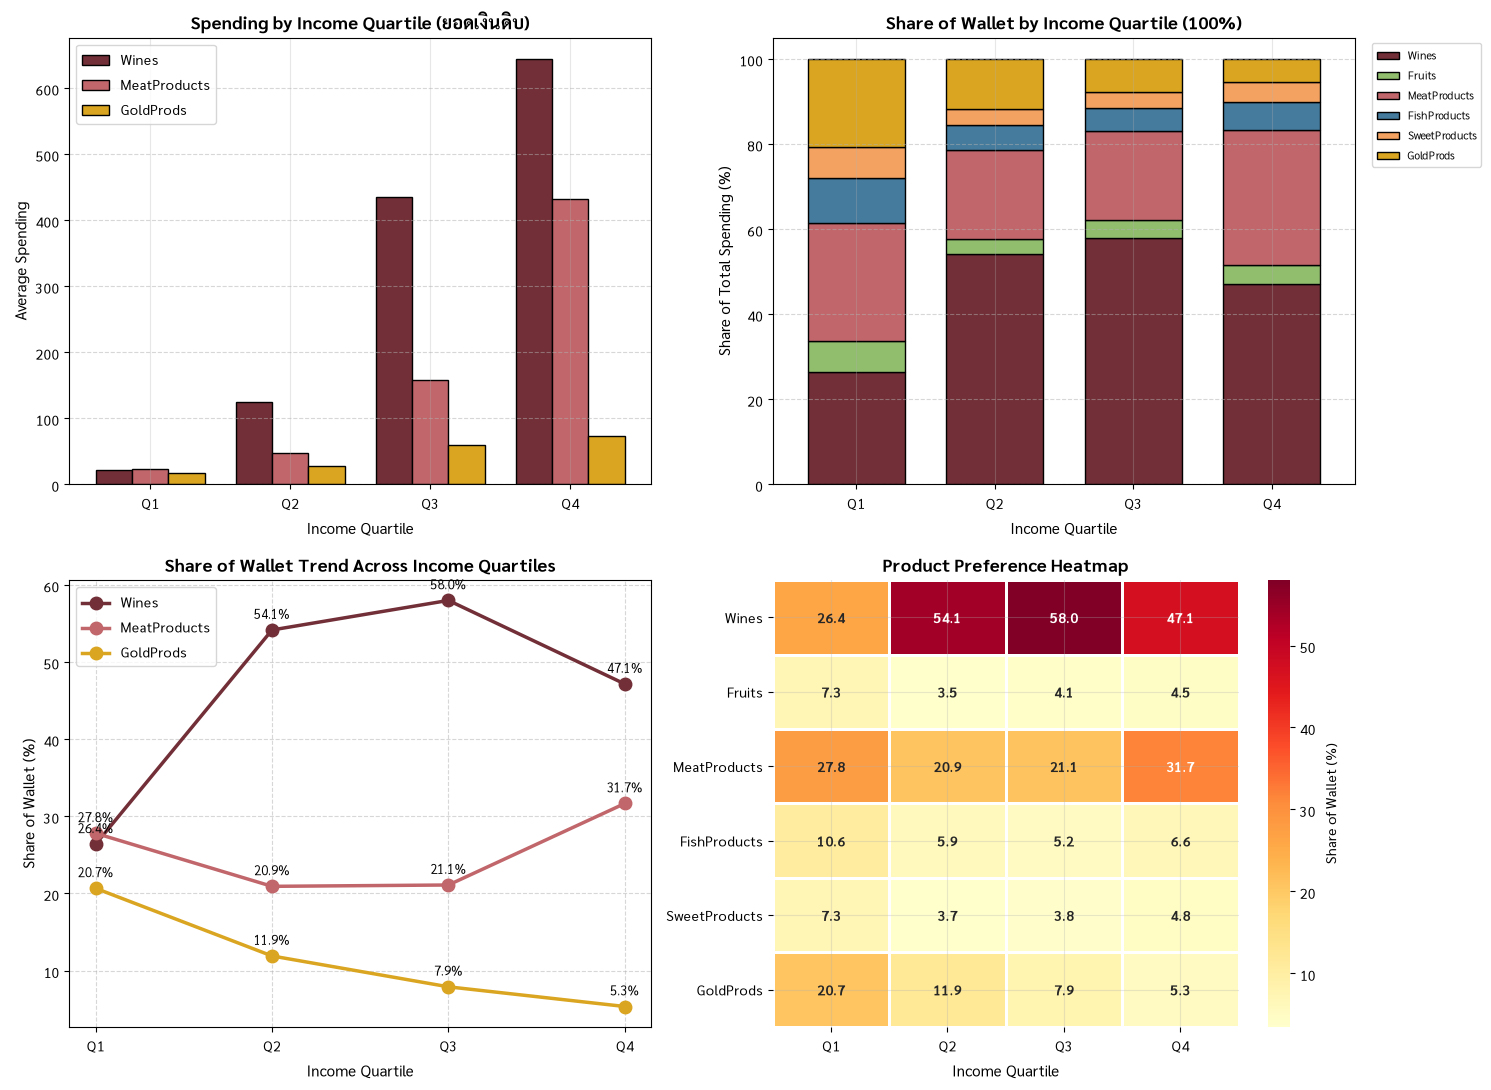

INSIGHT: Product Positioning by Income Segment
1. หมวดที่ยืดหยุ่นต่อรายได้มากที่สุด: Wines (Q4 ใช้จ่ายมากกว่า Q1 ถึง 29.9 เท่า)
   -> เป็นสินค้า Luxury ควรวางตำแหน่งเป็นสินค้าพรีเมียมสำหรับกลุ่มรายได้สูง
2. หมวดที่ยืดหยุ่นน้อยที่สุด: GoldProds (4.3 เท่า)
   -> เป็นสินค้าที่ขายได้ทุกกลุ่ม ควรแข่งที่ความสะดวกและราคา

3. การเปลี่ยนแปลงของ Share of Wallet จาก Q1 -> Q4:
     Wines            :  26.4% ->  47.1%  (+20.8 จุด, เพิ่มขึ้น)
     MeatProducts     :  27.8% ->  31.6%  ( +3.9 จุด, เพิ่มขึ้น)
     SweetProducts    :   7.3% ->   4.8%  ( -2.4 จุด, ลดลง)
     Fruits           :   7.3% ->   4.5%  ( -2.8 จุด, ลดลง)
     FishProducts     :  10.6% ->   6.5%  ( -4.1 จุด, ลดลง)
     GoldProds        :  20.7% ->   5.3%  (-15.3 จุด, ลดลง)

4. เมื่อรายได้สูงขึ้น ลูกค้าโยกงบไปที่: Wines, MeatProducts
   และลดสัดส่วนที่: SweetProducts, FishProducts, Fruits, GoldProds
   -> นี่คือ 'การยกระดับการบริโภค' (Trading up) ที่ชัดเจน

5. กลุ่ม Q4 (551 ราย, 25% ของฐานลูกค้า) สร้างยอดขายรวม 56.3%

ข้อเสนอแนะเชิ

In [63]:
# =============================================================================
# Exercise 29: Income Segmentation — Product Positioning
# =============================================================================

focus_cols = ["MntWines", "MntMeatProducts", "MntGoldProds"]
all_mnt = ["MntWines", "MntFruits", "MntMeatProducts",
           "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

# ----- ขั้นที่ 1: แบ่ง 4 ควอไทล์รายได้ด้วย pd.qcut -----
df["Income_Q"] = pd.qcut(df["Income"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])

# --- ยอดเงินดิบต่อกลุ่ม (Revenue view) ---
spend_by_q = df.groupby("Income_Q", observed=True)[all_mnt].mean().round(2)
spend_by_q.insert(0, "n", df["Income_Q"].value_counts(sort=False).values)
spend_by_q.insert(1, "avg_income", df.groupby("Income_Q", observed=True)["Income"].mean().round(0).values)

print("=" * 115)
print("ยอดใช้จ่ายเฉลี่ยแต่ละหมวด แยกตาม Income Quartile (ยอดเงินดิบ)")
print("=" * 115)
print(spend_by_q.to_string())

# ----- ขั้นที่ 2: Share of Wallet (Preference view) -----
share = df.groupby("Income_Q", observed=True)[all_mnt].sum()
share_pct = share.div(share.sum(axis=1), axis=0) * 100

print("\n" + "=" * 115)
print("Share of Wallet — สัดส่วนการใช้จ่ายแต่ละหมวดภายในกลุ่ม (% รวมแถว = 100)")
print("=" * 115)
print(share_pct.round(2).to_string())

# ----- ขั้นที่ 3: Income Elasticity -----
elasticity = pd.DataFrame({
    "Q1_spending": spend_by_q.loc["Q1", all_mnt],
    "Q4_spending": spend_by_q.loc["Q4", all_mnt],
})
elasticity["Q4/Q1_ratio"] = (elasticity["Q4_spending"]
                             / elasticity["Q1_spending"]).round(2)
elasticity["Q1_share_%"] = share_pct.loc["Q1"].round(2)
elasticity["Q4_share_%"] = share_pct.loc["Q4"].round(2)
elasticity["share_change"] = (elasticity["Q4_share_%"]
                              - elasticity["Q1_share_%"]).round(2)
elasticity = elasticity.sort_values("Q4/Q1_ratio", ascending=False)

print("\n" + "=" * 115)
print("Income Elasticity — ความยืดหยุ่นของแต่ละหมวดสินค้าต่อรายได้")
print("=" * 115)
print(elasticity.to_string())

print("\nการจัดประเภทสินค้า:")
for c in elasticity.index:
    ratio = elasticity.loc[c, "Q4/Q1_ratio"]
    if ratio > 3:
        cat = "Luxury / Discretionary — สินค้าฟุ่มเฟือย"
    elif ratio > 2:
        cat = "Semi-premium — กึ่งพรีเมียม"
    else:
        cat = "Necessity — สินค้าจำเป็น"
    print(f"  {c.replace('Mnt',''):<16} (Q4/Q1 = {ratio:>5.2f} เท่า) : {cat}")

# ----- ขั้นที่ 4: Visualize -----
fig, ax = plt.subplots(2, 2, figsize=(15, 11))
q_idx = ["Q1", "Q2", "Q3", "Q4"]
colors3 = ["#722F37", "#C1666B", "#DAA520"]

# แผง (0,0): Grouped Bar — ยอดเงินดิบ 3 หมวดหลัก
x = np.arange(4); w = 0.26
for i, (c, col) in enumerate(zip(focus_cols, colors3)):
    ax[0, 0].bar(x + (i - 1) * w, spend_by_q.loc[q_idx, c], w,
                 label=c.replace("Mnt", ""), color=col, edgecolor="black")
ax[0, 0].set_xticks(x); ax[0, 0].set_xticklabels(q_idx)
ax[0, 0].set_title("Spending by Income Quartile (ยอดเงินดิบ)",
                   fontsize=13, fontweight="bold")
ax[0, 0].set_xlabel("Income Quartile", fontsize=11)
ax[0, 0].set_ylabel("Average Spending", fontsize=11)
ax[0, 0].legend()
ax[0, 0].grid(axis="y", linestyle="--", alpha=0.5)

# แผง (0,1): 100% Stacked — Share of Wallet ทุกหมวด
share_pct.loc[q_idx].plot(kind="bar", stacked=True, ax=ax[0, 1],
                          color=["#722F37", "#90BE6D", "#C1666B",
                                 "#457B9D", "#F4A261", "#DAA520"],
                          edgecolor="black", width=0.7)
ax[0, 1].set_title("Share of Wallet by Income Quartile (100%)",
                   fontsize=13, fontweight="bold")
ax[0, 1].set_xlabel("Income Quartile", fontsize=11)
ax[0, 1].set_ylabel("Share of Total Spending (%)", fontsize=11)
ax[0, 1].legend([c.replace("Mnt", "") for c in all_mnt], fontsize=8,
                bbox_to_anchor=(1.02, 1), loc="upper left")
ax[0, 1].tick_params(axis="x", rotation=0)
ax[0, 1].grid(axis="y", linestyle="--", alpha=0.5)

# แผง (1,0): เส้นแนวโน้ม Share ของ 3 หมวดหลัก — เห็นว่าหมวดไหนได้/เสีย
for c, col in zip(focus_cols, colors3):
    ax[1, 0].plot(q_idx, share_pct.loc[q_idx, c], marker="o", linewidth=2.5,
                  markersize=9, label=c.replace("Mnt", ""), color=col)
    for i, q in enumerate(q_idx):
        ax[1, 0].annotate(f"{share_pct.loc[q, c]:.1f}%",
                          (i, share_pct.loc[q, c]), xytext=(0, 8),
                          textcoords="offset points", ha="center", fontsize=9)
ax[1, 0].set_title("Share of Wallet Trend Across Income Quartiles",
                   fontsize=13, fontweight="bold")
ax[1, 0].set_xlabel("Income Quartile", fontsize=11)
ax[1, 0].set_ylabel("Share of Wallet (%)", fontsize=11)
ax[1, 0].legend()
ax[1, 0].grid(linestyle="--", alpha=0.5)

# แผง (1,1): Heatmap ของ Share of Wallet
sns.heatmap(share_pct.loc[q_idx].T, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=1, cbar_kws={"label": "Share of Wallet (%)"},
            yticklabels=[c.replace("Mnt", "") for c in all_mnt],
            annot_kws={"fontsize": 10, "fontweight": "bold"},
            ax=ax[1, 1])
ax[1, 1].set_title("Product Preference Heatmap", fontsize=13, fontweight="bold")
ax[1, 1].set_xlabel("Income Quartile", fontsize=11)

plt.tight_layout()
plt.show()

# ----- สรุป Insight -----
print("=" * 80)
print("INSIGHT: Product Positioning by Income Segment")
print("=" * 80)

most_elastic = elasticity.index[0]
least_elastic = elasticity.index[-1]

print(f"1. หมวดที่ยืดหยุ่นต่อรายได้มากที่สุด: {most_elastic.replace('Mnt','')} "
      f"(Q4 ใช้จ่ายมากกว่า Q1 ถึง {elasticity.loc[most_elastic, 'Q4/Q1_ratio']:.1f} เท่า)")
print(f"   -> เป็นสินค้า Luxury ควรวางตำแหน่งเป็นสินค้าพรีเมียมสำหรับกลุ่มรายได้สูง")
print(f"2. หมวดที่ยืดหยุ่นน้อยที่สุด: {least_elastic.replace('Mnt','')} "
      f"({elasticity.loc[least_elastic, 'Q4/Q1_ratio']:.1f} เท่า)")
print(f"   -> เป็นสินค้าที่ขายได้ทุกกลุ่ม ควรแข่งที่ความสะดวกและราคา\n")

print("3. การเปลี่ยนแปลงของ Share of Wallet จาก Q1 -> Q4:")
for c in elasticity.sort_values("share_change", ascending=False).index:
    chg = elasticity.loc[c, "share_change"]
    arrow = "เพิ่มขึ้น" if chg > 0 else "ลดลง"
    print(f"     {c.replace('Mnt',''):<16} : {elasticity.loc[c, 'Q1_share_%']:>5.1f}% -> "
          f"{elasticity.loc[c, 'Q4_share_%']:>5.1f}%  ({chg:>+5.1f} จุด, {arrow})")

rising = elasticity[elasticity["share_change"] > 0].index.tolist()
falling = elasticity[elasticity["share_change"] < 0].index.tolist()
print(f"\n4. เมื่อรายได้สูงขึ้น ลูกค้าโยกงบไปที่: "
      f"{', '.join(c.replace('Mnt','') for c in rising)}")
print(f"   และลดสัดส่วนที่: {', '.join(c.replace('Mnt','') for c in falling)}")
print("   -> นี่คือ 'การยกระดับการบริโภค' (Trading up) ที่ชัดเจน")

print(f"\n5. กลุ่ม Q4 ({int(spend_by_q.loc['Q4','n']):,} ราย, "
      f"{spend_by_q.loc['Q4','n']/len(df)*100:.0f}% ของฐานลูกค้า) "
      f"สร้างยอดขายรวม {share.loc['Q4'].sum()/share.sum().sum()*100:.1f}%")

print("\nข้อเสนอแนะเชิงธุรกิจ (Product Positioning):")
print("  Q1-Q2 (รายได้ต่ำ-กลางล่าง):")
print("    - เน้นสินค้าจำเป็น (ผลไม้, ขนมหวาน) ขนาดประหยัด")
print("    - ใช้ส่วนลดและ Deal เป็นเครื่องมือหลัก")
print("  Q3 (รายได้กลางบน):")
print("    - กลุ่มเป้าหมายของการทำ Upselling — มีกำลังซื้อแต่ยังไม่ซื้อพรีเมียมเต็มที่")
print("    - เสนอสินค้าระดับกลาง-สูงพร้อมตัวอย่างทดลอง")
print("  Q4 (รายได้สูง):")
print("    - เน้นไวน์และเนื้อคุณภาพสูง ตั้งราคาพรีเมียมได้")
print("    - ไม่ควรใช้ส่วนลด แต่ใช้ความพิเศษ (Exclusivity) เป็นจุดขาย")

---

## Exercise 30 — Correlation Heatmap

> **โจทย์:** Create a correlation heatmap of product spending variables (`MntWines`, `MntMeatProducts`, `MntSweetProducts`, `MntGoldProds`). Which products are often purchased together, and what cross-selling opportunities exist?

**วัตถุประสงค์:** ใช้ Heatmap หาว่าสินค้าหมวดใดมักถูกซื้อร่วมกัน และหาโอกาส Cross-selling

### จาก Correlation ไปสู่ Cross-selling

Correlation ระหว่างยอดใช้จ่าย 2 หมวดที่เป็น **บวกสูง** หมายถึงลูกค้าที่ซื้อหมวดหนึ่งมาก
มักซื้ออีกหมวดมากด้วย → เป็นสัญญาณของ **Product Affinity** (ความเข้ากันของสินค้า)

### แต่ต้องระวัง: Correlation อาจเกิดจาก "กำลังซื้อ" ไม่ใช่ "ความเข้ากัน"

คนรายได้สูงซื้อ**ทุกอย่าง**มากกว่า → ทำให้ทุกหมวดมี Correlation เป็นบวกโดยอัตโนมัติ
นี่คือ **Spurious correlation** ที่เกิดจากตัวแปรร่วม (Common cause)

**วิธีตรวจสอบ:** คำนวณ **Partial Correlation** — หักผลของ `Income` ออกก่อน

```
r(A,B | Income) = [r(A,B) − r(A,Income)·r(B,Income)] / √[(1−r²(A,Income))(1−r²(B,Income))]
```

ถ้าหลังหักผลรายได้แล้ว r **ยังสูง** → เป็น Product Affinity ที่แท้จริง ใช้ทำ Bundle ได้
ถ้า r **ลดลงมาก** → เป็นแค่ผลของกำลังซื้อ ไม่ใช่ความเข้ากันของสินค้า

### Cross-selling Opportunity Matrix

จัดกลุ่มด้วย **r ดิบ** (วัดการซื้อร่วมกันที่สังเกตได้จริง) แล้วใช้ **r หักรายได้** บอกว่าความสัมพันธ์นั้นมาจากความเข้ากันของสินค้ามากน้อยเพียงใด

| r ดิบ | ความหมายทางธุรกิจ | กลยุทธ์ |
|-------|--------------------|---------|
| **สูง (≥ 0.5)** | ซื้อร่วมกันมากอยู่แล้ว | จัด **Bundle** / วางใกล้กัน / แนะนำอัตโนมัติ |
| **กลาง (0.3–0.5)** | ซื้อร่วมกันบางส่วน | ★ **โอกาสสูงสุด** — มี Headroom ให้กระตุ้น |
| **ต่ำ (< 0.3)** | แทบไม่ซื้อร่วมกัน | ไม่คุ้มจับคู่ |

> **ข้อควรระวังที่จะพบในผลลัพธ์:** ในชุดข้อมูลนี้ทุกคู่สินค้ามีค่า r ลดลงอย่างน้อยครึ่งหนึ่งเมื่อหักผลรายได้ออก
> แปลว่า **รายได้เป็นตัวแปรร่วมที่ทำให้ยอดใช้จ่ายทุกหมวดขยับไปด้วยกัน** — ไม่ใช่ความเข้ากันของสินค้าล้วน ๆ
> จึงต้องระวังไม่สรุปว่า r สูง = สินค้าเข้ากันเสมอ

Correlation Matrix — 4 หมวดสินค้าตามโจทย์
                  MntWines  MntMeatProducts  MntSweetProducts  MntGoldProds
MntWines            1.0000           0.5931            0.3886        0.3902
MntMeatProducts     0.5931           1.0000            0.5565        0.3756
MntSweetProducts    0.3886           0.5565            1.0000        0.3557
MntGoldProds        0.3902           0.3756            0.3557        1.0000

Partial Correlation — หักผลของ Income ออก เพื่อแยก 'ความเข้ากันจริง' จาก 'กำลังซื้อ'
คู่สินค้า                                      r ปกติ   r หัก Income       ลดลง
-----------------------------------------------------------------------------------------------
Wines <-> MeatProducts                         0.5931         0.1645      72.3%
Wines <-> SweetProducts                        0.3886        -0.0304     107.8%
Wines <-> GoldProds                            0.3902         0.1371      64.9%
MeatProducts <-> SweetProducts                 0.5565         0.2809      49

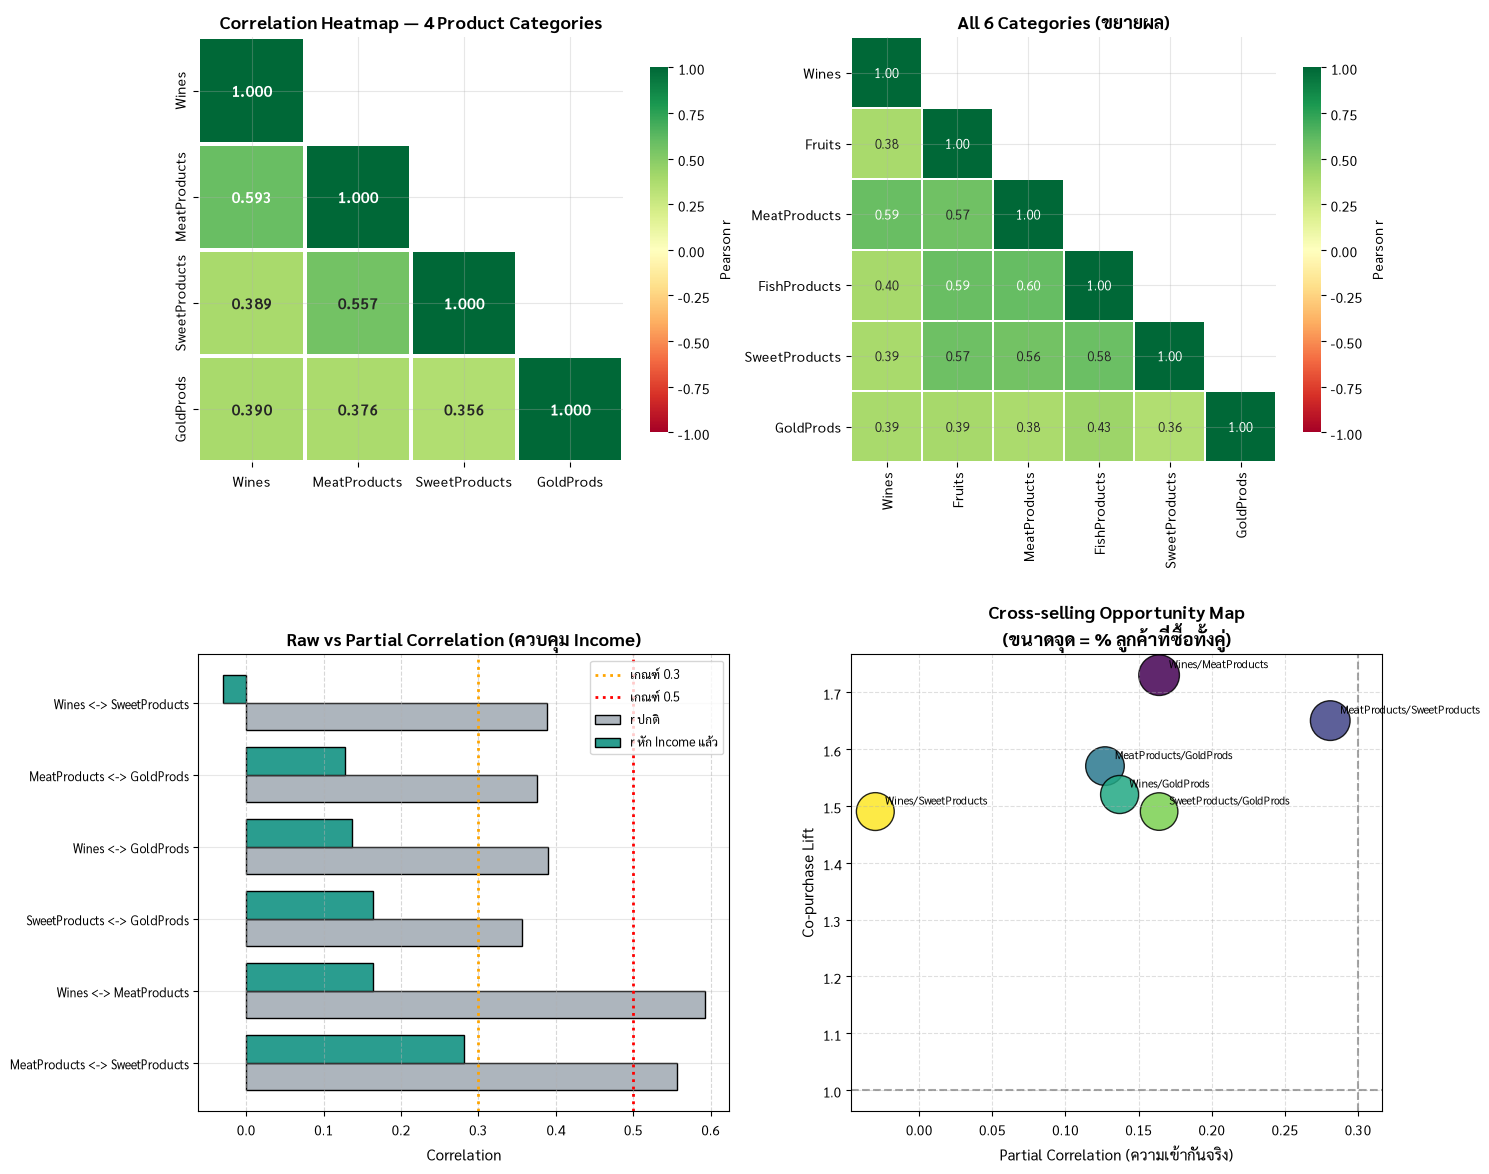

INSIGHT: Cross-selling Opportunities
1. คู่ที่เข้ากันที่สุด (หลังหักผลรายได้): MeatProducts <-> SweetProducts
   r ปกติ = 0.557 -> r หัก Income = 0.281 (ลดลง 49.5%)
   เป็นคู่ที่ยังเหลือความสัมพันธ์มากที่สุดหลังตัดผลของรายได้ออก

2. ผลของการหักรายได้ออก — รายได้อธิบายความสัมพันธ์ไปเท่าใด:
   (ลดลง < 50% = ความเข้ากันของสินค้ายังเป็นตัวขับหลัก)
     MeatProducts <-> SweetProducts         ลดลง  49.5% -> ความเข้ากันของสินค้าเป็นตัวขับหลัก
     Wines <-> MeatProducts                 ลดลง  72.3% -> รายได้อธิบายได้เป็นส่วนใหญ่
     SweetProducts <-> GoldProds            ลดลง  54.0% -> รายได้อธิบายได้เป็นส่วนใหญ่
     Wines <-> GoldProds                    ลดลง  64.9% -> รายได้อธิบายได้เป็นส่วนใหญ่
     MeatProducts <-> GoldProds             ลดลง  66.2% -> รายได้อธิบายได้เป็นส่วนใหญ่
     Wines <-> SweetProducts                ลดลง 107.8% -> เกิดจากรายได้แทบทั้งหมด

   ข้อสังเกต: ทุกคู่ลดลงอย่างน้อยครึ่งหนึ่ง แสดงว่า 'รายได้' เป็นตัวแปรร่วม
   ที่ทำให้ยอดใช้จ่ายทุกหมวดขยับไปด้วยกัน ไม่ใช่ความ

In [64]:
# =============================================================================
# Exercise 30: Correlation Heatmap — Cross-selling Opportunities
# =============================================================================

prod_cols = ["MntWines", "MntMeatProducts", "MntSweetProducts", "MntGoldProds"]
all_mnt = ["MntWines", "MntFruits", "MntMeatProducts",
           "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

# ----- ขั้นที่ 1: Correlation Matrix ของ 4 หมวดตามโจทย์ -----
corr4 = df[prod_cols].corr()

print("=" * 85)
print("Correlation Matrix — 4 หมวดสินค้าตามโจทย์")
print("=" * 85)
print(corr4.round(4).to_string())

# ----- ขั้นที่ 2: Partial Correlation — หักผลของ Income ออก -----
def partial_corr(a, b, control):
    """คำนวณ Partial Correlation ของ a กับ b เมื่อควบคุมผลของ control"""
    r_ab = df[a].corr(df[b])
    r_ac = df[a].corr(df[control])
    r_bc = df[b].corr(df[control])
    num = r_ab - r_ac * r_bc
    den = np.sqrt((1 - r_ac**2) * (1 - r_bc**2))
    return r_ab, num / den

print("\n" + "=" * 95)
print("Partial Correlation — หักผลของ Income ออก เพื่อแยก 'ความเข้ากันจริง' จาก 'กำลังซื้อ'")
print("=" * 95)
print(f"{'คู่สินค้า':<42} {'r ปกติ':>10} {'r หัก Income':>14} {'ลดลง':>10}")
print("-" * 95)

pair_data = []
for i in range(len(prod_cols)):
    for j in range(i + 1, len(prod_cols)):
        a, b = prod_cols[i], prod_cols[j]
        r_raw, r_par = partial_corr(a, b, "Income")
        drop = (r_raw - r_par) / r_raw * 100 if r_raw != 0 else 0
        label = f"{a.replace('Mnt','')} <-> {b.replace('Mnt','')}"
        print(f"{label:<42} {r_raw:>10.4f} {r_par:>14.4f} {drop:>9.1f}%")
        pair_data.append({"pair": label, "a": a, "b": b,
                          "r_raw": r_raw, "r_partial": r_par, "drop_pct": drop})

pairs_df = pd.DataFrame(pair_data).sort_values("r_partial", ascending=False)

# ----- ขั้นที่ 3: Co-purchase Rate — วัดจากพฤติกรรมจริง -----
print("\n" + "=" * 95)
print("Co-purchase Rate — สัดส่วนลูกค้าที่ซื้อทั้ง 2 หมวดในระดับสูง (เกิน Median ทั้งคู่)")
print("=" * 95)

co_rates = []
for row in pairs_df.itertuples():
    a, b = row.a, row.b
    high_a = df[a] > df[a].median()
    high_b = df[b] > df[b].median()
    both = (high_a & high_b).mean() * 100
    only_a = (high_a & ~high_b).mean() * 100
    expected = high_a.mean() * high_b.mean() * 100   # ถ้าเป็นอิสระต่อกัน
    lift = both / expected if expected > 0 else 0
    co_rates.append({"pair": row.pair, "ซื้อทั้งคู่_%": round(both, 2),
                     "ซื้อเฉพาะ A_%": round(only_a, 2),
                     "ถ้าอิสระ_%": round(expected, 2), "Lift": round(lift, 2),
                     "r_partial": round(row.r_partial, 3)})
co_df = pd.DataFrame(co_rates).sort_values("Lift", ascending=False)
print(co_df.to_string(index=False))

# ----- ขั้นที่ 4: Visualize -----
fig, ax = plt.subplots(2, 2, figsize=(15, 12))

# แผง (0,0): Heatmap 4 หมวดตามโจทย์
mask = np.triu(np.ones_like(corr4, dtype=bool), k=1)
sns.heatmap(corr4, mask=mask, annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=-1, vmax=1, center=0, square=True, linewidths=1.5,
            linecolor="white", cbar_kws={"label": "Pearson r", "shrink": 0.8},
            annot_kws={"fontsize": 11, "fontweight": "bold"},
            xticklabels=[c.replace("Mnt", "") for c in prod_cols],
            yticklabels=[c.replace("Mnt", "") for c in prod_cols],
            ax=ax[0, 0])
ax[0, 0].set_title("Correlation Heatmap — 4 Product Categories",
                   fontsize=13, fontweight="bold")

# แผง (0,1): Heatmap ครบทุกหมวด (ขยายผล)
corr_all = df[all_mnt].corr()
mask_all = np.triu(np.ones_like(corr_all, dtype=bool), k=1)
sns.heatmap(corr_all, mask=mask_all, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=-1, vmax=1, center=0, square=True, linewidths=1.2,
            linecolor="white", cbar_kws={"label": "Pearson r", "shrink": 0.8},
            annot_kws={"fontsize": 9},
            xticklabels=[c.replace("Mnt", "") for c in all_mnt],
            yticklabels=[c.replace("Mnt", "") for c in all_mnt],
            ax=ax[0, 1])
ax[0, 1].set_title("All 6 Categories (ขยายผล)", fontsize=13, fontweight="bold")

# แผง (1,0): เทียบ r ปกติ vs r หัก Income
y = np.arange(len(pairs_df)); h = 0.38
ax[1, 0].barh(y - h/2, pairs_df["r_raw"], h, label="r ปกติ",
              color="#ADB5BD", edgecolor="black")
ax[1, 0].barh(y + h/2, pairs_df["r_partial"], h, label="r หัก Income แล้ว",
              color="#2A9D8F", edgecolor="black")
ax[1, 0].set_yticks(y); ax[1, 0].set_yticklabels(pairs_df["pair"], fontsize=9)
ax[1, 0].axvline(0.3, color="orange", linestyle=":", linewidth=2, label="เกณฑ์ 0.3")
ax[1, 0].axvline(0.5, color="red", linestyle=":", linewidth=2, label="เกณฑ์ 0.5")
ax[1, 0].set_title("Raw vs Partial Correlation (ควบคุม Income)",
                   fontsize=13, fontweight="bold")
ax[1, 0].set_xlabel("Correlation", fontsize=11)
ax[1, 0].legend(fontsize=9)
ax[1, 0].grid(axis="x", linestyle="--", alpha=0.5)

# แผง (1,1): Cross-selling Opportunity Matrix
ax[1, 1].scatter(co_df["r_partial"], co_df["Lift"],
                 s=co_df["ซื้อทั้งคู่_%"] * 20, c=range(len(co_df)),
                 cmap="viridis", edgecolors="black", alpha=0.85)
for row in co_df.itertuples():
    ax[1, 1].annotate(row.pair.replace(" <-> ", "/"),
                      (row.r_partial, row.Lift), xytext=(7, 5),
                      textcoords="offset points", fontsize=8)
ax[1, 1].axvline(0.3, color="gray", linestyle="--", alpha=0.7)
ax[1, 1].axhline(1.0, color="gray", linestyle="--", alpha=0.7)
ax[1, 1].set_title("Cross-selling Opportunity Map\n(ขนาดจุด = % ลูกค้าที่ซื้อทั้งคู่)",
                   fontsize=13, fontweight="bold")
ax[1, 1].set_xlabel("Partial Correlation (ความเข้ากันจริง)", fontsize=11)
ax[1, 1].set_ylabel("Co-purchase Lift", fontsize=11)
ax[1, 1].grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ----- สรุป Insight -----
print("=" * 85)
print("INSIGHT: Cross-selling Opportunities")
print("=" * 85)

top = pairs_df.iloc[0]
print(f"1. คู่ที่เข้ากันที่สุด (หลังหักผลรายได้): {top['pair']}")
print(f"   r ปกติ = {top['r_raw']:.3f} -> r หัก Income = {top['r_partial']:.3f} "
      f"(ลดลง {top['drop_pct']:.1f}%)")
print("   เป็นคู่ที่ยังเหลือความสัมพันธ์มากที่สุดหลังตัดผลของรายได้ออก\n")

print("2. ผลของการหักรายได้ออก — รายได้อธิบายความสัมพันธ์ไปเท่าใด:")
print("   (ลดลง < 50% = ความเข้ากันของสินค้ายังเป็นตัวขับหลัก)")
for row in pairs_df.itertuples():
    if row.drop_pct < 50:
        status = "ความเข้ากันของสินค้าเป็นตัวขับหลัก"
    elif row.drop_pct < 80:
        status = "รายได้อธิบายได้เป็นส่วนใหญ่"
    else:
        status = "เกิดจากรายได้แทบทั้งหมด"
    print(f"     {row.pair:<38} ลดลง {row.drop_pct:>5.1f}% -> {status}")
print("\n   ข้อสังเกต: ทุกคู่ลดลงอย่างน้อยครึ่งหนึ่ง แสดงว่า 'รายได้' เป็นตัวแปรร่วม")
print("   ที่ทำให้ยอดใช้จ่ายทุกหมวดขยับไปด้วยกัน ไม่ใช่ความเข้ากันของสินค้าล้วน ๆ")

print("\n3. จัดกลุ่มโอกาส Cross-selling:")
# จัดกลุ่มด้วยเกณฑ์ของ r ดิบ (วัดการซื้อร่วมกันจริงที่สังเกตได้)
# และใช้ r หักรายได้เป็นตัวบอกว่าความสัมพันธ์นั้นมาจากความเข้ากันของสินค้าแค่ไหน
high = pairs_df[pairs_df["r_raw"] >= 0.5]
mid = pairs_df[(pairs_df["r_raw"] >= 0.3) & (pairs_df["r_raw"] < 0.5)]
low = pairs_df[pairs_df["r_raw"] < 0.3]

if len(high) > 0:
    print("   [r ดิบ >= 0.5] ซื้อร่วมกันมากอยู่แล้ว — จัด Bundle / วางใกล้กัน:")
    for row in high.itertuples():
        print(f"       - {row.pair:<38} (r = {row.r_raw:.3f}, หักรายได้ = {row.r_partial:.3f})")
if len(mid) > 0:
    print("   [r ดิบ 0.3-0.5] *** โอกาสสูงสุด — มี Headroom ให้กระตุ้น ***")
    for row in mid.itertuples():
        print(f"       - {row.pair:<38} (r = {row.r_raw:.3f}, หักรายได้ = {row.r_partial:.3f})")
if len(low) > 0:
    print("   [r ดิบ < 0.3] ซื้อร่วมกันน้อย ไม่คุ้มจับคู่:")
    for row in low.itertuples():
        print(f"       - {row.pair:<38} (r = {row.r_raw:.3f}, หักรายได้ = {row.r_partial:.3f})")

best_lift = co_df.iloc[0]
print(f"\n4. คู่ที่มี Co-purchase Lift สูงสุด: {best_lift['pair']} "
      f"(Lift = {best_lift['Lift']:.2f})")
print(f"   ลูกค้า {best_lift['ซื้อทั้งคู่_%']:.1f}% ซื้อทั้ง 2 หมวดในระดับสูง "
      f"(ถ้าเป็นอิสระต่อกันควรได้แค่ {best_lift['ถ้าอิสระ_%']:.1f}%)")

print("\nข้อเสนอแนะเชิงธุรกิจ:")
best_raw = pairs_df.sort_values("r_raw", ascending=False).iloc[0]
print(f"  - จัด Bundle '{best_raw['pair']}' (r ดิบสูงสุด = {best_raw['r_raw']:.3f}) "
      "เป็นชุดของขวัญ/ชุดมื้อพิเศษ")
print("  - ใน E-commerce: แสดง 'ลูกค้าที่ซื้อสินค้านี้มักซื้อ...' ตามคู่ที่ r สูง")
print("  - ในร้าน: วางสินค้าคู่ที่ r สูงไว้ใกล้กัน (Planogram optimization)")
print("  - คู่ระดับกลาง (0.3-0.5) ควรทำ A/B Test โปรโมชันจับคู่ เพราะมีโอกาสเติบโตสูงสุด")
print("  - ระวัง: Correlation จากข้อมูลระดับลูกค้า (Customer-level) ไม่เท่ากับ")
print("    Market Basket Analysis ที่วิเคราะห์ระดับใบเสร็จ (Transaction-level)")
print("    หากต้องการยืนยัน ควรวิเคราะห์ข้อมูลการซื้อรายครั้งเพิ่มเติม")

---

# สรุปภาพรวม Workshop

## สิ่งที่ได้ฝึกในแต่ละช่วง

### Exercise 1–20 : Basic Skills

| กลุ่มทักษะ | ข้อที่เกี่ยวข้อง | คำสั่งหลัก |
|------------|------------------|------------|
| **โหลดและสำรวจข้อมูล** | 1 | `pd.read_excel`, `.shape`, `.info()`, `.isna()` |
| **สถิติค่ากลาง** | 2 | `.mean()`, `.median()`, `.mode()` |
| **สถิติการกระจาย** | 4, 12 | `.quantile()`, IQR, `.skew()`, `.kurt()` |
| **การแบ่งกลุ่มข้อมูล** | 5, 16 | `pd.cut()`, `pd.qcut()` |
| **GroupBy / Aggregation** | 6, 7, 18 | `.groupby()`, `.agg()` |
| **การกรองข้อมูล** | 14, 15 | Boolean Indexing, `.nlargest()` |
| **สัดส่วนและตารางไขว้** | 8, 9, 17 | `.value_counts()`, `pd.crosstab()` |
| **ความสัมพันธ์** | 10, 20 | `.corr()`, `sns.heatmap()` |
| **การสร้างคอลัมน์ใหม่** | 19 | `.sum(axis=1)` |
| **Visualization** | 3, 9, 11, 13, 17, 20 | `plt.hist`, `plt.bar`, `plt.boxplot`, `sns.pairplot`, `sns.heatmap` |

### Exercise 21–30 : Insight Analysis

| เทคนิคการวิเคราะห์ | ข้อที่ใช้ | ประโยชน์ |
|---------------------|----------|----------|
| **Share of Wallet** | 22, 29 | แยก "ความชอบ" ออกจาก "กำลังซื้อ" |
| **Lift / Over-representation Index** | 24, 26, 27, 30 | วัดว่ากลุ่มหนึ่งโดดเด่นกว่าค่าเฉลี่ยจริงหรือไม่ |
| **การทดสอบนัยสำคัญ** | 22–25, 27 | t-test, ANOVA, Chi-square, Mann-Whitney |
| **Effect Size (Cohen's d)** | 25 | แยก "มีนัยสำคัญ" ออกจาก "ต่างกันมาก" |
| **Partial Correlation** | 30 | ตัดตัวแปรกวนออกเพื่อหาความสัมพันธ์ที่แท้จริง |
| **RFM Model** | 28 | จัดอันดับมูลค่าลูกค้าด้วย 3 มิติ |
| **Income Elasticity** | 29 | จัดประเภทสินค้าเป็น Luxury vs Necessity |
| **Segmentation** | 26, 27, 29 | แบ่งกลุ่มลูกค้าเพื่อวางกลยุทธ์แยกกัน |

---

## บทเรียนเชิงวิเคราะห์ที่สำคัญ 6 ข้อ

### 1. ค่าเฉลี่ยดิบมักหลอกตา — ต้องดูสัดส่วนประกอบ
Exercise 22 แสดงชัดว่ากลุ่มการศึกษาสูงใช้จ่ายเนื้อสัตว์มากกว่า **เพราะมีรายได้มากกว่า** ไม่ใช่เพราะชอบเนื้อสัตว์มากกว่า เมื่อดู Share of Wallet ความต่างแทบหายไป

### 2. ต้องมีกลุ่มเปรียบเทียบเสมอ
"ลูกค้ามูลค่าสูง 60% แต่งงานแล้ว" ไม่ใช่ Insight ถ้าฐานลูกค้าทั้งหมดก็มี 60% — ต้องคำนวณ **Index** เทียบกับกลุ่มอ้างอิง (Exercise 26, 27)

### 3. p-value ไม่ได้บอกว่าความต่างนั้น "สำคัญ"
เมื่อ n ใหญ่ ความต่างเล็กน้อยก็ได้ p ต่ำ จึงต้องรายงาน **Effect Size** ควบคู่ไปด้วย (Exercise 25)

### 4. Correlation อาจเกิดจากตัวแปรกวน
ทุกหมวดสินค้ามี Correlation เป็นบวกส่วนหนึ่งเพราะ **รายได้** เป็นสาเหตุร่วม — **Partial Correlation** ช่วยแยกความสัมพันธ์ที่แท้จริงออกมา (Exercise 30)

### 5. ผลที่ขัดความคาดหมายมักมีค่าที่สุด
Exercise 25 พบว่าครัวเรือนมีบุตรซื้อขนมหวาน **น้อยกว่า** และ Exercise 28 พบว่า Recency แทบไม่สัมพันธ์กับยอดใช้จ่าย — ทั้งสองกรณีขัดกับสมมติฐานที่ฟังดูสมเหตุสมผล

### 6. ตัวชี้วัดเดียวไม่เพียงพอ
Exercise 28 แสดงว่า `Recency` ตัวเดียวทำนายยอดใช้จ่ายไม่ได้ แต่เมื่อรวมเป็น **RFM Score** ความสัมพันธ์แข็งแรงขึ้นชัดเจน

---

## ข้อจำกัดของการวิเคราะห์ชุดนี้

| ข้อจำกัด | ผลต่อการตีความ |
|----------|-----------------|
| **Observational data** ไม่ใช่การทดลองสุ่ม | สรุปได้เพียงความสัมพันธ์ ไม่ใช่เหตุและผล |
| ข้อมูลระดับ **ลูกค้า** ไม่ใช่ระดับ **ใบเสร็จ** | Cross-selling ที่ได้ยังไม่เท่ากับ Market Basket Analysis จริง |
| เป็น **Snapshot** ช่วงเวลาเดียว | ไม่เห็นแนวโน้มตามเวลาหรือการเปลี่ยนพฤติกรรม |
| มองเห็นเฉพาะการซื้อ **ในร้านนี้** | ลูกค้าอาจซื้อสินค้าเดียวกันจากคู่แข่งด้วย |
| กลุ่มย่อยบางกลุ่มมีสมาชิก **น้อยกว่า 30 ราย** | ค่าสถิติของกลุ่มเหล่านั้นผันผวนสูง ไม่ควรนำไปตัดสินใจ |

---

## แนวทางต่อยอด

1. **Customer Segmentation ด้วย Machine Learning** — ใช้ K-Means หรือ Hierarchical Clustering แทนการแบ่งด้วยเกณฑ์ที่กำหนดเอง
2. **Propensity Model** — สร้าง Logistic Regression / Gradient Boosting ทำนาย `Response` จากทุกตัวแปรร่วมกัน
3. **Customer Lifetime Value (CLV)** — ประมาณมูลค่าลูกค้าตลอดช่วงความสัมพันธ์ ไม่ใช่แค่ยอดใช้จ่ายย้อนหลัง
4. **Market Basket Analysis** — หากได้ข้อมูลระดับใบเสร็จ ใช้ Apriori / FP-Growth หาความสัมพันธ์สินค้าที่แม่นกว่า
5. **A/B Testing** — ทดสอบข้อเสนอแนะทุกข้อในบทนี้กับลูกค้ากลุ่มจริง เพื่อยืนยันว่าได้ผลตามที่วิเคราะห์

---

In [65]:
# =============================================================================
# สรุปตัวเลขสำคัญจากการวิเคราะห์ทั้งหมด
# =============================================================================
# รวมผลลัพธ์หลักของทุก Exercise ไว้ในที่เดียว เพื่อใช้อ้างอิงและตรวจทาน

from scipy import stats

print("=" * 80)
print(" " * 22 + "สรุปผลการวิเคราะห์ iFood Dataset")
print("=" * 80)

print("\n[ภาพรวมข้อมูล]")
print(f"  จำนวนลูกค้า                : {len(df):,} ราย")
print(f"  จำนวนคอลัมน์ตั้งต้น         : 27 คอลัมน์")
print(f"  คอลัมน์ที่สร้างเพิ่มระหว่างวิเคราะห์ : {len(df.columns) - 27} คอลัมน์")
print(f"  Missing Value               : {df.isna().sum().sum()} cells "
      f"(เกิดจากการหารด้วยศูนย์ในคอลัมน์คำนวณ)")

print("\n[ลักษณะลูกค้า]")
print(f"  อายุ                 : {df['Age'].min()}-{df['Age'].max()} ปี "
      f"(เฉลี่ย {df['Age'].mean():.1f} ปี)")
print(f"  รายได้               : {df['Income'].min():,} - {df['Income'].max():,} "
      f"(Median {df['Income'].median():,.0f})")
print(f"  สถานภาพสมรสที่พบมากสุด : {df['Marital'].mode()[0]} "
      f"({(df['Marital'] == df['Marital'].mode()[0]).mean()*100:.1f}%)")
print(f"  การศึกษาที่พบมากสุด    : {df['Education'].mode()[0]} "
      f"({(df['Education'] == df['Education'].mode()[0]).mean()*100:.1f}%)")
print(f"  ครัวเรือนที่มีบุตร      : {(df['Total_Children'] > 0).mean()*100:.1f}%")

print("\n[การใช้จ่าย]")
print(f"  ยอดใช้จ่ายรวมเฉลี่ยต่อราย : {df['Total_Spending'].mean():,.2f}")
mnt_cols = ["MntWines", "MntFruits", "MntMeatProducts",
            "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
spend_share = (df[mnt_cols].sum() / df[mnt_cols].sum().sum() * 100).sort_values(ascending=False)
print("  สัดส่วนยอดขายแต่ละหมวด:")
for c, v in spend_share.items():
    print(f"     {c.replace('Mnt',''):<16} : {v:>5.1f}%")

print("\n[แคมเปญการตลาด]")
print(f"  Response Rate แคมเปญล่าสุด      : {df['Response'].mean()*100:.2f}%")
print(f"  ลูกค้าที่ตอบรับ >= 2 แคมเปญ      : "
      f"{(df['Total_Accepted'] >= 2).sum():,} ราย "
      f"({(df['Total_Accepted'] >= 2).mean()*100:.1f}%)")
print(f"  ลูกค้าที่ไม่เคยตอบรับแคมเปญเลย   : "
      f"{(df['Total_Accepted'] == 0).sum():,} ราย "
      f"({(df['Total_Accepted'] == 0).mean()*100:.1f}%)")

print("\n[ความสัมพันธ์สำคัญ]")
key_corrs = [
    ("Income", "MntWines"),
    ("Income", "MntMeatProducts"),
    ("Income", "Total_Spending"),
    ("MntWines", "MntMeatProducts"),
    ("Recency", "Total_Spending"),
    ("Total_Children", "Total_Spending"),
    ("Age", "Total_Spending"),
]
for a, b in key_corrs:
    r, p = stats.pearsonr(df[a], df[b])
    sig = "*" if p < 0.05 else " "
    print(f"  {a:<16} vs {b:<18} : r = {r:>7.4f} {sig}")
print("  (* = มีนัยสำคัญทางสถิติที่ระดับ 0.05)")

print("\n[การกระจุกตัวของมูลค่า — Pareto]")
for pct in [0.10, 0.20, 0.30]:
    n_top = int(len(df) * pct)
    share = df.nlargest(n_top, "Total_Spending")["Total_Spending"].sum() \
            / df["Total_Spending"].sum() * 100
    print(f"  ลูกค้า Top {pct*100:>2.0f}% ({n_top:>4,} ราย) สร้างยอดขาย {share:>5.1f}%")

print("\n[ข้อเสนอแนะเชิงกลยุทธ์ 5 ข้อหลัก]")
print("  1. ทุ่มงบการตลาดสินค้าพรีเมียมที่กลุ่มรายได้ Q4 ซึ่งสร้างรายได้สัดส่วนสูงสุด")
print("  2. ใช้ประวัติการตอบรับแคมเปญเป็น Feature หลักในการเลือกกลุ่มเป้าหมาย")
print("  3. แยกกลยุทธ์ชัดเจน: ครัวเรือนมีบุตรเน้นความคุ้มค่า / ไม่มีบุตรเน้นพรีเมียม")
print("  4. จัด Bundle ไวน์กับเนื้อสัตว์ เพราะเป็นคู่ที่เข้ากันจริงแม้หักผลรายได้ออกแล้ว")
print("  5. ใช้ RFM Score แทนตัวชี้วัดเดี่ยวในการจัดลำดับความสำคัญของลูกค้า")

print("\n" + "=" * 80)
print(" " * 28 + "จบ Workshop — Exercise 1-30")
print("=" * 80)

                      สรุปผลการวิเคราะห์ iFood Dataset

[ภาพรวมข้อมูล]
  จำนวนลูกค้า                : 2,205 ราย
  จำนวนคอลัมน์ตั้งต้น         : 27 คอลัมน์
  คอลัมน์ที่สร้างเพิ่มระหว่างวิเคราะห์ : 22 คอลัมน์
  Missing Value               : 10 cells (เกิดจากการหารด้วยศูนย์ในคอลัมน์คำนวณ)

[ลักษณะลูกค้า]
  อายุ                 : 24-80 ปี (เฉลี่ย 51.1 ปี)
  รายได้               : 1,730 - 113,734 (Median 51,287)
  สถานภาพสมรสที่พบมากสุด : Married (38.7%)
  การศึกษาที่พบมากสุด    : Graduation (50.5%)
  ครัวเรือนที่มีบุตร      : 71.5%

[การใช้จ่าย]
  ยอดใช้จ่ายรวมเฉลี่ยต่อราย : 606.82
  สัดส่วนยอดขายแต่ละหมวด:
     Wines            :  50.5%
     MeatProducts     :  27.2%
     GoldProds        :   7.3%
     FishProducts     :   6.2%
     SweetProducts    :   4.5%
     Fruits           :   4.4%

[แคมเปญการตลาด]
  Response Rate แคมเปญล่าสุด      : 15.10%
  ลูกค้าที่ตอบรับ >= 2 แคมเปญ      : 136 ราย (6.2%)
  ลูกค้าที่ไม่เคยตอบรับแคมเปญเลย   : 1,747 ราย (79.2%)

[ความสัมพันธ์สำคัญ]
  Income       